# WWTW CNN results - Clarifiers

Every architecture's results for **clarifier**, for both evaluation approaches:

- **Stratified 70/20/10** - one train/val/test split, stratified by (facility, unit, class).
- **Leave-one-facility-out (LOFO)** - one model per held-out facility; the test facility is never
  seen during training.

Training with vs without augmentation is compared on the stratified split only; LOFO is run
once, with augmentation.

Classes: `Functional`, `Dysfunctional`, `Scum`, `Empty`. Trained on the relabelled data (`relabel/` with the supervisor's review applied).

For each approach: comparison table, accuracy/AUC charts, per-class precision/recall/F1, the binary
**OK (`Functional`) vs not-OK** (every other class pooled) ROC with a recall-driven threshold,
and every run's training curves / confusion matrix / ROC figure. The summary table at the end
of each experiment is also saved as CSV next to its results.

Generated by `make_results_notebooks.py` (the clarifier and aerobic zone notebooks share the
same cells; only the config cell differs). Needs no GPU: everything comes from the pickles and
PNGs the training runs saved.

In [1]:
from pathlib import Path

COMPONENT = "clarifier"
# experiment key -> (label, results folder written by run.py / pipeline.py, splits run)
EXPERIMENTS = {
    "aug": ("Augmented training", Path("../results/clarifier_aug"), ['stratified', 'lofo']),
    "noaug": ("No augmentation", Path("../results/clarifier_noaug"), ['stratified']),
}
LOFO_FACILITIES = ['Atlantis', 'CapeFlats', 'Waterval', 'Fisantekraal', 'NoordelikeWerke']

In [2]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay

# save_name -> display name, matches TRAIN_NOTEBOOKS in run.py
MODELS = {
    "resnet18": "ResNet-18",
    "resnet50": "ResNet-50",
    "densenet121": "DenseNet-121",
    "inception_v3": "InceptionNet v3",
    "efficientnet_b0": "EfficientNet-B0",
    "convnext_tiny": "ConvNeXt-Tiny",
    "alexnet": "AlexNet",
}
STRATIFIED_ID = "stratified"   # test-set id of the stratified split, see run.py
SPLITS = {"stratified": "Stratified 70/20/10", "lofo": "Leave-one-facility-out"}

OK_CLASS = "Functional"
TARGET_RECALL = 0.95   # fraction of not-OK images the chosen threshold must catch (on average)
FPR_GRID = np.linspace(0.0, 1.0, 200)
THRESH_GRID = np.linspace(0.0, 1.0, 500)

pd.set_option("display.precision", 3)


def slugify(name):
    # Must match _slugify() in wwtw_utils.py (used for the saved figure names).
    return name.strip().lower().replace(" ", "_").replace("-", "_")


def test_ids(split):
    return [STRATIFIED_ID] if split == "stratified" else LOFO_FACILITIES


def load_results(exp):
    """results[split][test_id][save_name] = payload written by save_result()."""
    out, missing = {}, []
    for split in EXPERIMENTS[exp][2]:
        out[split] = {}
        for tid in test_ids(split):
            out[split][tid] = {}
            for save_name in MODELS:
                path = EXPERIMENTS[exp][1] / f"results_{COMPONENT}_{save_name}_{tid}.pkl"
                if path.exists():
                    with open(path, "rb") as f:
                        out[split][tid][save_name] = pickle.load(f)
                else:
                    missing.append(path.name)
    return out, missing


def comparison_table(exp, split):
    rows = []
    for tid, by_model in RESULTS[exp][split].items():
        for save_name, r in by_model.items():
            macro = (r.get("classification_report") or {}).get("macro avg", {})
            rows.append({
                "test set": tid, "model": MODELS[save_name],
                "test_accuracy": r["test_acc"], "mean_auc": r["mean_auc"],
                "macro_precision": macro.get("precision", np.nan),
                "macro_recall": macro.get("recall", np.nan),
                "macro_f1": macro.get("f1-score", np.nan),
                "n_test_images": len(r["per_sample"]),
            })
    if not rows:
        return None
    df = pd.DataFrame(rows)
    df["model"] = pd.Categorical(df["model"], categories=list(MODELS.values()), ordered=True)
    df["test set"] = pd.Categorical(df["test set"], categories=test_ids(split), ordered=True)
    return df.set_index(["test set", "model"]).sort_index()


def show_comparison(exp, split):
    comp = comparison_table(exp, split)
    if comp is None:
        print("No results yet.")
        return
    display(comp)
    if split == "lofo":
        display(Markdown("**Mean ± std across held-out facilities** (each facility counts once):"))
        metrics = ["test_accuracy", "mean_auc", "macro_precision", "macro_recall", "macro_f1"]
        agg = comp.reset_index().groupby("model", observed=True)[metrics].agg(["mean", "std"])
        agg[("n_facilities", "")] = comp.reset_index().groupby("model", observed=True).size()
        display(agg)


def plot_bars(exp, split):
    comp = comparison_table(exp, split)
    if comp is None:
        print("No results yet.")
        return
    df = comp.reset_index()
    tids = [t for t in test_ids(split) if t in set(df["test set"])]
    groups = tids + (["Mean"] if split == "lofo" else [])
    models_present = [m for m in MODELS.values() if m in set(df["model"])]
    fig, axes = plt.subplots(1, 2, figsize=(max(8, 2.2 * len(groups) + 4), 4.8))
    x = np.arange(len(groups))
    width = 0.8 / max(len(models_present), 1)
    for i, model_name in enumerate(models_present):
        sub = df[df["model"] == model_name].set_index("test set")
        offset = (i - (len(models_present) - 1) / 2) * width
        for ax, col in zip(axes, ["test_accuracy", "mean_auc"]):
            vals = [sub[col].get(t, np.nan) for t in tids]
            if split == "lofo":
                vals.append(np.nanmean(vals))
            ax.bar(x + offset, vals, width, label=model_name)
    for ax, title in zip(axes, ["Test accuracy", "Mean AUC (one-vs-rest, 4-/3-class)"]):
        ax.set_xticks(x)
        ax.set_xticklabels(groups, rotation=20)
        ax.set_ylim(0, 1)
        ax.set_title(f"{title} - {SPLITS[split]}")
        ax.grid(axis="y", alpha=0.3)
    axes[1].legend(fontsize=8, loc="lower right")
    plt.tight_layout()
    plt.savefig(EXPERIMENTS[exp][1] / "figures" / f"{COMPONENT}_{split}_accuracy_auc_bars.png", dpi=150)
    plt.show()


def show_per_class(exp, split):
    any_shown = False
    for tid, by_model in RESULTS[exp][split].items():
        for save_name in MODELS:
            r = by_model.get(save_name)
            report = r and r.get("classification_report")
            if not report:
                continue
            class_rows = {c: v for c, v in report.items() if c not in ("accuracy", "macro avg", "weighted avg")}
            display(Markdown(f"**{tid} - {MODELS[save_name]}**"))
            display(pd.DataFrame(class_rows).T[["precision", "recall", "f1-score", "support"]])
            any_shown = True
    if not any_shown:
        print("No results yet.")


def show_figures(exp, split):
    figures_dir = EXPERIMENTS[exp][1] / "figures"
    for tid, by_model in RESULTS[exp][split].items():
        if not by_model:
            continue
        display(Markdown(f"#### {'Stratified test set' if tid == STRATIFIED_ID else tid + ' (held out)'}"))
        for save_name in MODELS:
            r = by_model.get(save_name)
            if r is None:
                continue
            display(Markdown(f"**{MODELS[save_name]}** - test accuracy {r['test_acc']:.3f}, mean AUC {r['mean_auc']:.3f}"))
            for kind in ["training_curves", "confusion_matrix", "roc_auc"]:
                path = figures_dir / f"{COMPONENT}_{slugify(r['model_name'])}_{tid}_{kind}.png"
                if path.exists():
                    display(Image(filename=str(path)))
                else:
                    print(f"  [missing] {path}")


# ---------------- binary OK vs not-OK ----------------

def binary_scores(exp, split, save_name):
    """test_id -> (y_true, y_score) with y=1 for not-OK and score = 1 - P(OK).
    Kept per test set (NOT pooled): each LOFO fold is scored by a different model."""
    out = {}
    for tid, by_model in RESULTS[exp][split].items():
        r = by_model.get(save_name)
        if r is None:
            continue
        y_true = np.array([0 if s["true"] == OK_CLASS else 1 for s in r["per_sample"]])
        y_score = np.array([1.0 - s["probs"][OK_CLASS] for s in r["per_sample"]])
        out[tid] = (y_true, y_score)
    return out


def roc_per_test_set(scores):
    curves = {}
    for tid, (y_true, y_score) in scores.items():
        if len(np.unique(y_true)) < 2:
            print(f"  [warn] {tid}: only one of OK/not-OK present -- ROC undefined, skipped")
            continue
        fpr, tpr, _ = roc_curve(y_true, y_score)
        interp_tpr = np.interp(FPR_GRID, fpr, tpr)
        interp_tpr[0] = 0.0
        curves[tid] = dict(auc=auc(fpr, tpr), interp_tpr=interp_tpr)
    return curves


def choose_threshold(scores):
    """Most permissive threshold on P(not OK) whose MEAN recall across test
    sets still reaches TARGET_RECALL (0.0 = flag everything, if none does)."""
    recall_curves = []
    for y_true, y_score in scores.values():
        n_pos = y_true.sum()
        if n_pos:
            recall_curves.append([((y_score >= t) & (y_true == 1)).sum() / n_pos for t in THRESH_GRID])
    mean_recall = np.mean(recall_curves, axis=0)
    valid = np.where(mean_recall >= TARGET_RECALL)[0]
    return float(THRESH_GRID[int(valid.max()) if len(valid) else 0])


def rate_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1]).astype(float)
    sums = cm.sum(axis=1, keepdims=True)
    sums[sums == 0] = 1.0
    return cm / sums


BINARY = {}   # (exp, split) -> dict(curves=..., thresholds=DataFrame, per_test_set=DataFrame)


def binary_analysis(exp, split):
    figures_dir = EXPERIMENTS[exp][1] / "figures"
    scores, curves = {}, {}
    for save_name in MODELS:
        s = binary_scores(exp, split, save_name)
        c = roc_per_test_set(s)
        if c:
            scores[save_name], curves[save_name] = s, c
    if not curves:
        print("No results yet.")
        return
    n_sets = len(test_ids(split))

    # ROC (mean of per-test-set ROCs; for the stratified split that's just the one ROC)
    fig, ax = plt.subplots(figsize=(7, 6))
    summary = {}
    for save_name, c in curves.items():
        aucs = np.array([v["auc"] for v in c.values()])
        mean_tpr = np.mean([v["interp_tpr"] for v in c.values()], axis=0)
        summary[save_name] = dict(auc=aucs.mean(), auc_std=aucs.std(), n=len(c))
        label = (f"{MODELS[save_name]} (AUC = {aucs.mean():.3f})" if split == "stratified"
                 else f"{MODELS[save_name]} (mean AUC = {aucs.mean():.3f} ± {aucs.std():.3f})")
        ax.plot(FPR_GRID, mean_tpr, label=label)
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
    ax.axhline(TARGET_RECALL, color="black", linestyle=":", alpha=0.5, label=f"Target recall = {TARGET_RECALL:.0%}")
    ax.set_xlabel("1 - Specificity (False Positive Rate)")
    ax.set_ylabel("Sensitivity / Recall - fraction of not-OK images caught")
    ax.set_title(f"OK vs not-OK ROC - {SPLITS[split]}" + ("" if split == "stratified" else f" (mean of {n_sets} facilities)"))
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(figures_dir / f"{COMPONENT}_{split}_ok_vs_notok_roc.png", dpi=150)
    plt.show()

    # Threshold at the target recall + mean metrics at it
    rows, per_set_rows, thresholds = [], [], {}
    for save_name in curves:
        t = choose_threshold(scores[save_name])
        thresholds[save_name] = t
        rec, spec, prec = [], [], []
        for tid, (y_true, y_score) in scores[save_name].items():
            tn, fp, fn, tp = confusion_matrix(y_true, (y_score >= t).astype(int), labels=[0, 1]).ravel()
            r_ = tp / (tp + fn) if (tp + fn) else np.nan
            s_ = tn / (tn + fp) if (tn + fp) else np.nan
            p_ = tp / (tp + fp) if (tp + fp) else np.nan
            rec.append(r_); spec.append(s_); prec.append(p_)
            per_set_rows.append({"model": MODELS[save_name], "test set": tid, "recall": r_,
                                 "specificity": s_, "precision": p_,
                                 "n_not_ok": int(y_true.sum()), "n_images": len(y_true)})
        rows.append({"model": MODELS[save_name],
                     "OK/not-OK AUC": summary[save_name]["auc"],
                     "OK/not-OK AUC std": summary[save_name]["auc_std"] if split == "lofo" else np.nan,
                     "threshold on P(not OK)": t,
                     "recall (sensitivity)": np.nanmean(rec),
                     "specificity": np.nanmean(spec),
                     "precision": np.nanmean(prec),
                     "n_test_sets": len(scores[save_name])})
    thr_table = pd.DataFrame(rows).set_index("model")
    if split == "stratified":
        thr_table = thr_table.drop(columns=["OK/not-OK AUC std"])
    display(Markdown(f"**Operating point per model** - most permissive threshold reaching "
                     f"{TARGET_RECALL:.0%} {'recall' if split == 'stratified' else 'mean recall across facilities'}:"))
    display(thr_table)

    # Confusion matrix at that threshold (row-normalised rates, averaged across test sets)
    n = len(curves)
    ncols = 4
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).flatten()
    for ax, save_name in zip(axes, curves):
        t = thresholds[save_name]
        cms = [rate_confusion(y, (s >= t).astype(int)) for y, s in scores[save_name].values()]
        ConfusionMatrixDisplay(np.mean(cms, axis=0), display_labels=["OK", "not OK"]).plot(
            ax=ax, cmap="Blues", colorbar=False, values_format=".2f")
        ax.set_title(f"{MODELS[save_name]}\nthreshold = {t:.3f}")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle("OK vs not-OK at the chosen threshold - row-normalised rates"
                 + ("" if split == "stratified" else ", averaged across facilities (not pooled)"))
    plt.tight_layout()
    plt.savefig(figures_dir / f"{COMPONENT}_{split}_ok_vs_notok_confusion_at_threshold.png", dpi=150)
    plt.show()

    per_set = pd.DataFrame(per_set_rows).set_index(["model", "test set"])
    if split == "lofo":
        display(Markdown("**Does the one threshold hold up on each held-out facility?**"))
        display(per_set)
        display(Markdown("Recall spread across held-out facilities at each model's threshold:"))
        display(per_set["recall"].groupby("model", sort=False).agg(["mean", "std", "min", "max"]))
    BINARY[(exp, split)] = dict(thresholds=thr_table, per_test_set=per_set)


def summary_table(exp):
    rows = {}
    for save_name, name in MODELS.items():
        row = {}
        strat = RESULTS[exp]["stratified"][STRATIFIED_ID].get(save_name)
        if strat:
            row["stratified accuracy"] = strat["test_acc"]
            row["stratified mean AUC"] = strat["mean_auc"]
            row["stratified macro F1"] = strat["classification_report"]["macro avg"]["f1-score"]
        lofo = [by_model[save_name] for by_model in RESULTS[exp].get("lofo", {}).values() if save_name in by_model]
        if lofo:
            accs = [r["test_acc"] for r in lofo]
            row["LOFO accuracy mean"] = np.mean(accs)
            row["LOFO accuracy std"] = np.std(accs, ddof=1) if len(accs) > 1 else np.nan
            row["LOFO mean AUC"] = np.nanmean([r["mean_auc"] for r in lofo])
            row["LOFO macro F1"] = np.mean([r["classification_report"]["macro avg"]["f1-score"] for r in lofo])
            row["LOFO folds"] = len(lofo)
        for split in SPLITS:
            b = BINARY.get((exp, split))
            if b is not None and name in b["thresholds"].index:
                t = b["thresholds"].loc[name]
                row[f"{split} OK/not-OK AUC"] = t["OK/not-OK AUC"]
                row[f"{split} recall @thr"] = t["recall (sensitivity)"]
                row[f"{split} specificity @thr"] = t["specificity"]
        if row:
            rows[name] = row
    if not rows:
        print("No results yet.")
        return None
    df = pd.DataFrame(rows).T
    out = EXPERIMENTS[exp][1] / f"summary_{COMPONENT}_{exp}.csv"
    df.to_csv(out)
    display(df)
    print(f"Saved to {out}")
    return df

## Load the results

In [3]:
RESULTS = {}
for exp, (label, folder, _) in EXPERIMENTS.items():
    RESULTS[exp], missing = load_results(exp)
    (folder / "figures").mkdir(parents=True, exist_ok=True)
    n_loaded = sum(len(m) for split in RESULTS[exp].values() for m in split.values())
    print(f"{label}: loaded {n_loaded} results from {folder}")
    if missing:
        print(f"  missing ({len(missing)}): " + ", ".join(missing))
class_names = next((r["class_names"] for exp in RESULTS.values() for split in exp.values()
                    for by_model in split.values() for r in by_model.values()), None)
print("Classes:", class_names)

Augmented training: loaded 42 results from ../results/clarifier_aug
No augmentation: loaded 7 results from ../results/clarifier_noaug
Classes: ['Dysfunctional', 'Empty', 'Functional', 'Scum']


# Augmented training

## Stratified 70/20/10 - Augmented training

### Comparison table

Macro-averaged precision/recall/F1 (every class counts equally).

In [4]:
show_comparison("aug", "stratified")

test_accuracy  mean_auc  macro_precision  \
test set   model                                                       
stratified ResNet-18                0.854     0.961            0.855   
           ResNet-50                0.836     0.968            0.812   
           DenseNet-121             0.882     0.975            0.891   
           InceptionNet v3          0.868     0.968            0.855   
           EfficientNet-B0          0.864     0.970            0.859   
           ConvNeXt-Tiny            0.889     0.975            0.894   
           AlexNet                  0.761     0.924            0.781   

                            macro_recall  macro_f1  n_test_images  
test set   model                                                   
stratified ResNet-18               0.876     0.864            280  
           ResNet-50               0.837     0.821            280  
           DenseNet-121            0.870     0.880            280  
           InceptionNet v3         0.875     0.864            280  
           EfficientNet-B0         0.879     0.867            280  
           ConvNeXt-Tiny           0.899     0.895            280  
           AlexNet                 0.808     0.790            280

### Accuracy and AUC

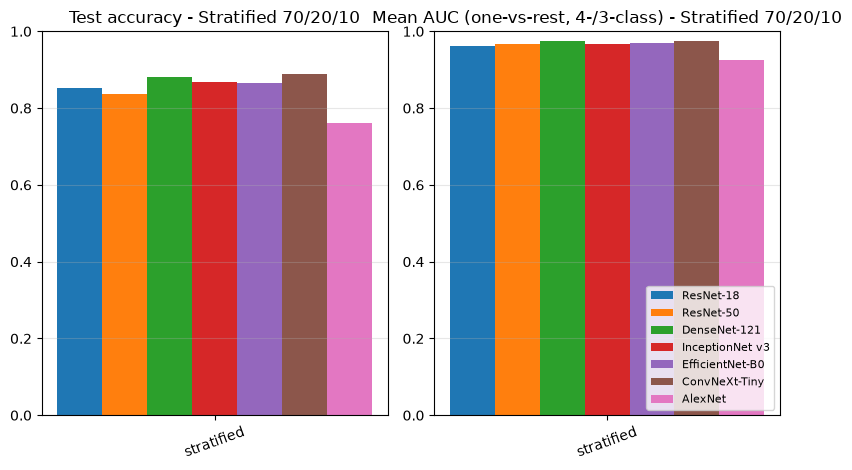

In [5]:
plot_bars("aug", "stratified")

### Per-class precision / recall / F1

In [6]:
show_per_class("aug", "stratified")

**stratified - ResNet-18**

,precision,recall,f1-score,support
Dysfunctional,0.895,0.919,0.907,37.0
Empty,0.826,0.905,0.864,21.0
Functional,0.826,0.896,0.860,106.0
Scum,0.875,0.784,0.827,116.0


**stratified - ResNet-50**

,precision,recall,f1-score,support
Dysfunctional,0.882,0.811,0.845,37.0
Empty,0.667,0.857,0.750,21.0
Functional,0.839,0.887,0.862,106.0
Scum,0.860,0.793,0.825,116.0


**stratified - DenseNet-121**

...

,precision,recall,f1-score,support
Dysfunctional,0.868,0.892,0.880,37.0
Empty,0.826,0.905,0.864,21.0
Functional,0.838,0.925,0.879,106.0
Scum,0.902,0.793,0.844,116.0


**stratified - ConvNeXt-Tiny**

,precision,recall,f1-score,support
Dysfunctional,0.944,0.919,0.932,37.0
Empty,0.864,0.905,0.884,21.0
Functional,0.856,0.953,0.902,106.0
Scum,0.913,0.819,0.864,116.0


**stratified - AlexNet**

,precision,recall,f1-score,support
Dysfunctional,0.857,0.973,0.911,37.0
Empty,0.773,0.810,0.791,21.0
Functional,0.707,0.821,0.760,106.0
Scum,0.785,0.629,0.699,116.0


### OK vs not-OK: ROC and a recall-driven threshold

Collapses the problem to **OK** (`Functional`) vs **not OK** (all other classes), scored by
`P(not OK) = 1 - P(Functional)`. What matters operationally is catching a component that is
no longer working properly, even at the cost of some false alarms, so the operating point is
chosen for a target recall rather than the default argmax rule. One test set, so this is a single ROC and the threshold is the most permissive one that reaches the target recall on it.

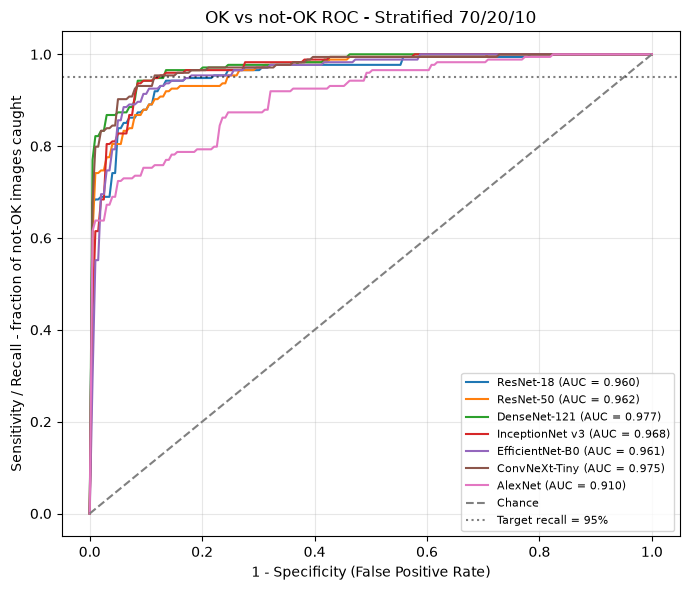

**Operating point per model** - most permissive threshold reaching 95% recall:

,OK/not-OK AUC,threshold on P(not OK),recall (sensitivity),specificity,precision,n_test_sets
model,,,,,,
ResNet-18,0.960,0.261,0.954,0.783,0.878,1
ResNet-50,0.962,0.072,0.954,0.755,0.865,1
DenseNet-121,0.977,0.329,0.954,0.868,0.922,1
InceptionNet v3,0.968,0.325,0.954,0.877,0.927,1
EfficientNet-B0,0.961,0.289,0.954,0.821,0.897,1
ConvNeXt-Tiny,0.975,0.240,0.954,0.877,0.927,1
AlexNet,0.910,0.257,0.954,0.509,0.761,1


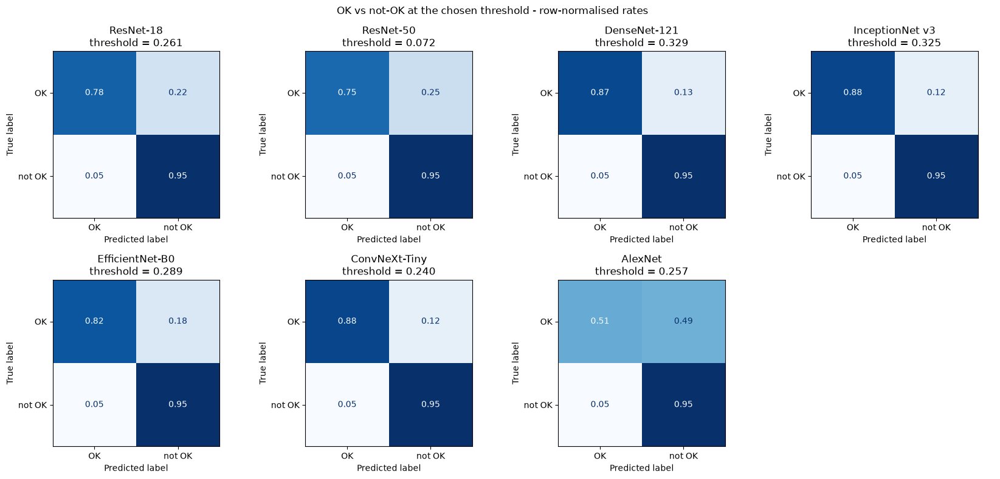

In [7]:
binary_analysis("aug", "stratified")

### Training curves, confusion matrices and ROC curves per run

#### Stratified test set

**ResNet-18** - test accuracy 0.854, mean AUC 0.961

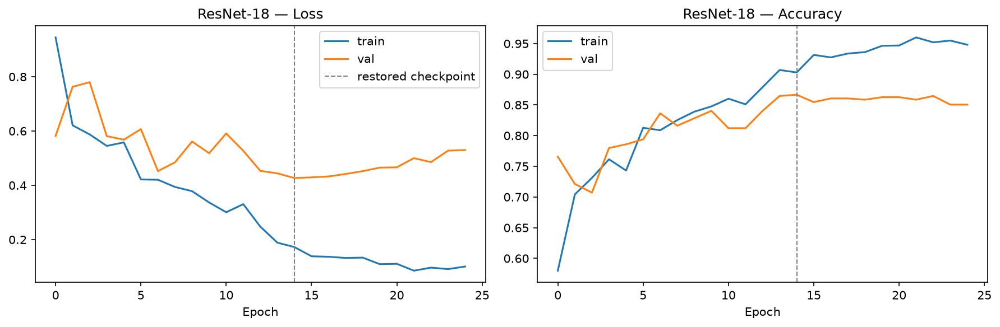

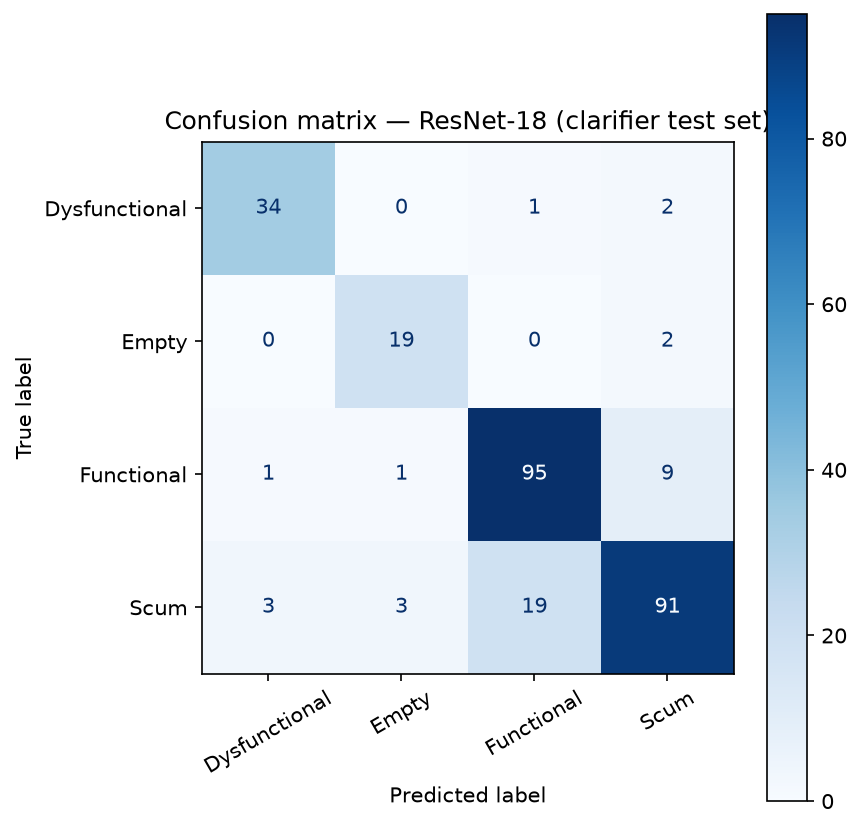

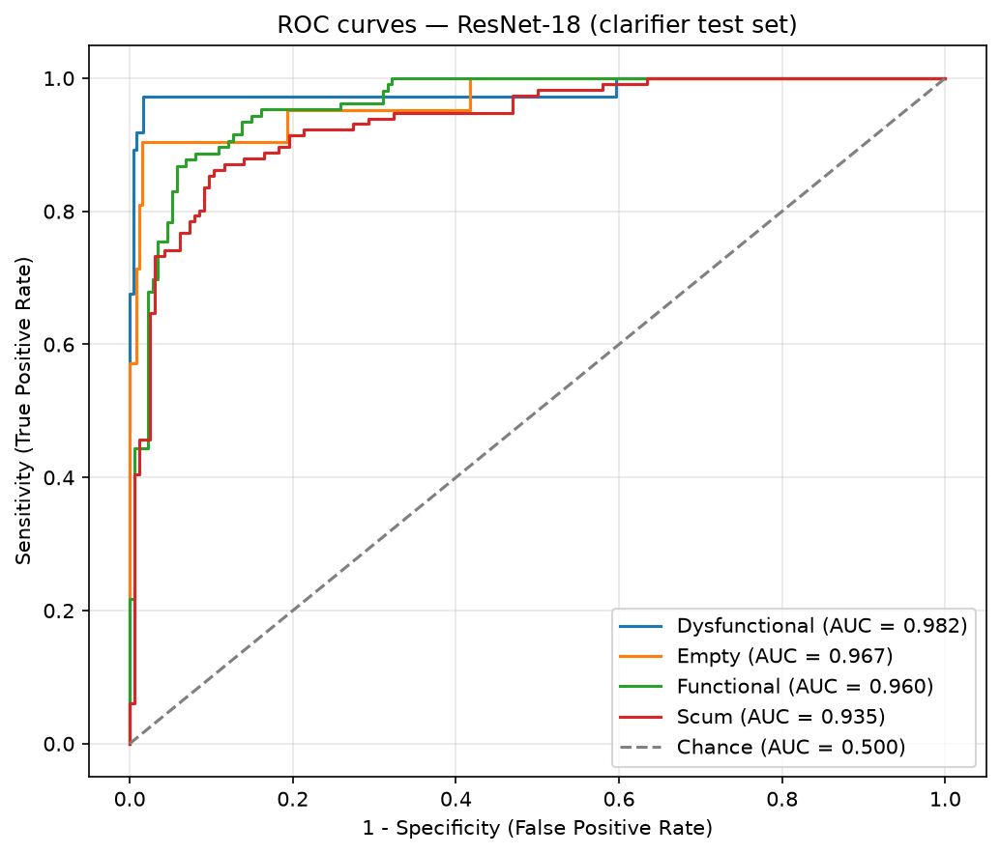

**ResNet-50** - test accuracy 0.836, mean AUC 0.968

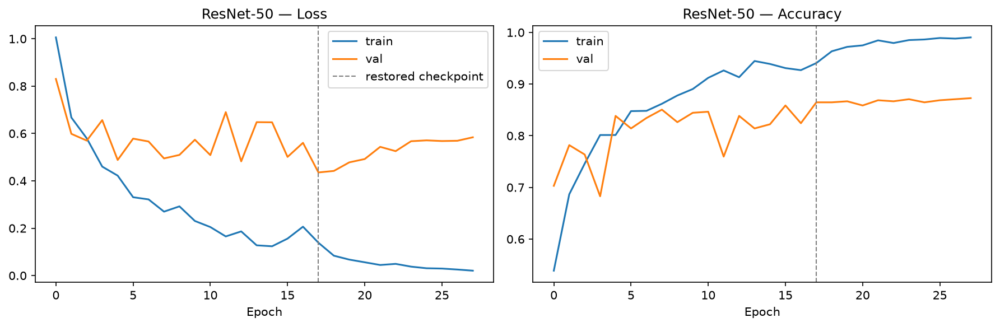

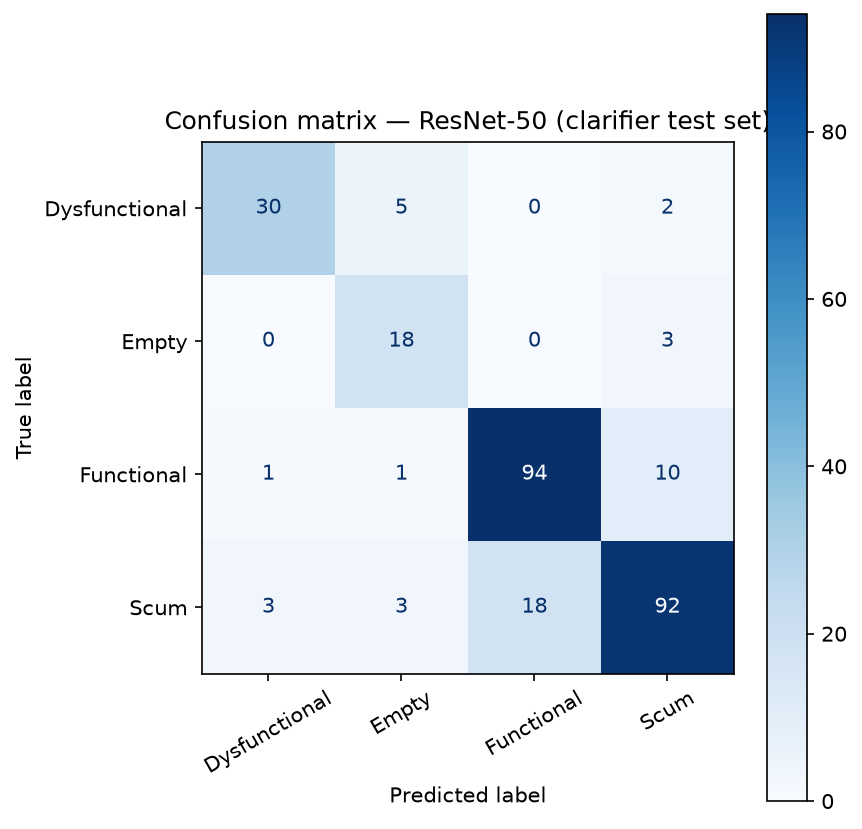

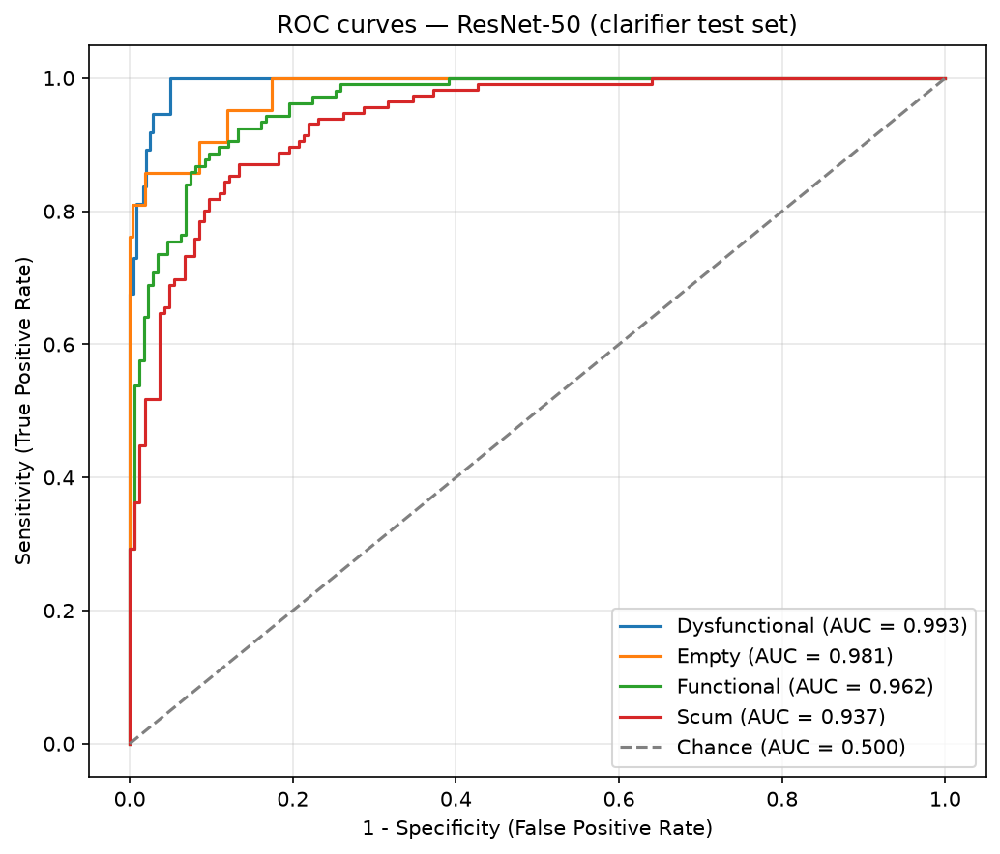

**DenseNet-121** - test accuracy 0.882, mean AUC 0.975

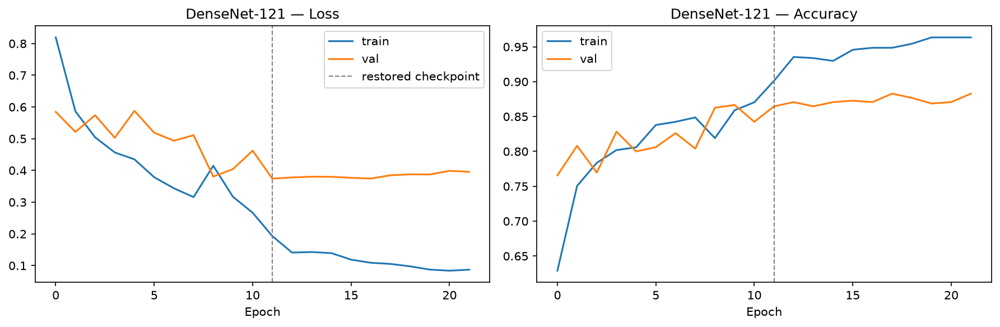

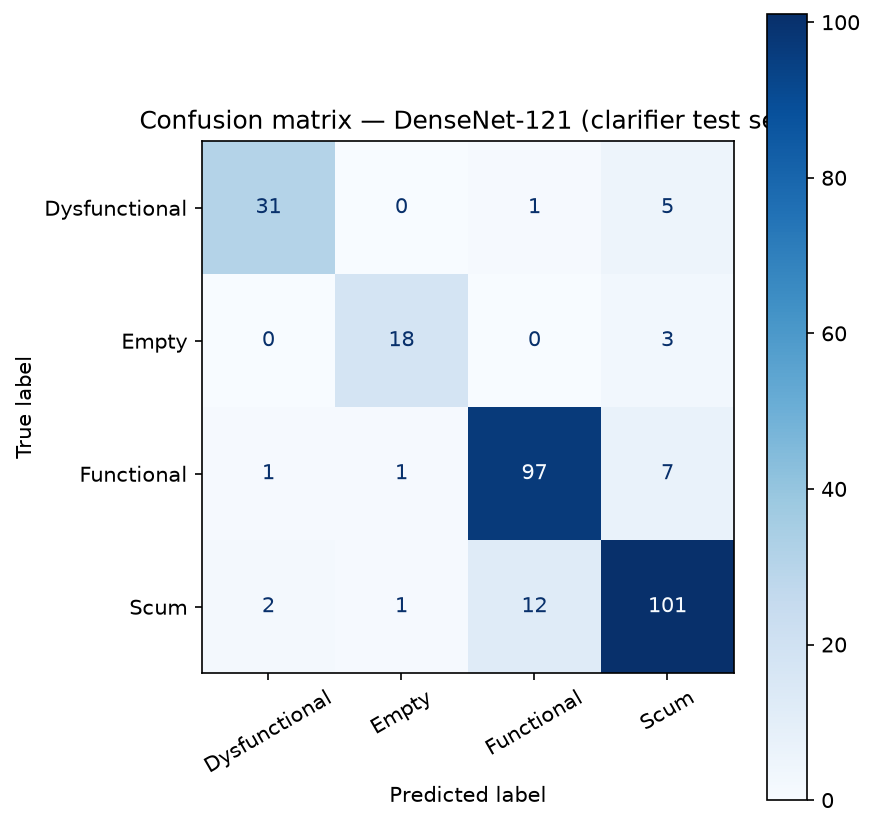

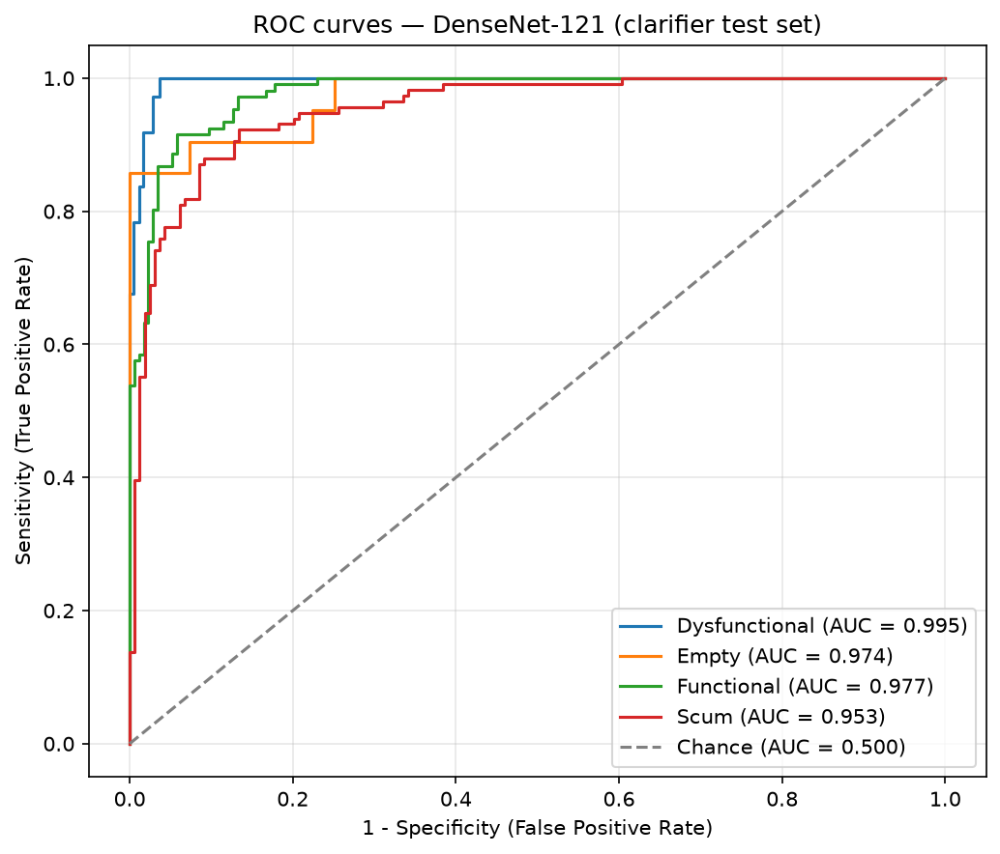

**InceptionNet v3** - test accuracy 0.868, mean AUC 0.968

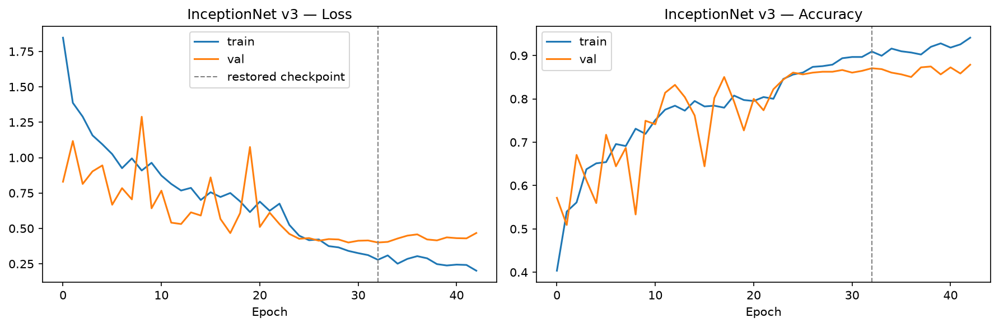

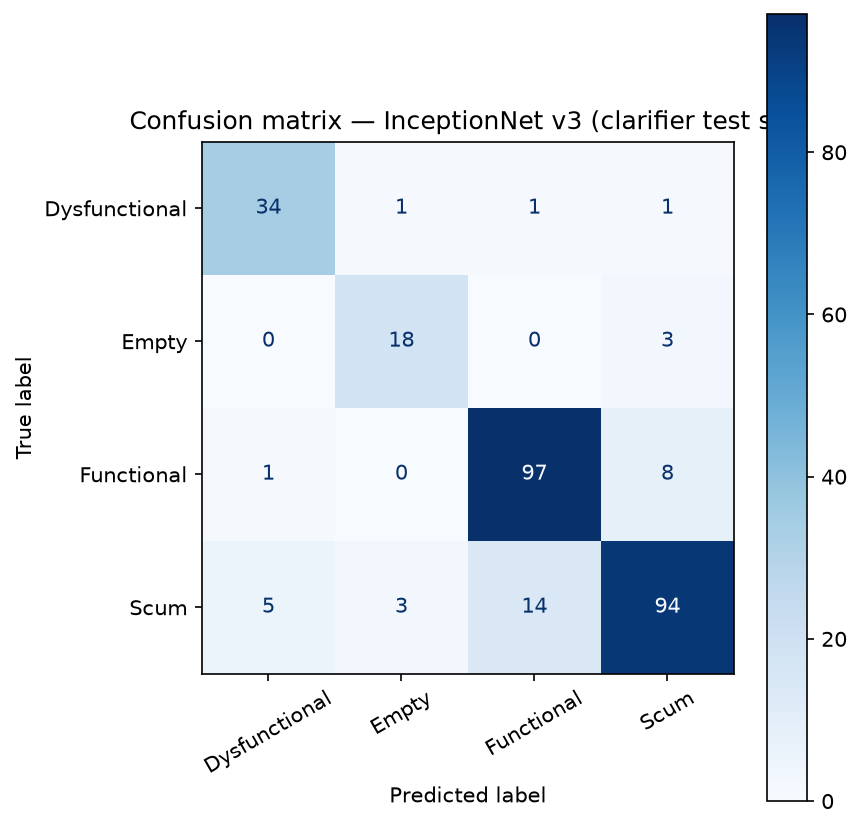

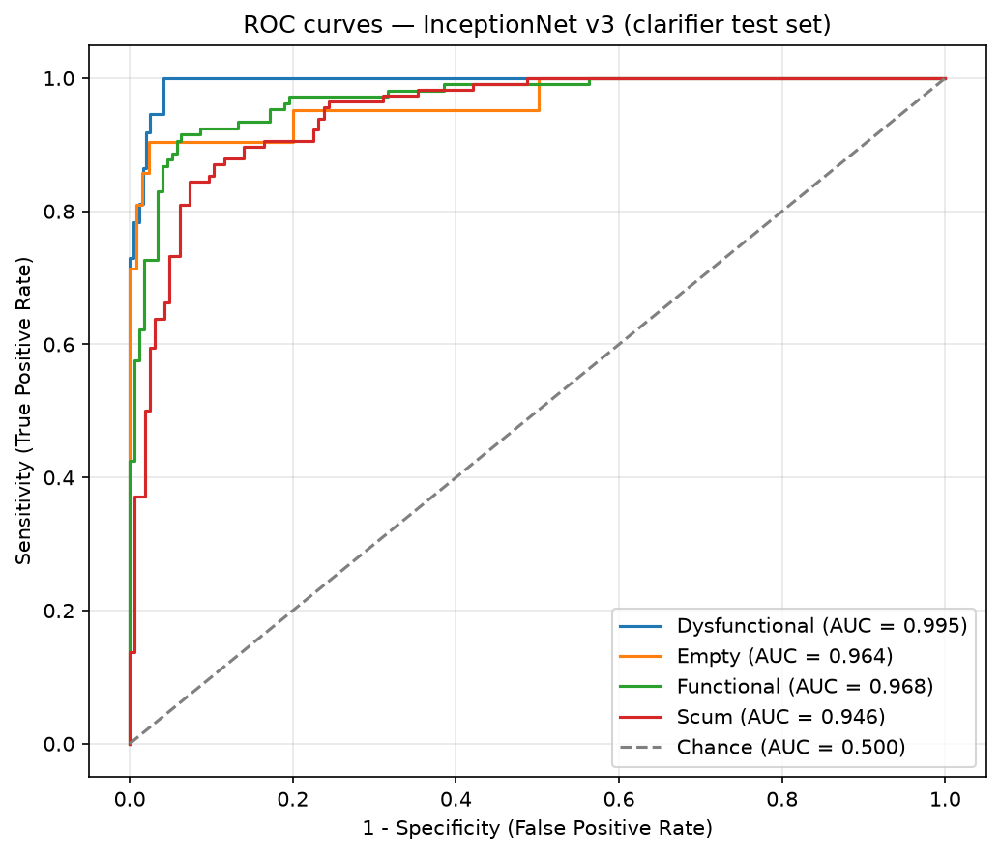

**EfficientNet-B0** - test accuracy 0.864, mean AUC 0.970

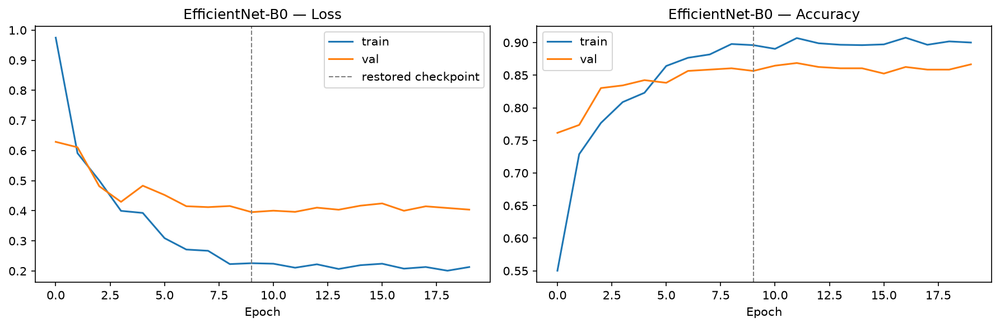

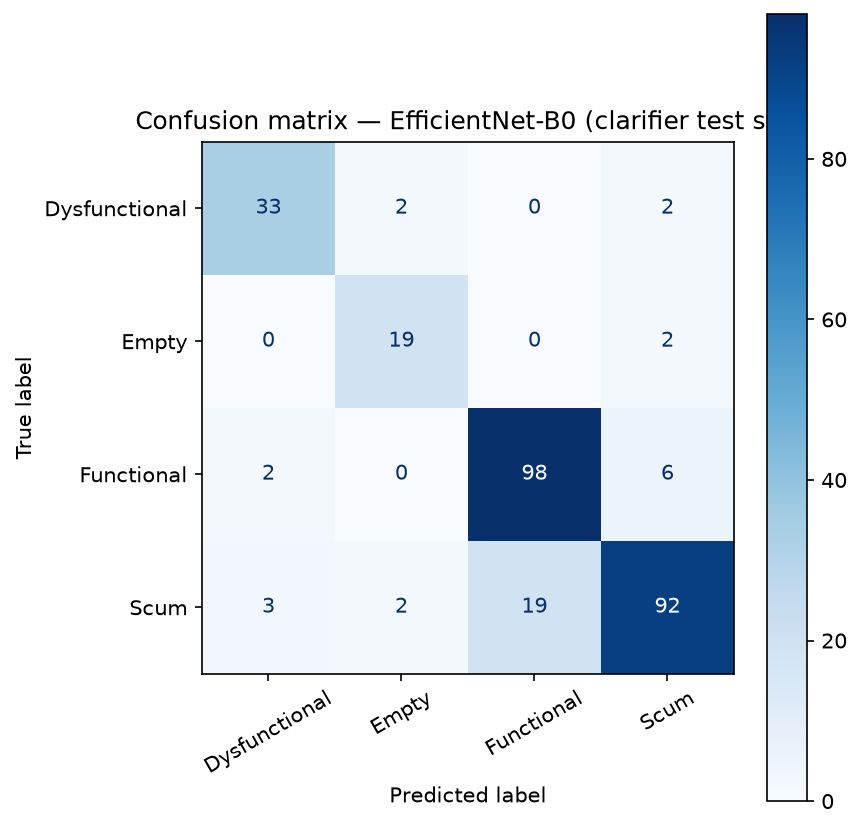

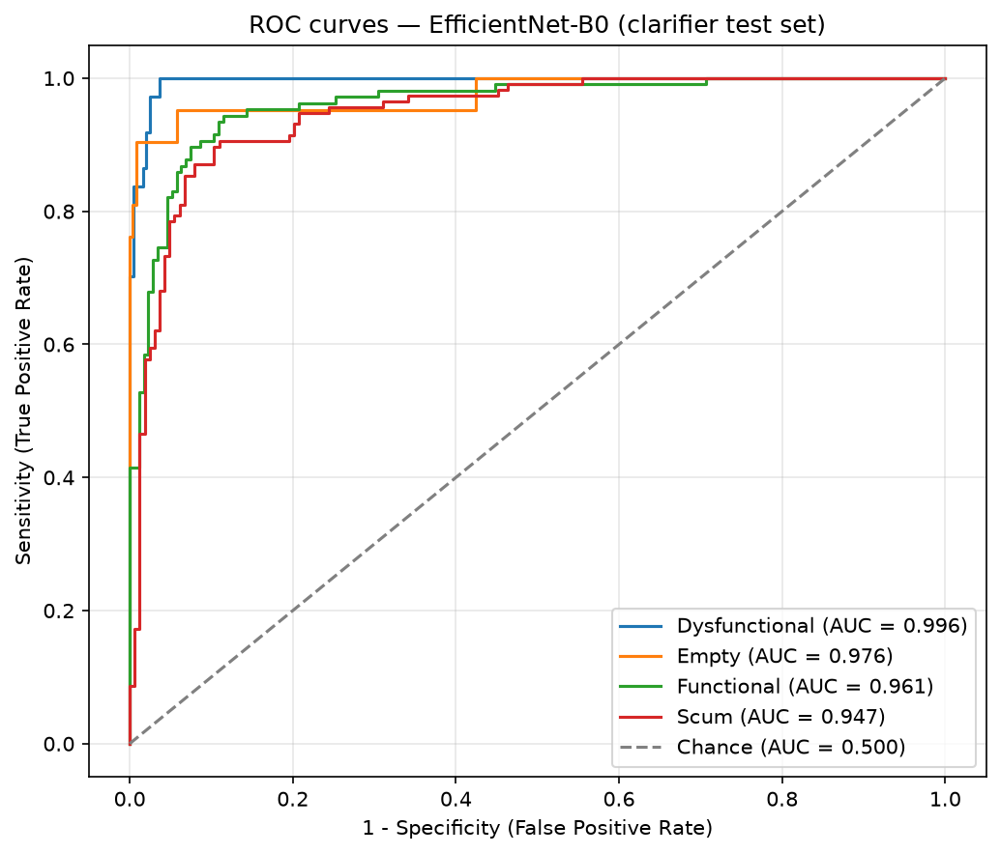

**ConvNeXt-Tiny** - test accuracy 0.889, mean AUC 0.975

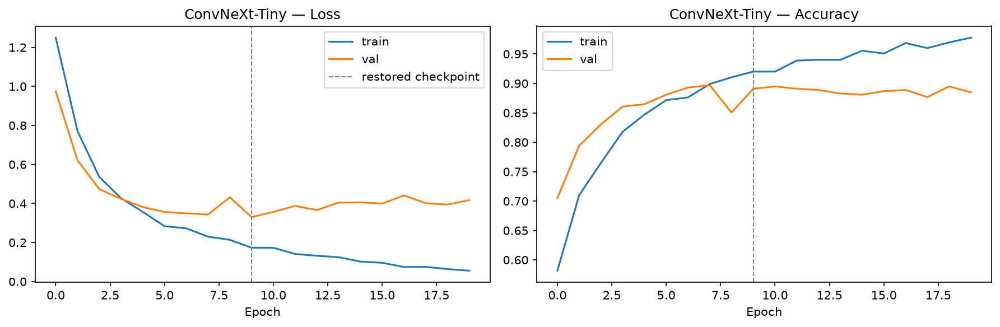

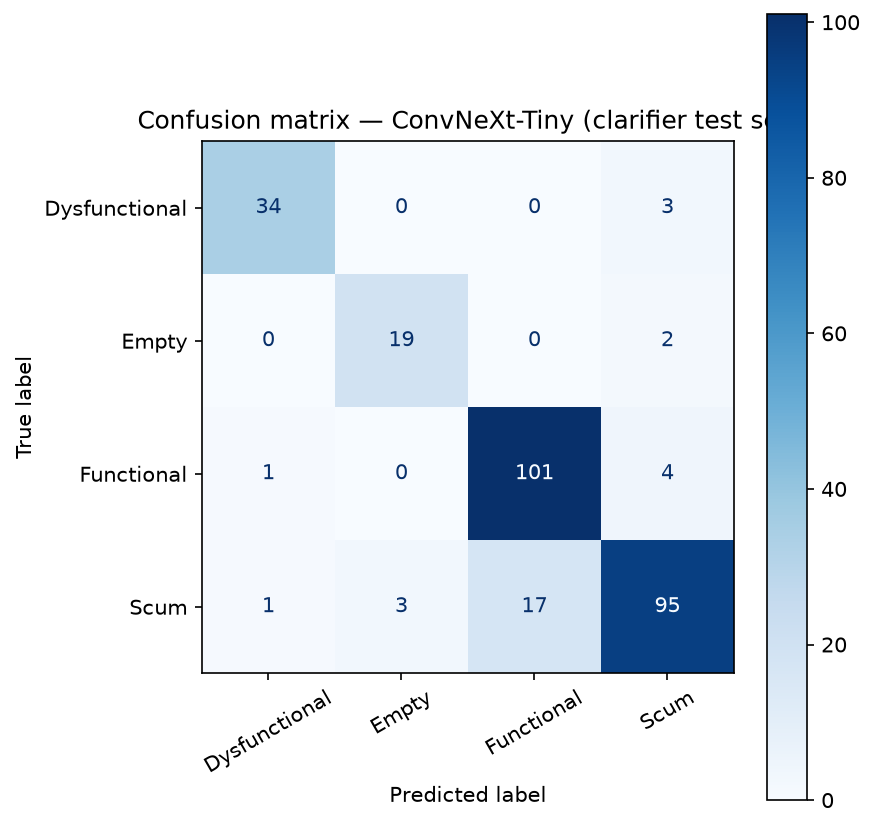

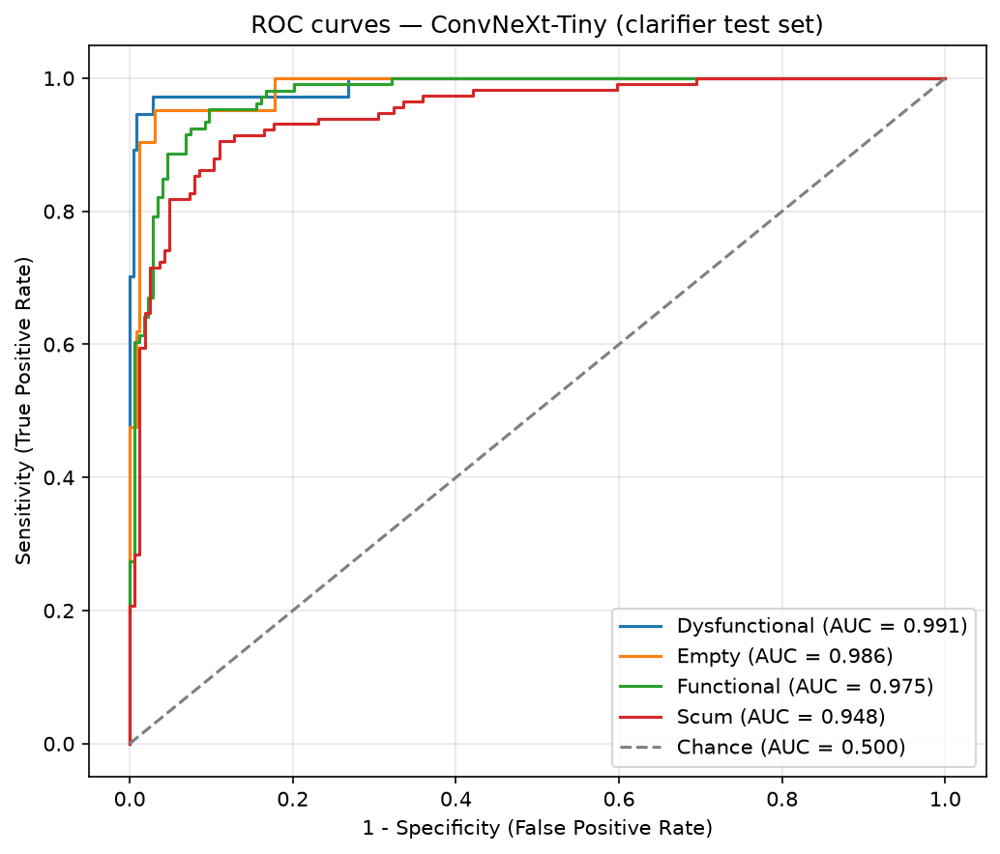

**AlexNet** - test accuracy 0.761, mean AUC 0.924

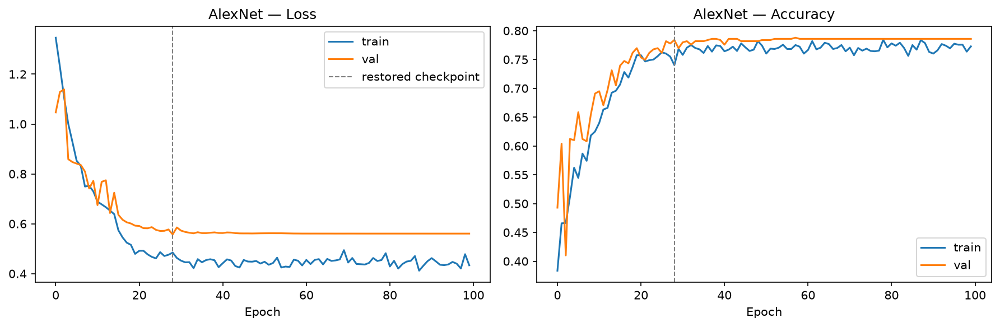

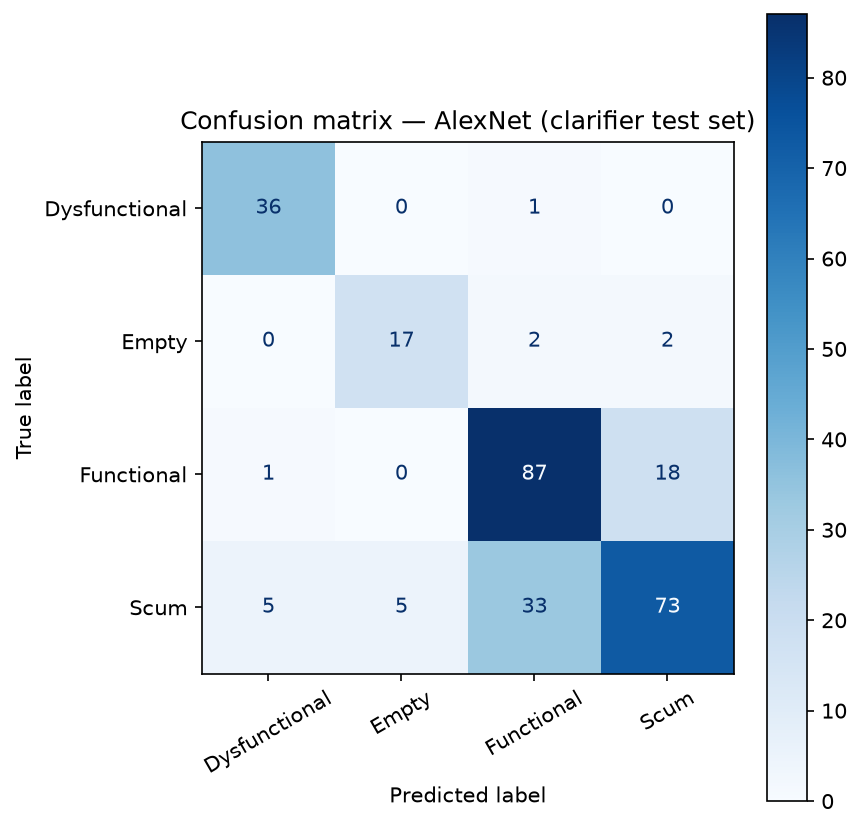

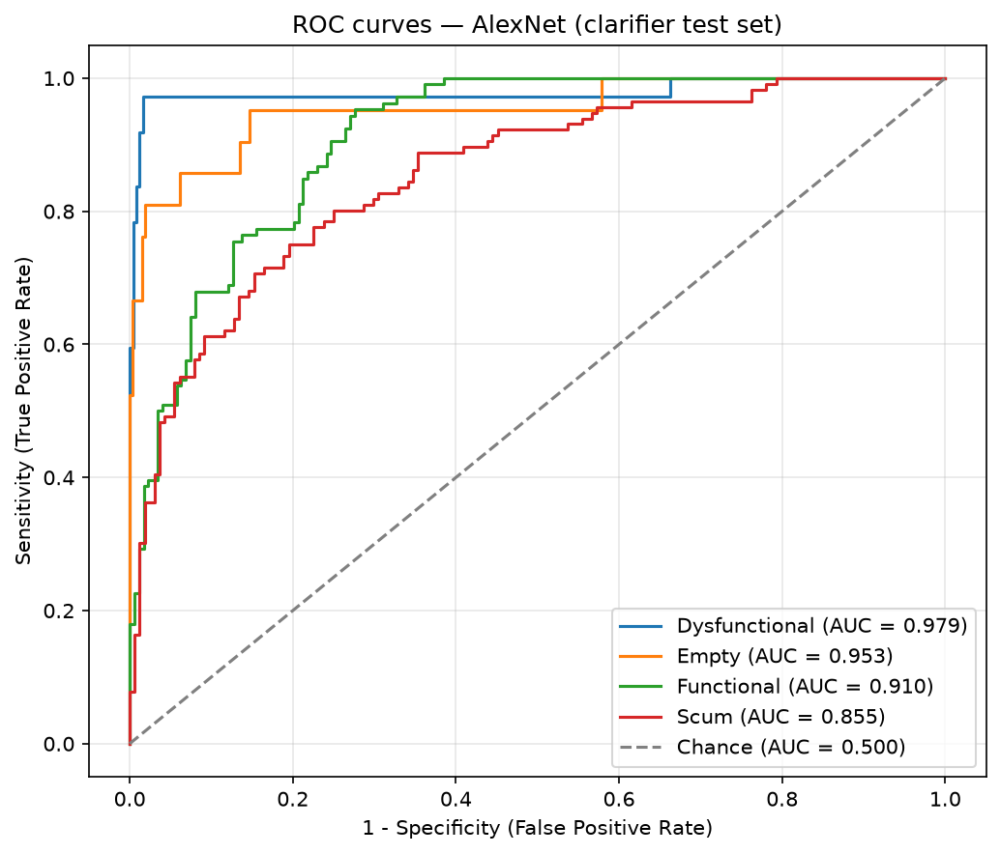

In [8]:
show_figures("aug", "stratified")

## Leave-one-facility-out - Augmented training

### Comparison table

Macro-averaged precision/recall/F1 (every class counts equally). One row per (held-out facility, model), followed by the mean ± std across facilities.

In [9]:
show_comparison("aug", "lofo")

test_accuracy  mean_auc  macro_precision  \
test set        model                                                       
Atlantis        ResNet-18                0.809     0.963            0.666   
                ResNet-50                0.827     0.937            0.664   
                DenseNet-121             0.845     0.945            0.678   
                InceptionNet v3          0.827     0.961            0.670   
                EfficientNet-B0          0.827     0.954            0.672   
                ConvNeXt-Tiny            0.836     0.964            0.675   
                AlexNet                  0.727     0.881            0.561   
CapeFlats       ResNet-18                0.602     0.866            0.665   
                ResNet-50                0.669     0.854            0.640   
                DenseNet-121             0.626     0.869            0.662   
                InceptionNet v3          0.619     0.854            0.668   
                EfficientNet-B0          0.687     0.898            0.685   
                ConvNeXt-Tiny            0.699     0.932            0.726   
                AlexNet                  0.523     0.835            0.580   
Waterval        ResNet-18                0.824     0.938            0.665   
                ResNet-50                0.870     0.945            0.680   
                DenseNet-121             0.898     0.970            0.602   
                InceptionNet v3          0.884     0.969            0.689   
                EfficientNet-B0          0.898     0.978            0.693   
                ConvNeXt-Tiny            0.877     0.973            0.679   
                AlexNet                  0.754     0.819            0.498   
Fisantekraal    ResNet-18                0.746     0.907            0.741   
                ResNet-50                0.758     0.892            0.728   
                DenseNet-121             0.794     0.946            0.841   
                InceptionNet v3          0.750     0.930            0.709   
                EfficientNet-B0          0.746     0.926            0.760   
                ConvNeXt-Tiny            0.798     0.941            0.796   
                AlexNet                  0.651     0.857            0.695   
NoordelikeWerke ResNet-18                0.840     0.895            0.808   
                ResNet-50                0.874     0.940            0.915   
                DenseNet-121             0.847     0.970            0.905   
                InceptionNet v3          0.854     0.884            0.786   
                EfficientNet-B0          0.864     0.946            0.902   
                ConvNeXt-Tiny            0.901     0.971            0.933   
                AlexNet                  0.780     0.923            0.731   

                                 macro_recall  macro_f1  n_test_images  
test set        model                                                   
Atlantis        ResNet-18               0.587     0.605            110  
                ResNet-50               0.590     0.614            110  
                DenseNet-121            0.603     0.623            110  
                InceptionNet v3         0.516     0.542            110  
                EfficientNet-B0         0.516     0.542            110  
                ConvNeXt-Tiny           0.520     0.546            110  
                AlexNet                 0.550     0.534            110  
CapeFlats       ResNet-18               0.634     0.611           1476  
                ResNet-50               0.648     0.624           1476  
                DenseNet-121            0.628     0.610           1476  
                InceptionNet v3         0.618     0.591           1476  
                EfficientNet-B0         0.687     0.670           1476  
                ConvNeXt-Tiny           0.705     0.694           1476  
                AlexNet                 0.596     0.551           1476  
Waterval       

**Mean ± std across held-out facilities** (each facility counts once):

test_accuracy        mean_auc        macro_precision         \
                         mean    std     mean    std            mean    std   
model                                                                         
ResNet-18               0.764  0.097    0.914  0.038           0.709  0.064   
ResNet-50               0.800  0.086    0.914  0.039           0.726  0.111   
DenseNet-121            0.802  0.105    0.940  0.041           0.738  0.129   
InceptionNet v3         0.787  0.106    0.920  0.050           0.704  0.048   
EfficientNet-B0         0.804  0.087    0.941  0.030           0.742  0.096   
ConvNeXt-Tiny           0.822  0.080    0.956  0.018           0.762  0.108   
AlexNet                 0.687  0.104    0.863  0.041           0.613  0.097   

                macro_recall        macro_f1        n_facilities  
                        mean    std     mean    std               
model                                                             
ResNet-18              0.649  0.047    0.656  0.059            5  
ResNet-50              0.658  0.080    0.677  0.090            5  
DenseNet-121           0.660  0.061    0.669  0.076            5  
InceptionNet v3        0.634  0.080    0.639  0.074            5  
EfficientNet-B0        0.671  0.103    0.686  0.103            5  
ConvNeXt-Tiny          0.677  0.096    0.694  0.100            5  
AlexNet                0.619  0.075    0.595  0.083            5

### Accuracy and AUC

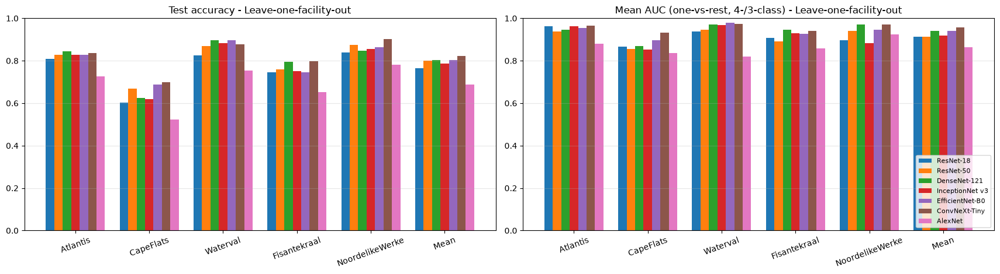

In [10]:
plot_bars("aug", "lofo")

### Per-class precision / recall / F1

In [11]:
show_per_class("aug", "lofo")

**Atlantis - ResNet-18**

,precision,recall,f1-score,support
Dysfunctional,0.000,0.000,0.000,0.0
Empty,1.000,0.667,0.800,3.0
Functional,0.688,1.000,0.815,44.0
Scum,0.977,0.683,0.804,63.0


**Atlantis - ResNet-50**

,precision,recall,f1-score,support
Dysfunctional,0.000,0.000,0.000,0.0
Empty,1.000,0.667,0.800,3.0
Functional,0.732,0.932,0.820,44.0
Scum,0.923,0.762,0.835,63.0


**Atlantis - DenseNet-121**

...

,precision,recall,f1-score,support
Dysfunctional,0.926,0.954,0.940,131.0
Empty,1.000,0.538,0.700,13.0
Functional,0.864,0.630,0.729,81.0
Scum,0.819,0.928,0.870,180.0


**NoordelikeWerke - ConvNeXt-Tiny**

,precision,recall,f1-score,support
Dysfunctional,0.919,0.954,0.936,131.0
Empty,1.000,0.385,0.556,13.0
Functional,0.941,0.790,0.859,81.0
Scum,0.872,0.950,0.910,180.0


**NoordelikeWerke - AlexNet**

,precision,recall,f1-score,support
Dysfunctional,0.952,0.908,0.930,131.0
Empty,0.538,0.538,0.538,13.0
Functional,0.725,0.358,0.479,81.0
Scum,0.709,0.894,0.791,180.0


### OK vs not-OK: ROC and a recall-driven threshold

Collapses the problem to **OK** (`Functional`) vs **not OK** (all other classes), scored by
`P(not OK) = 1 - P(Functional)`. What matters operationally is catching a component that is
no longer working properly, even at the cost of some false alarms, so the operating point is
chosen for a target recall rather than the default argmax rule. One ROC per held-out facility, then averaged (interpolated onto a common FPR grid) rather than pooled, so each facility counts once; the threshold is the most permissive one whose *mean* recall across facilities reaches the target.

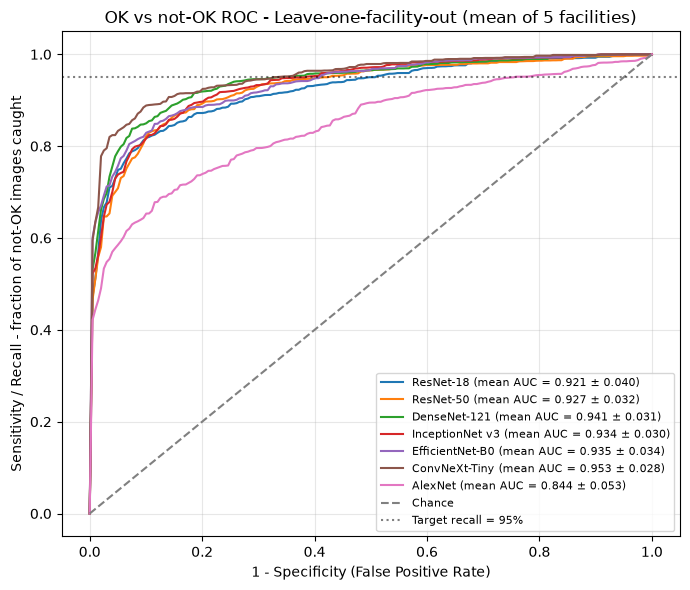

**Operating point per model** - most permissive threshold reaching 95% mean recall across facilities:

,OK/not-OK AUC,OK/not-OK AUC std,threshold on P(not OK),recall (sensitivity),specificity,precision,n_test_sets
model,,,,,,,
ResNet-18,0.921,0.040,0.084,0.951,0.441,0.768,5
ResNet-50,0.927,0.032,0.168,0.953,0.524,0.788,5
DenseNet-121,0.941,0.031,0.062,0.950,0.432,0.780,5
InceptionNet v3,0.934,0.030,0.102,0.952,0.511,0.794,5
EfficientNet-B0,0.935,0.034,0.154,0.951,0.480,0.784,5
ConvNeXt-Tiny,0.953,0.028,0.110,0.950,0.528,0.797,5
AlexNet,0.844,0.053,0.144,0.953,0.190,0.685,5


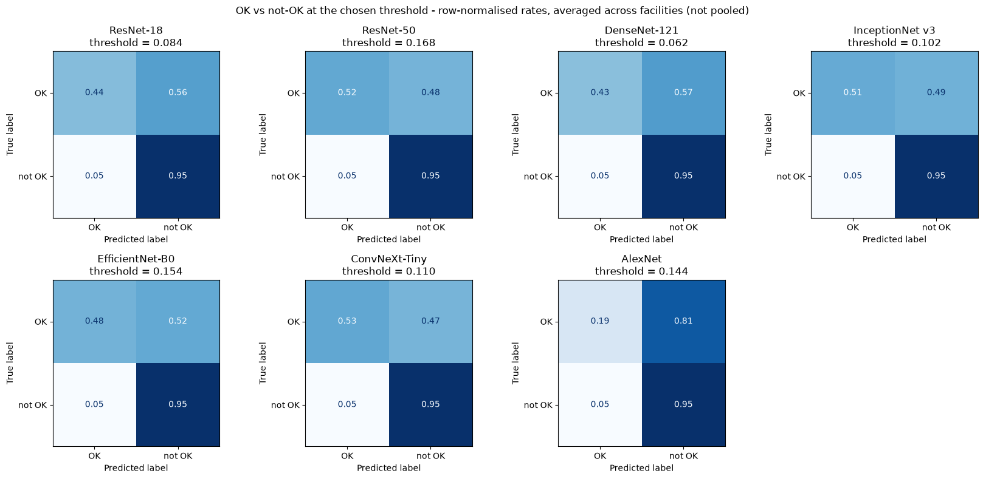

**Does the one threshold hold up on each held-out facility?**

recall  specificity  precision  n_not_ok  \
model           test set                                                    
ResNet-18       Atlantis          0.909        0.841      0.896        66   
                CapeFlats         0.995        0.080      0.559       797   
                Waterval          0.949        0.708      0.877       195   
                Fisantekraal      0.901        0.491      0.696       142   
                NoordelikeWerke   1.000        0.086      0.814       324   
ResNet-50       Atlantis          0.909        0.705      0.822        66   
                CapeFlats         0.974        0.436      0.670       797   
                Waterval          0.979        0.663      0.864       195   
                Fisantekraal      0.908        0.609      0.750       142   
                NoordelikeWerke   0.994        0.210      0.834       324   
DenseNet-121    Atlantis          0.894        0.818      0.881        66   
                CapeFlats         0.997        0.108      0.567       797   
                Waterval          1.000        0.292      0.756       195   
                Fisantekraal      0.859        0.855      0.884       142   
                NoordelikeWerke   1.000        0.086      0.814       324   
InceptionNet v3 Atlantis          0.894        0.864      0.908        66   
                CapeFlats         0.992        0.168      0.583       797   
                Waterval          0.990        0.393      0.781       195   
                Fisantekraal      0.901        0.773      0.837       142   
                NoordelikeWerke   0.985        0.358      0.860       324   
EfficientNet-B0 Atlantis          0.833        0.955      0.965        66   
                CapeFlats         0.996        0.150      0.579       797   
                Waterval          0.979        0.584      0.838       195   
                Fisantekraal      0.944        0.464      0.694       142   
                NoordelikeWerke   1.000        0.247      0.842       324   
ConvNeXt-Tiny   Atlantis          0.848        1.000      1.000        66   
                CapeFlats         1.000        0.128      0.574       797   
                Waterval          0.938        0.674      0.863       195   
                Fisantekraal      0.965        0.391      0.672       142   
                NoordelikeWerke   1.000        0.444      0.878       324   
AlexNet         Atlantis          0.894        0.523      0.738        66   
                CapeFlats         1.000        0.006      0.541       797   
                Waterval          0.990        0.011      0.687       195   
                Fisantekraal      0.880        0.409      0.658       142   
                NoordelikeWerke   1.000        0.000      0.800       324   

                                 n_images  
model           test set                   
ResNet-18       Atlantis              110  
                CapeFlats            1476  
                Waterval              284  
                Fisantekraal          252  
                NoordelikeWerke       405  
ResNet-50       Atlantis              110  
                CapeFlats            1476  
                Waterval              284  
                Fisantekraal          252  
                NoordelikeWerke       405  
DenseNet-121    Atlantis              110  
                CapeFlats            1476  
                Waterval              284  
                Fisantekraal          252  
                NoordelikeWerke       405  
InceptionNet v3 Atlantis              110  
                CapeFlats            1476  
                Waterval              284  
                Fisantekraal          252  
                NoordelikeWerke       405  
EfficientNet-B0 Atlantis              110  
                CapeFlats            1476  
                Waterval              284  
                Fisantekraal          252  
                NoordelikeWerke       4

Recall spread across held-out facilities at each model's threshold:

,mean,std,min,max
model,,,,
ResNet-18,0.951,0.046,0.901,1.000
ResNet-50,0.953,0.041,0.908,0.994
DenseNet-121,0.950,0.068,0.859,1.000
InceptionNet v3,0.952,0.050,0.894,0.992
EfficientNet-B0,0.951,0.069,0.833,1.000
ConvNeXt-Tiny,0.950,0.063,0.848,1.000
AlexNet,0.953,0.060,0.880,1.000


In [12]:
binary_analysis("aug", "lofo")

### Training curves, confusion matrices and ROC curves per run

#### Atlantis (held out)

**ResNet-18** - test accuracy 0.809, mean AUC 0.963

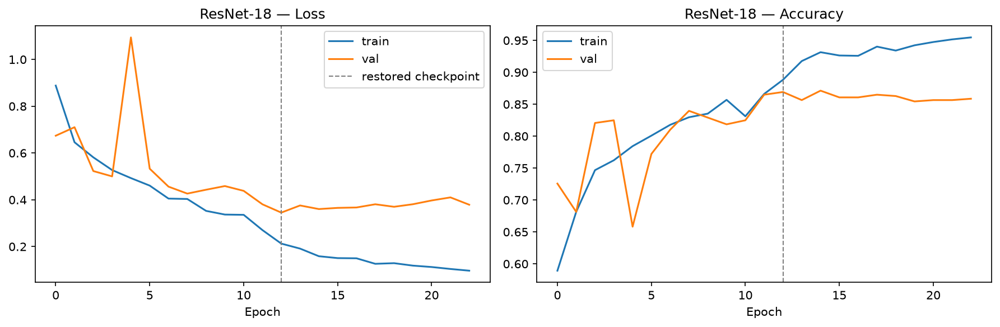

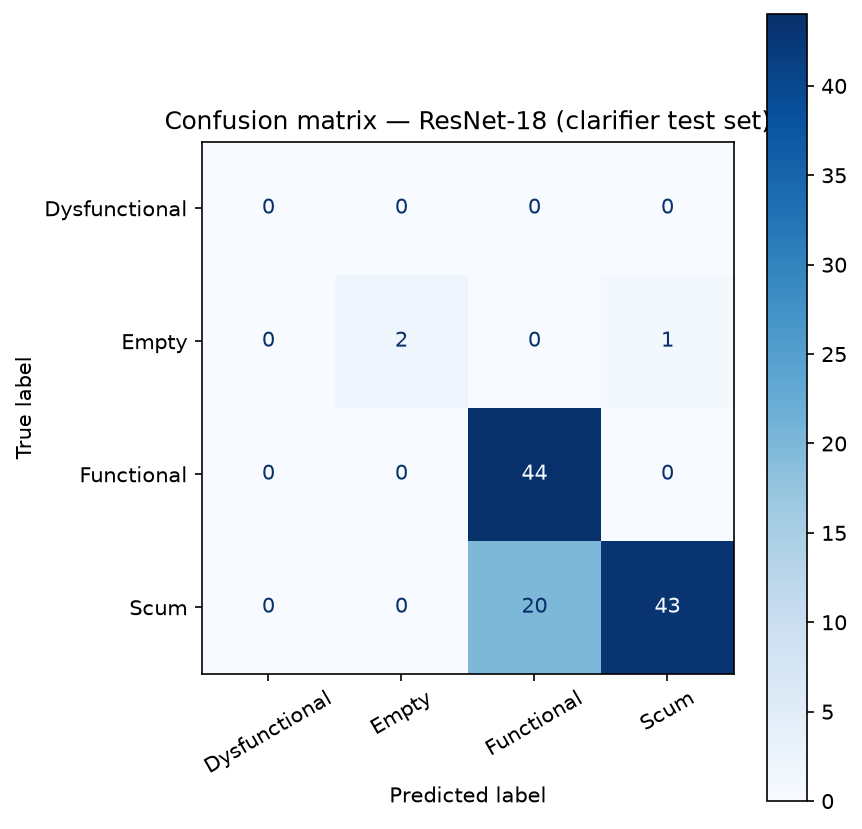

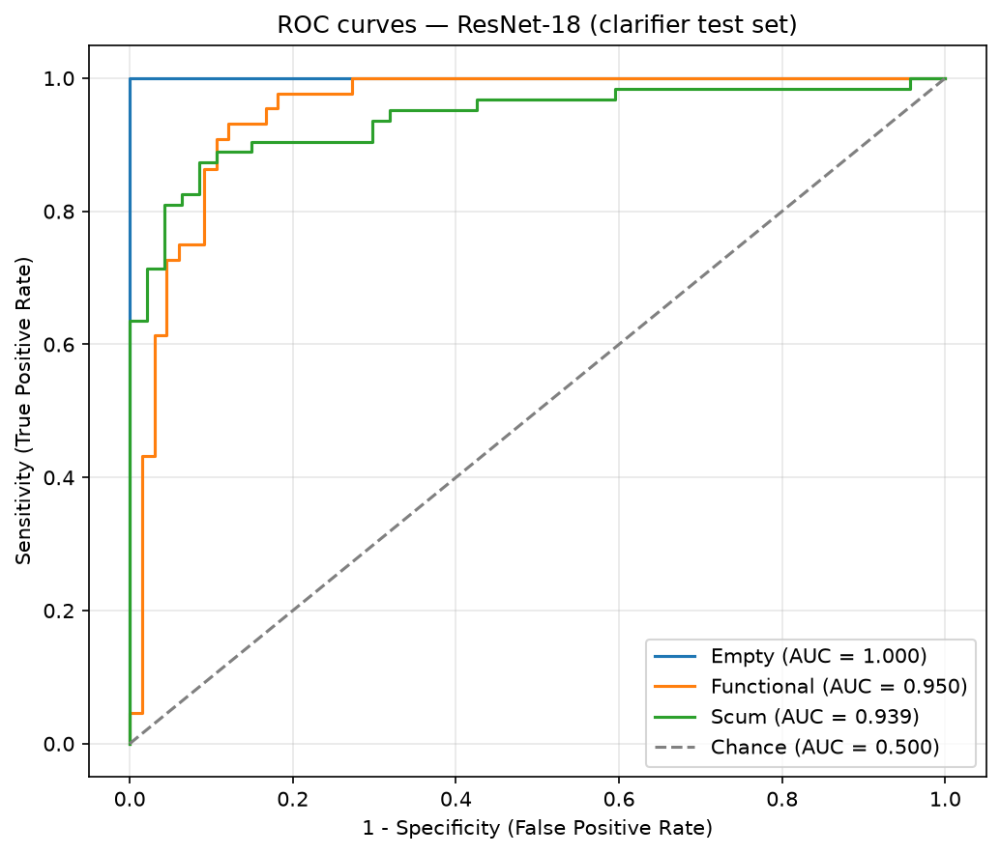

**ResNet-50** - test accuracy 0.827, mean AUC 0.937

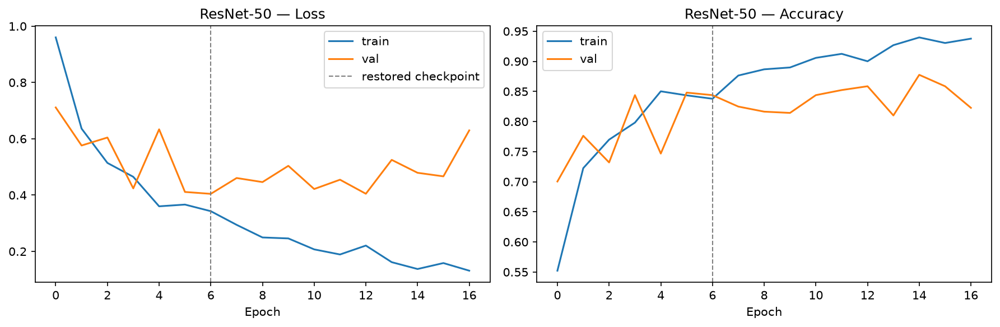

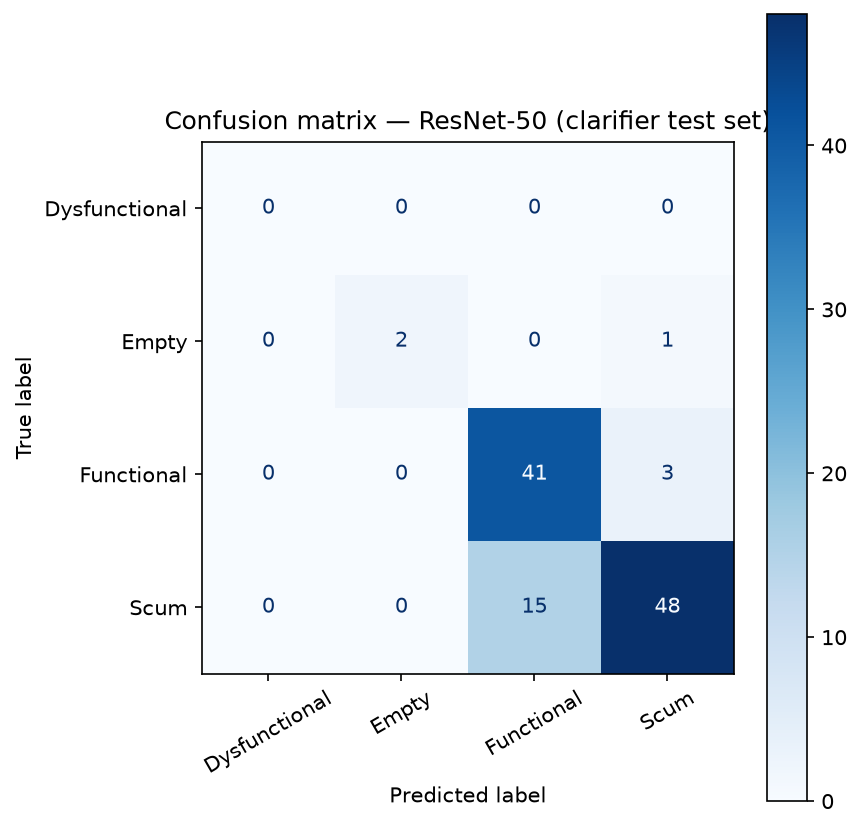

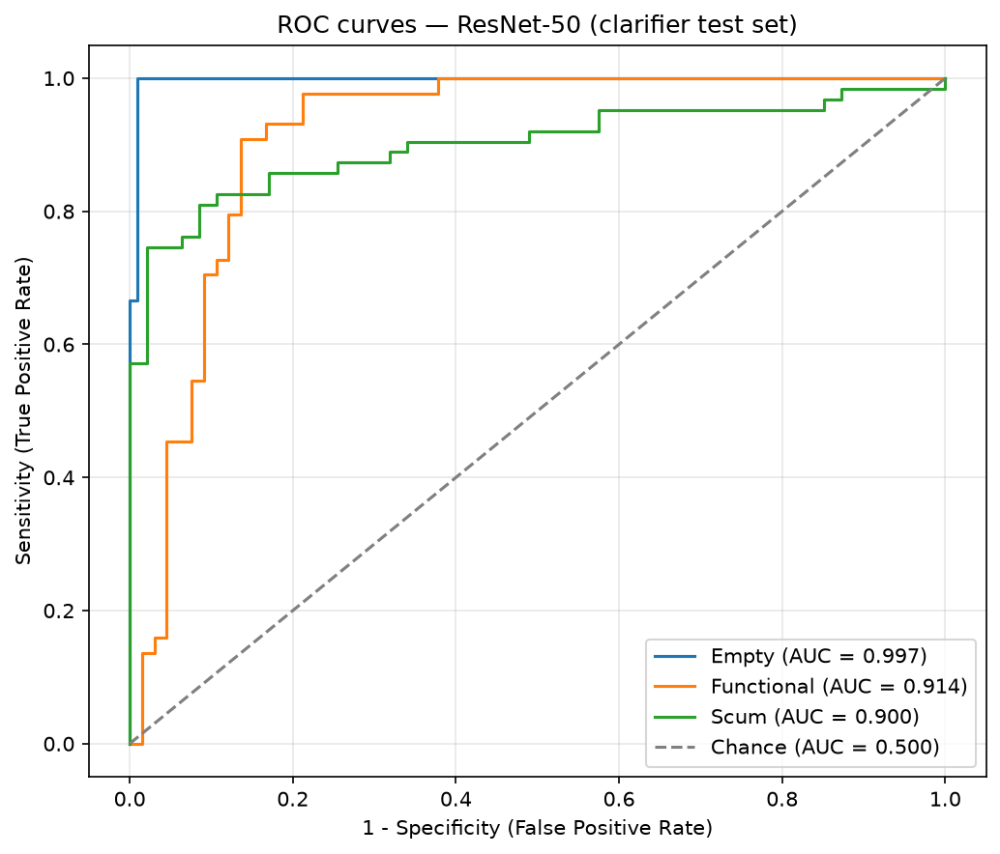

**DenseNet-121** - test accuracy 0.845, mean AUC 0.945

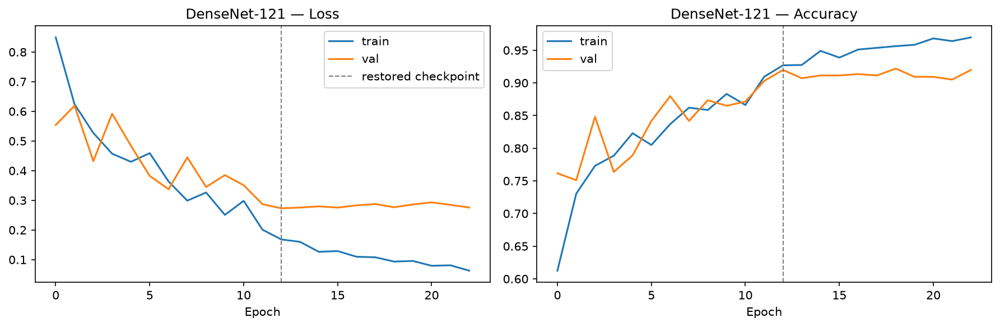

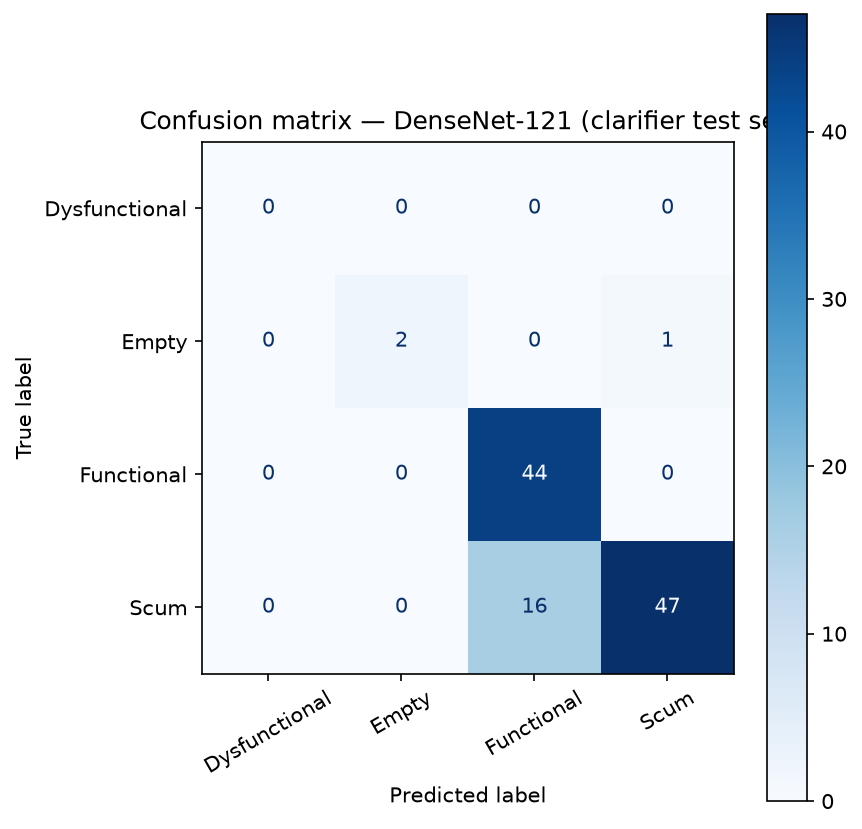

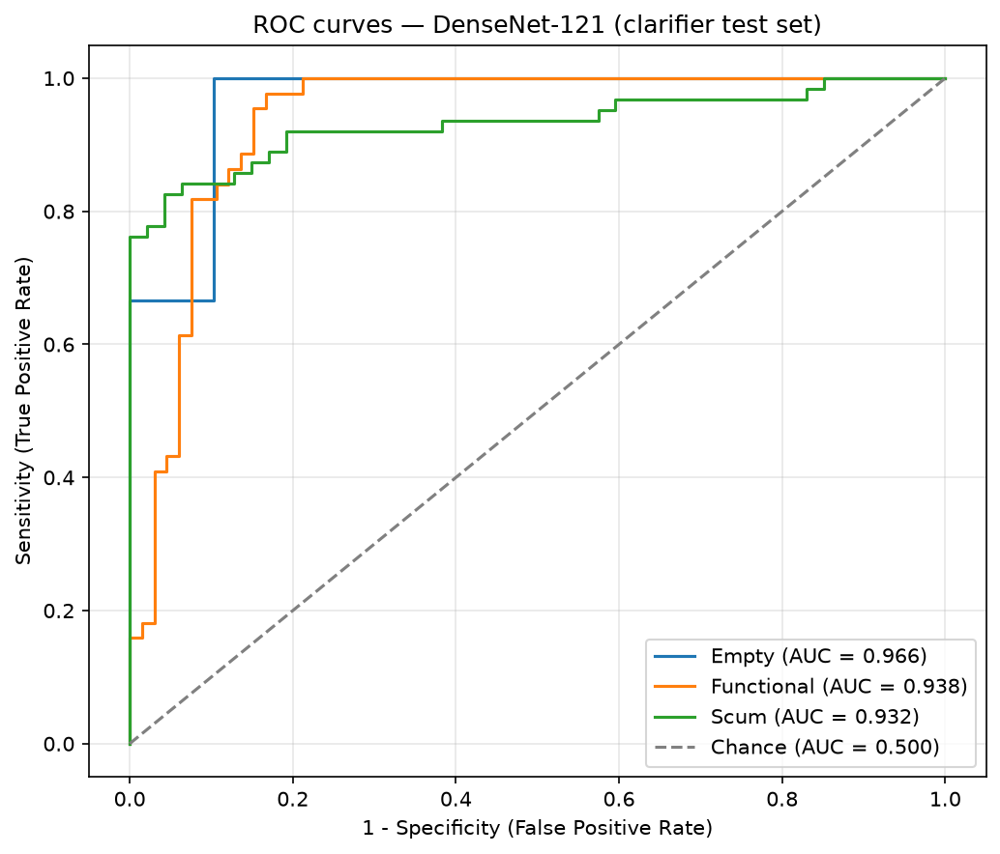

**InceptionNet v3** - test accuracy 0.827, mean AUC 0.961

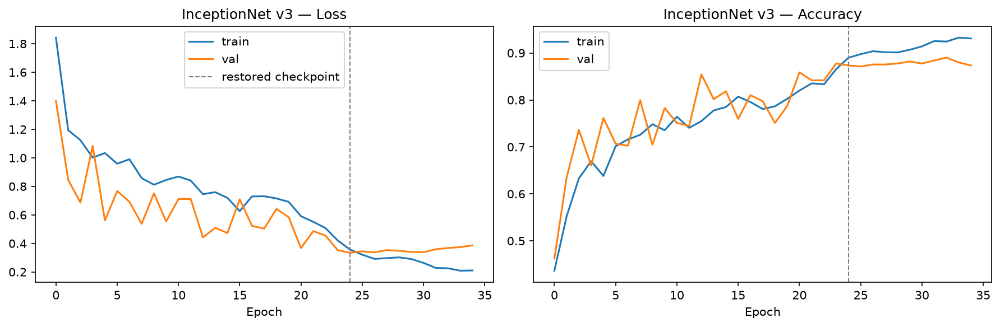

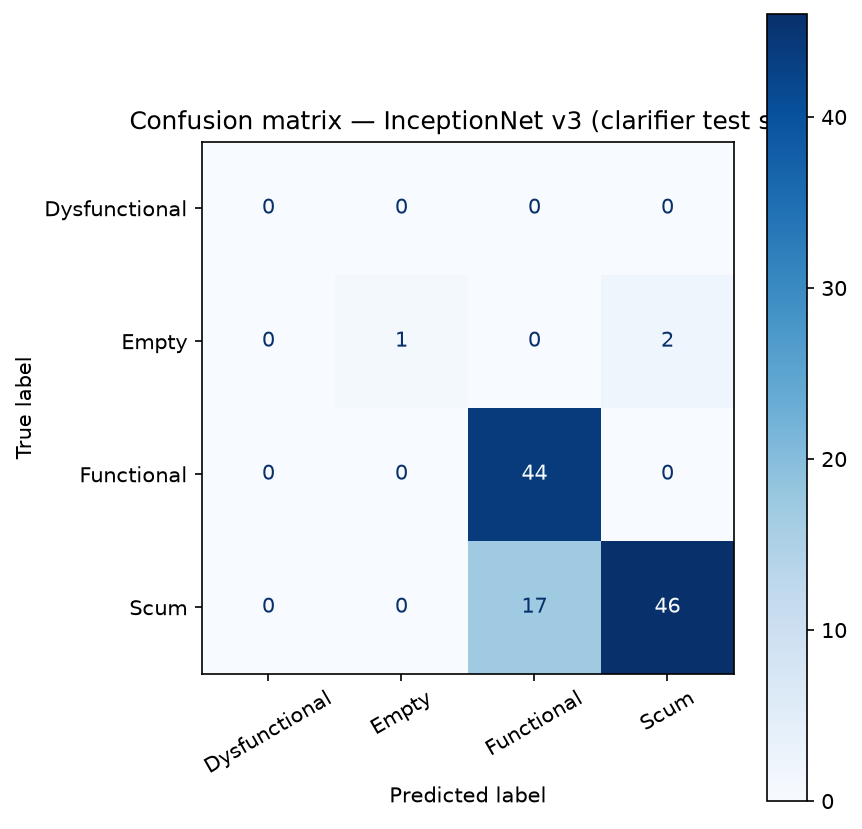

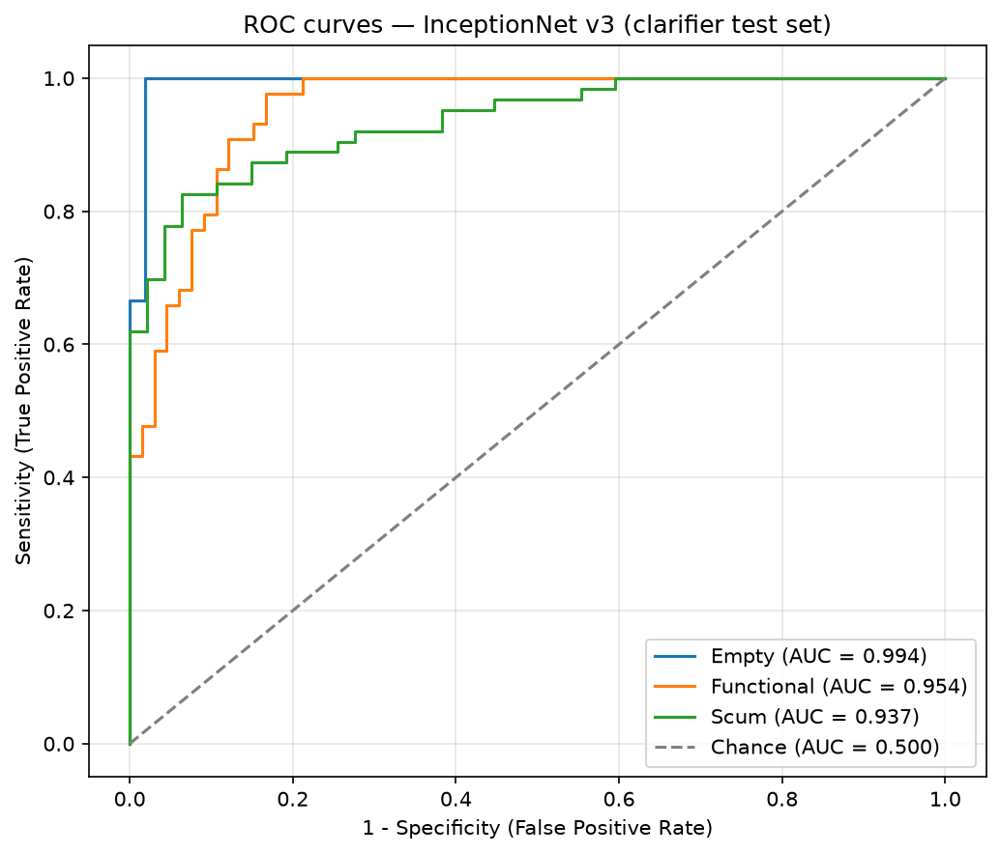

**EfficientNet-B0** - test accuracy 0.827, mean AUC 0.954

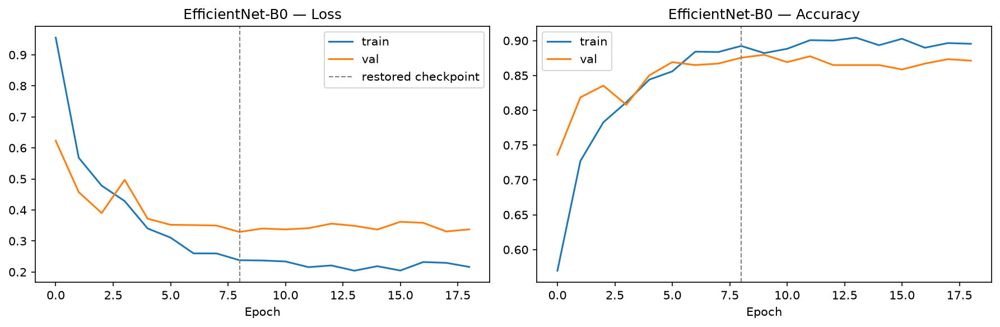

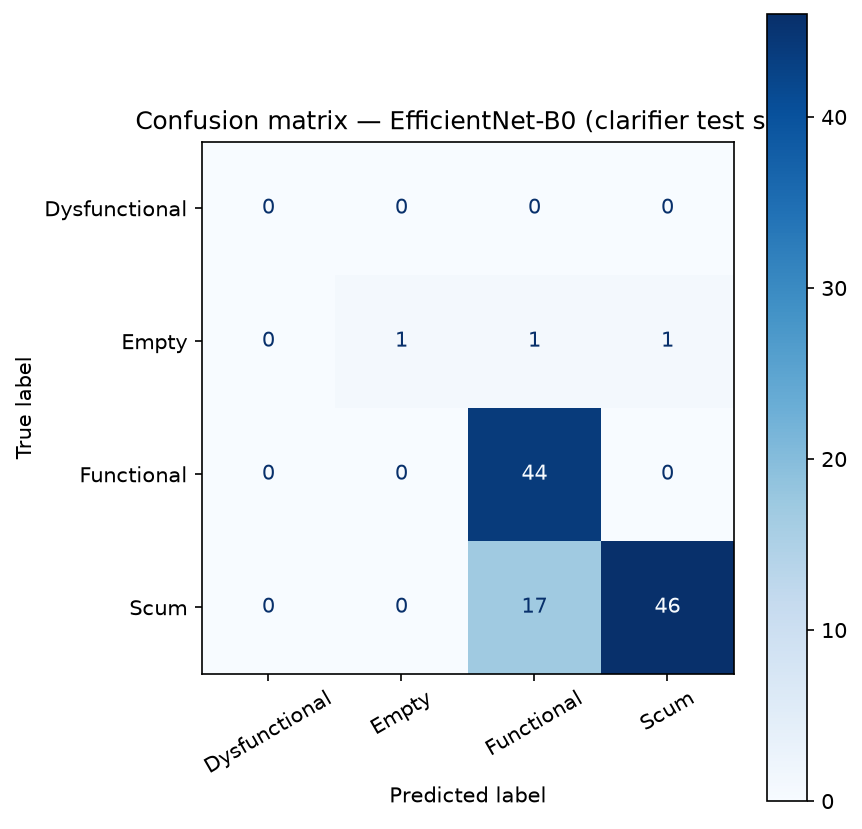

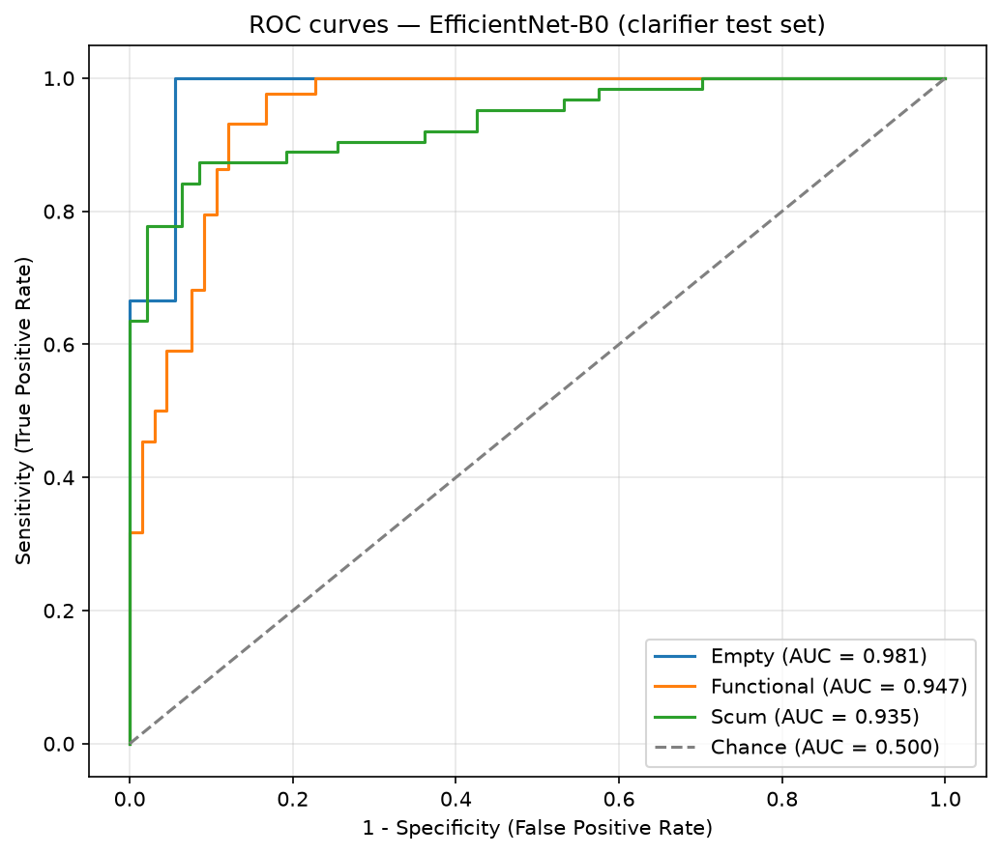

**ConvNeXt-Tiny** - test accuracy 0.836, mean AUC 0.964

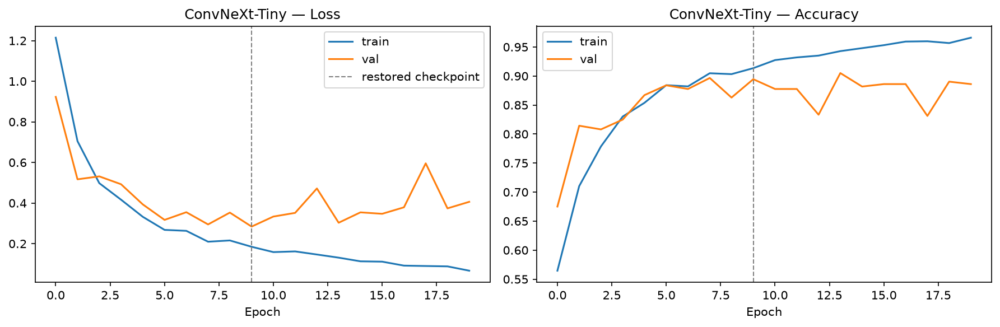

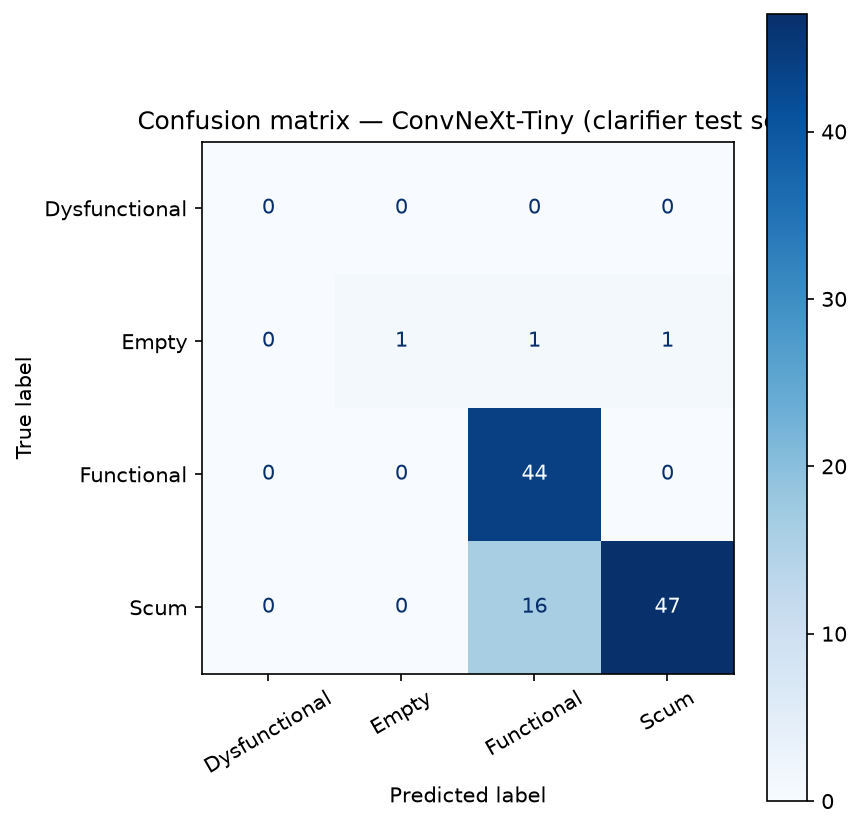

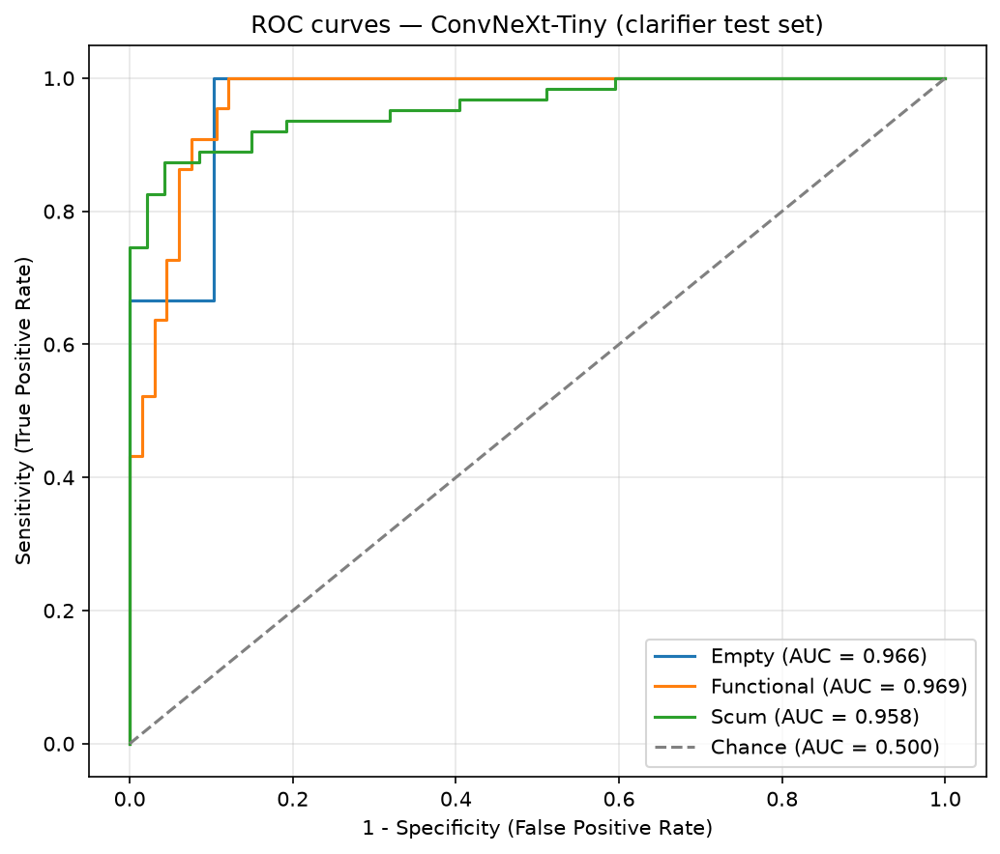

**AlexNet** - test accuracy 0.727, mean AUC 0.881

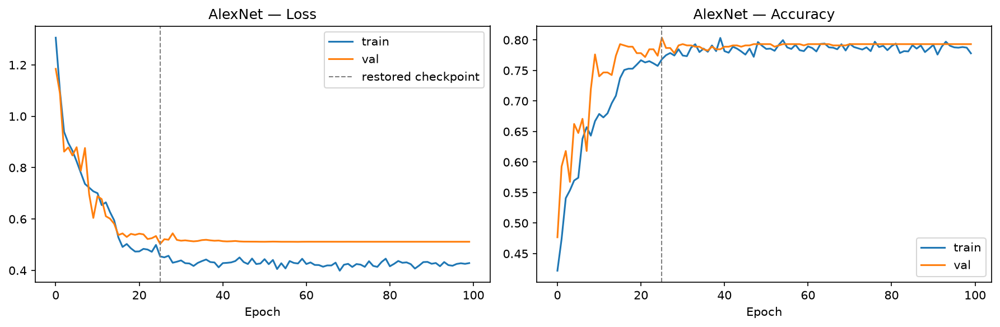

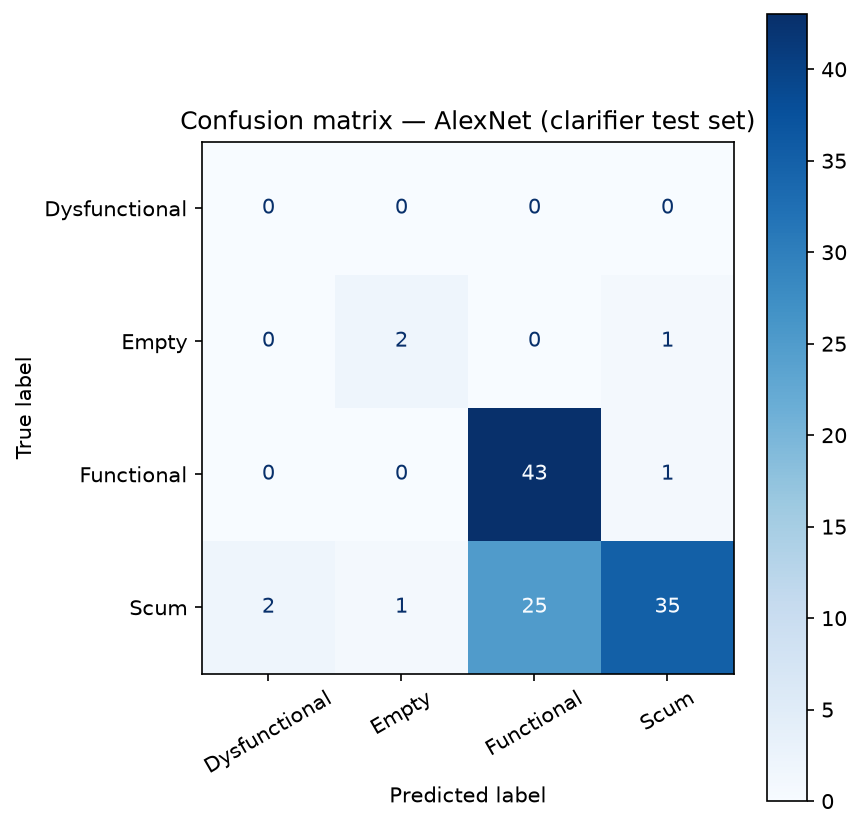

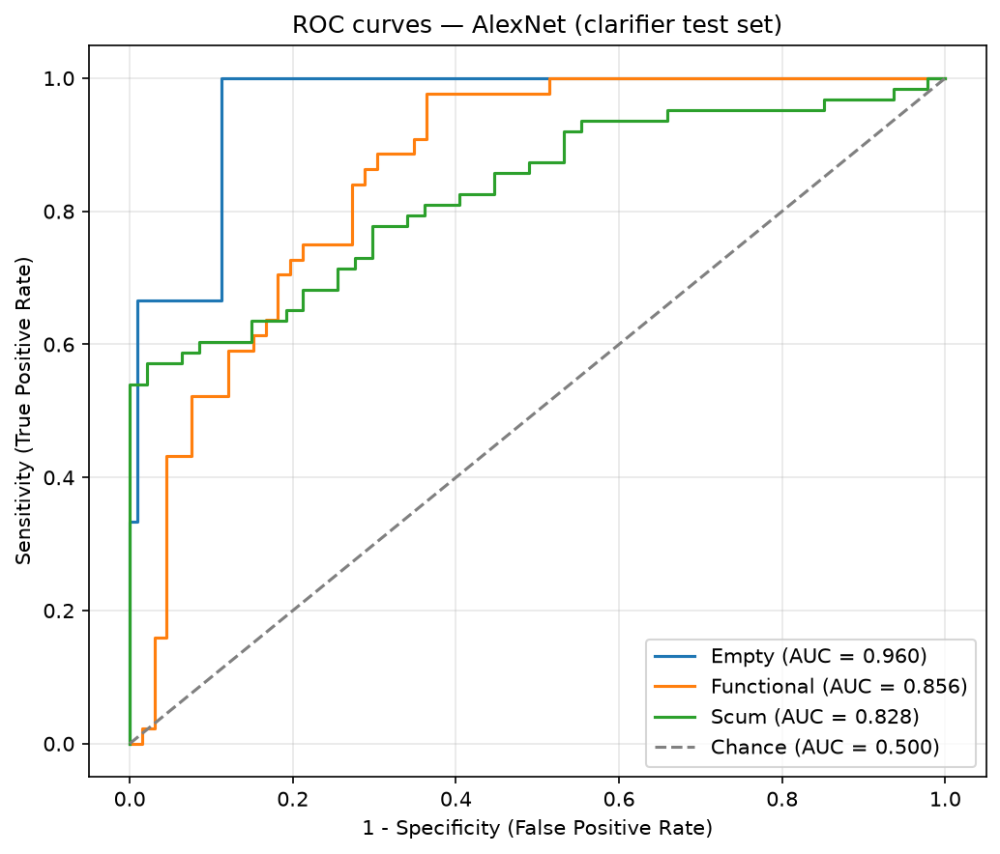

#### CapeFlats (held out)

**ResNet-18** - test accuracy 0.602, mean AUC 0.866

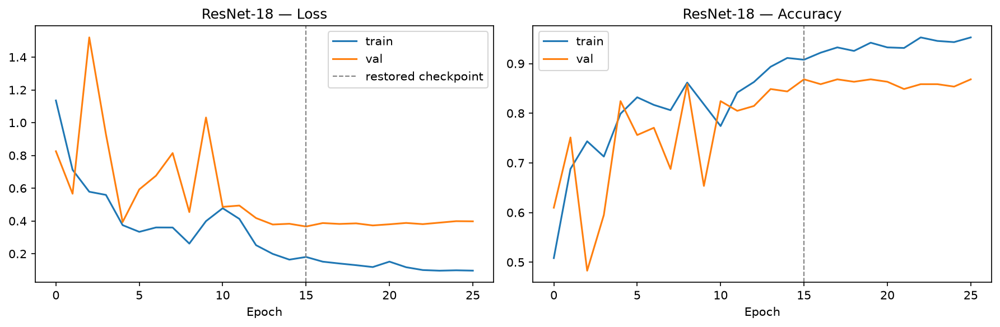

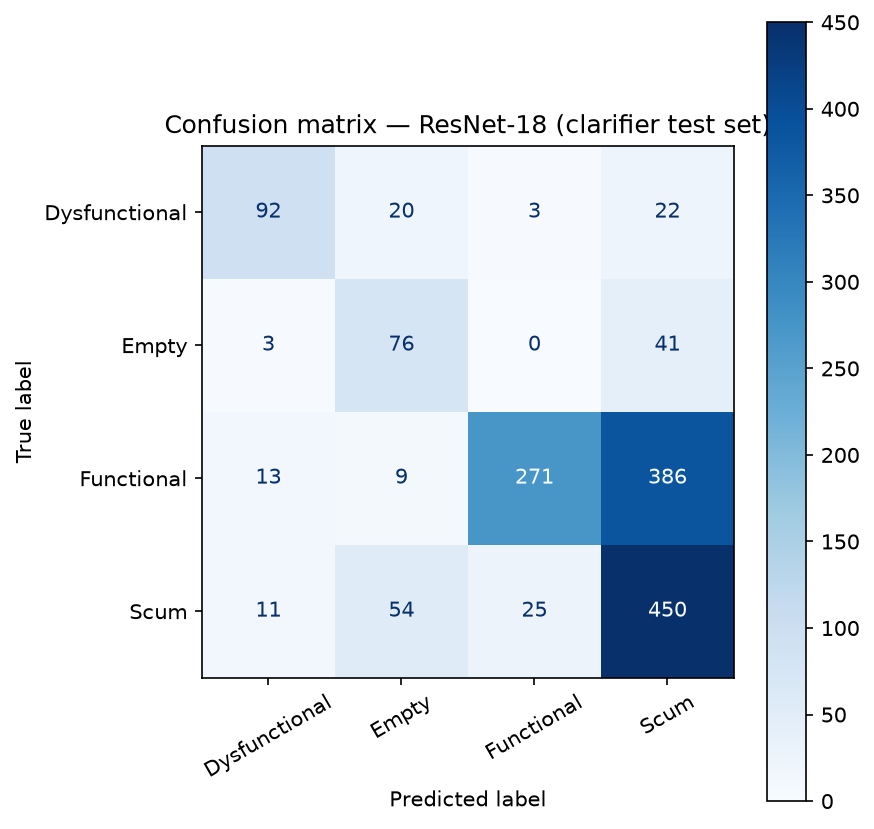

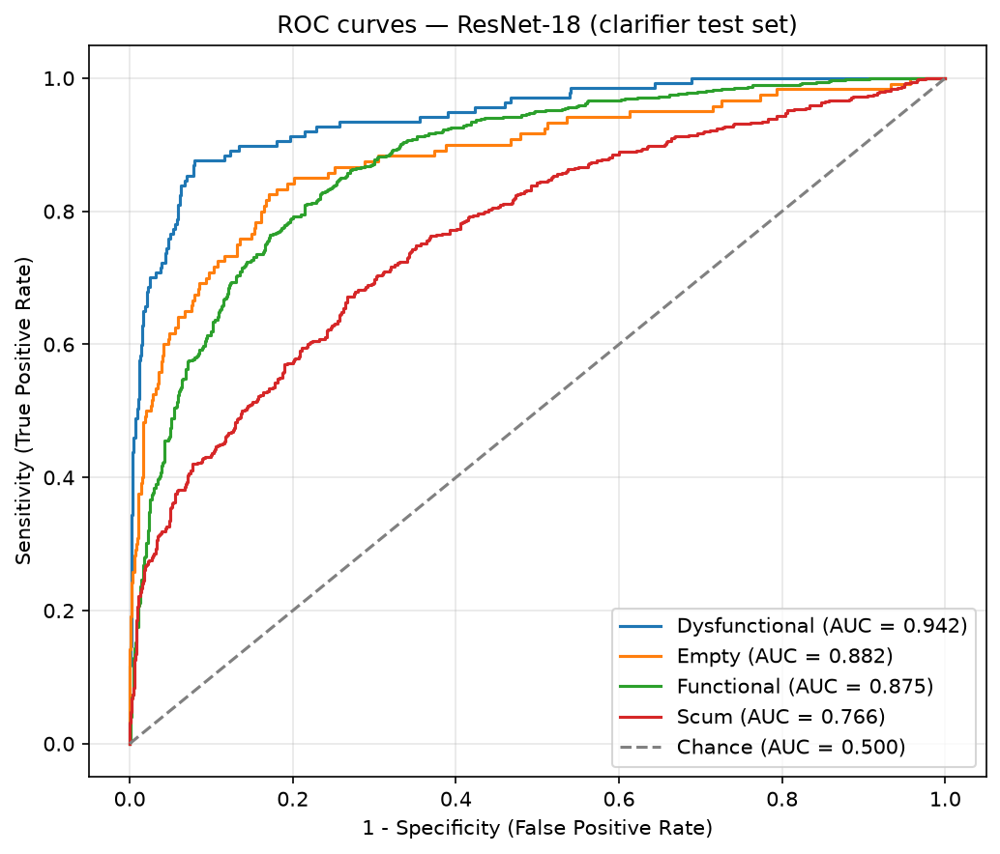

**ResNet-50** - test accuracy 0.669, mean AUC 0.854

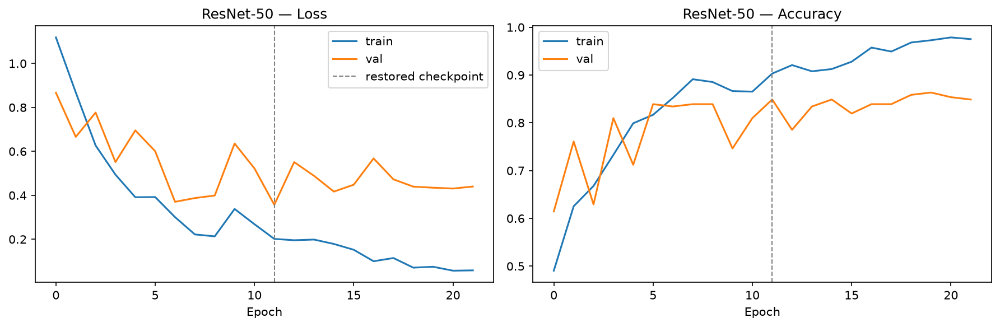

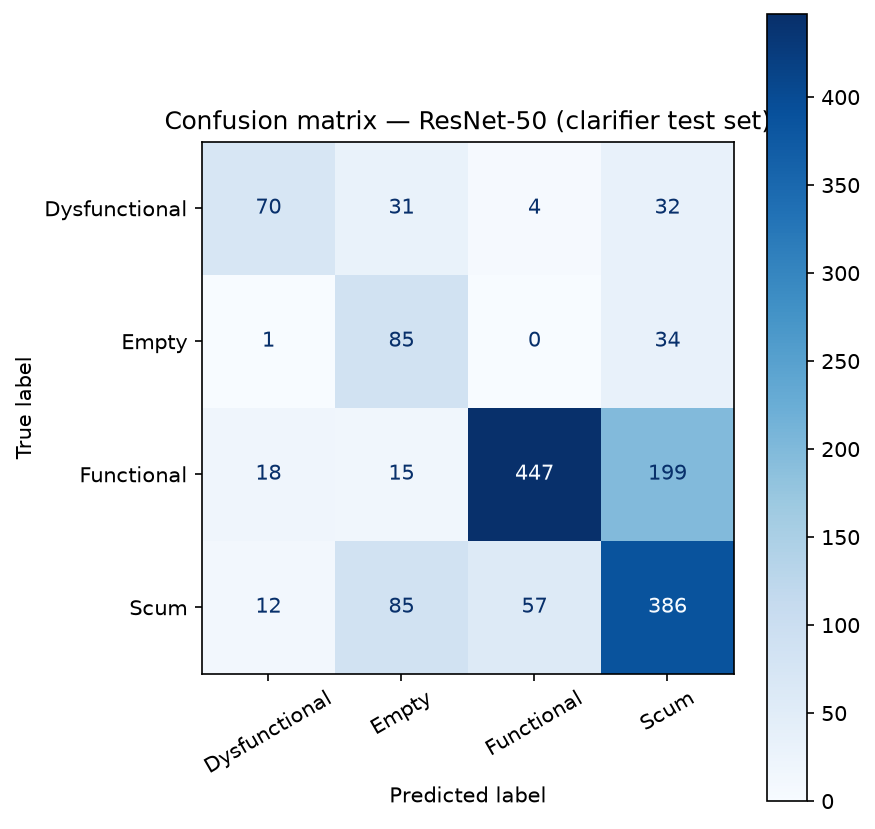

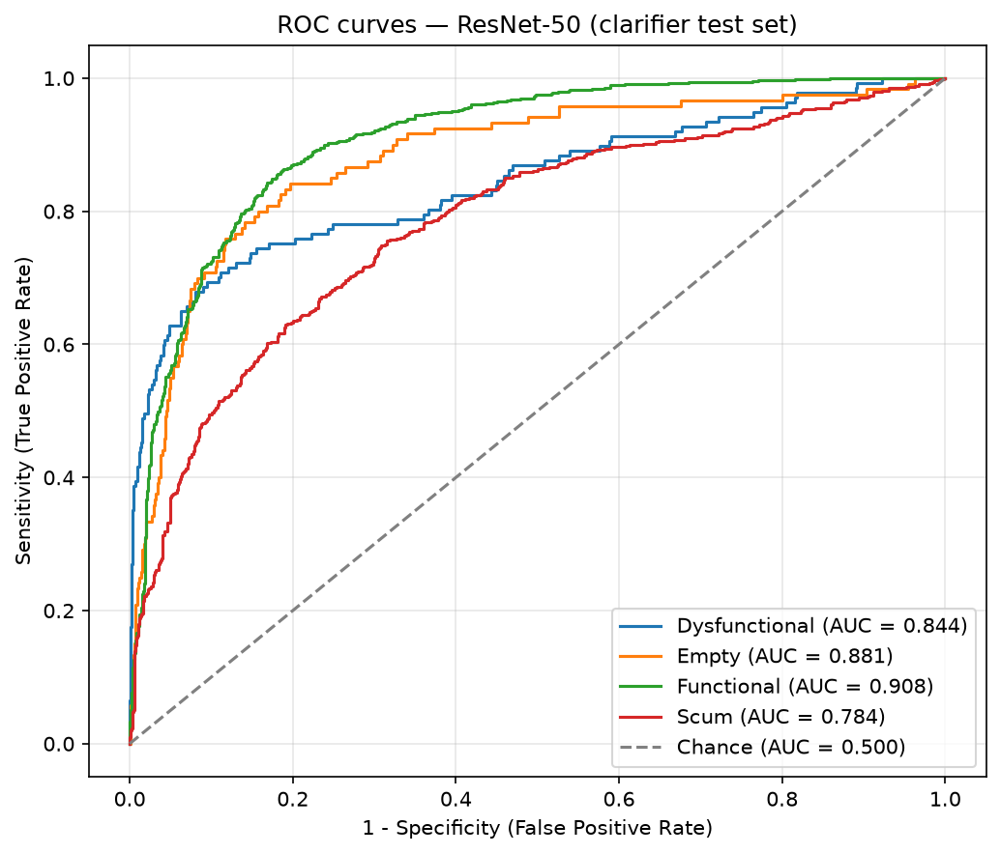

**DenseNet-121** - test accuracy 0.626, mean AUC 0.869

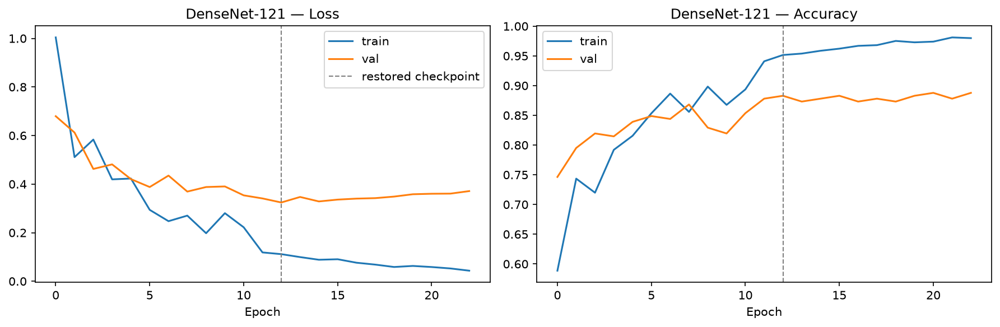

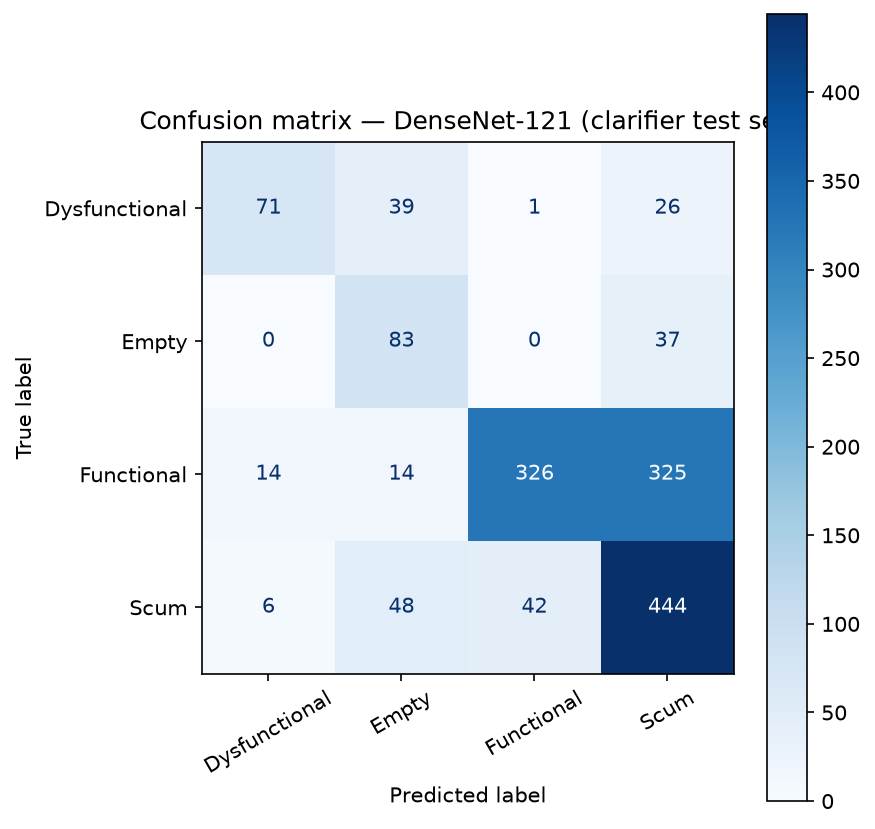

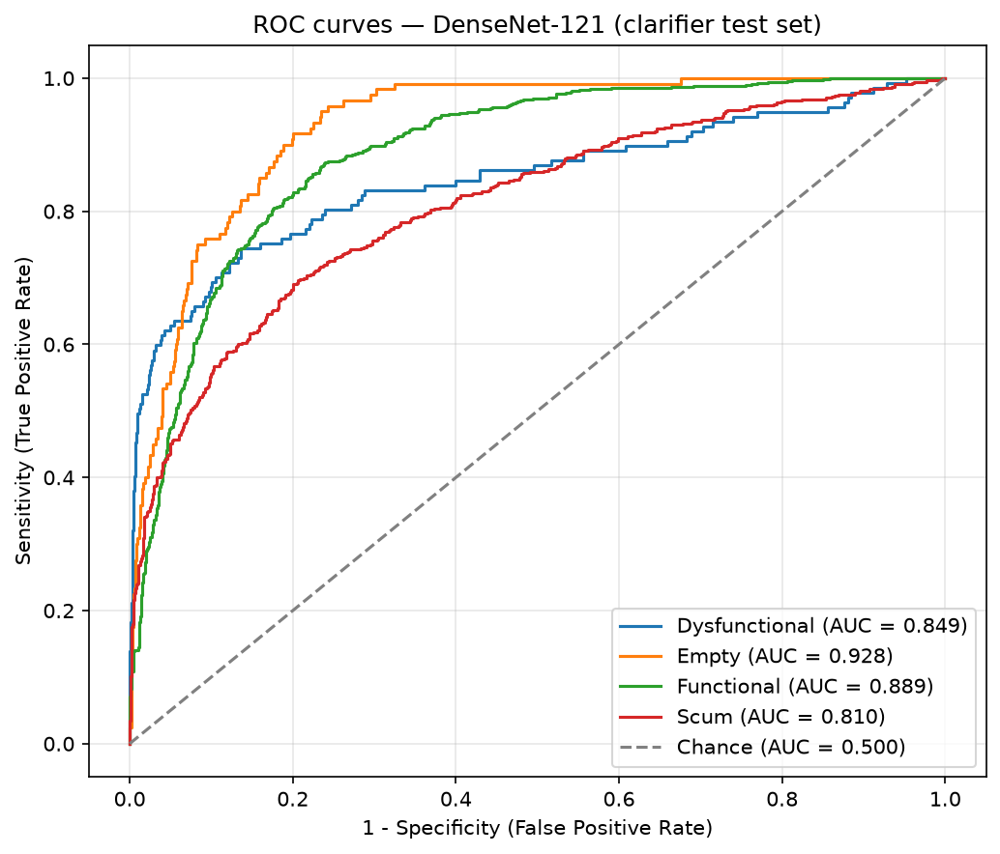

**InceptionNet v3** - test accuracy 0.619, mean AUC 0.854

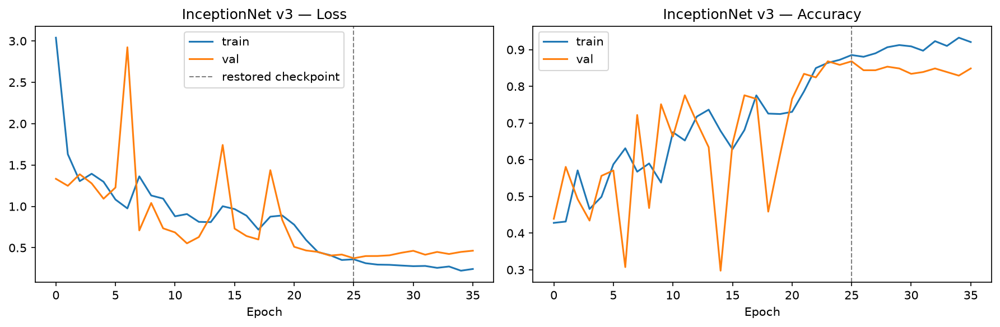

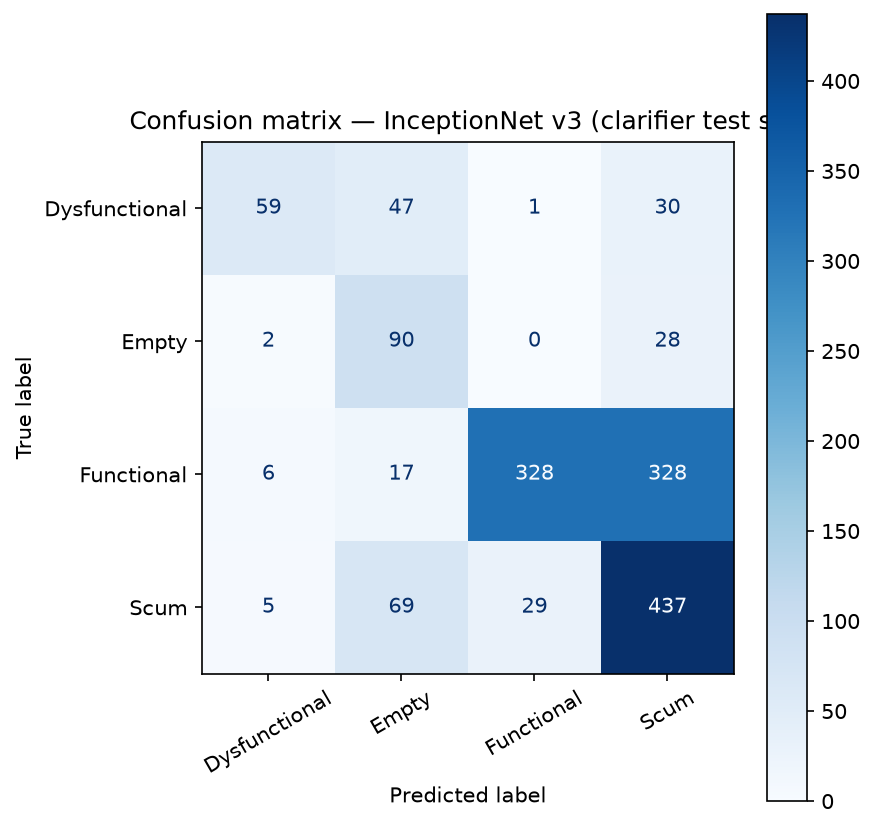

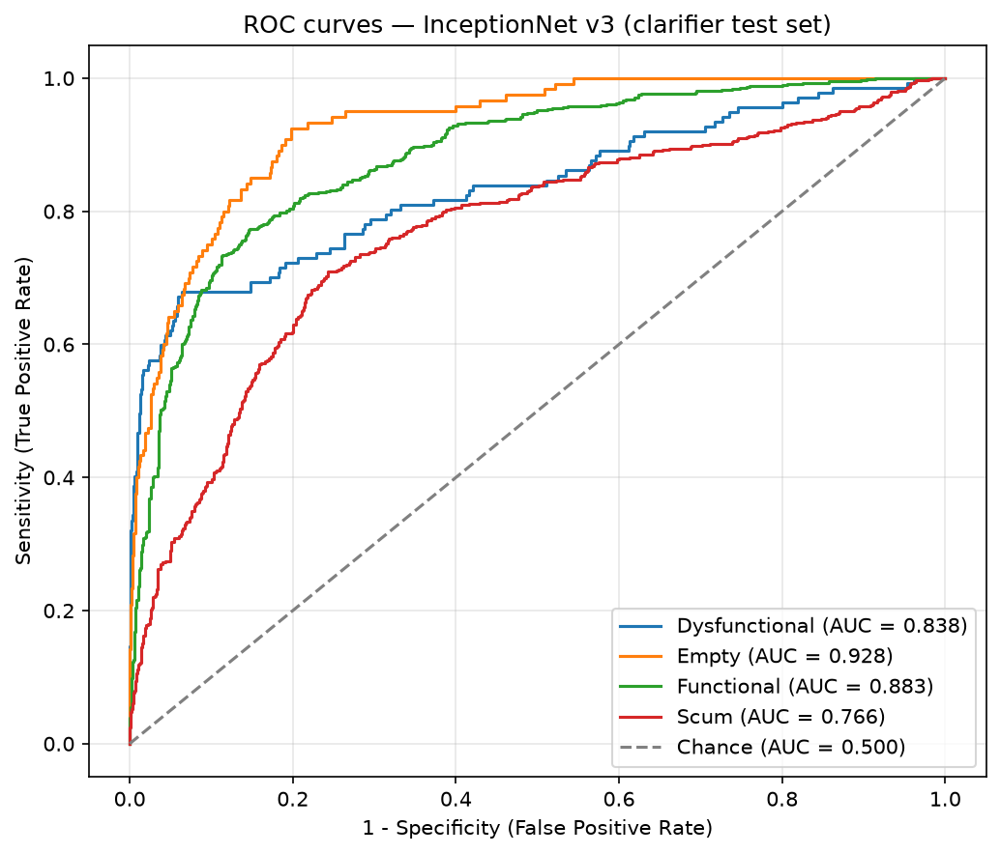

**EfficientNet-B0** - test accuracy 0.687, mean AUC 0.898

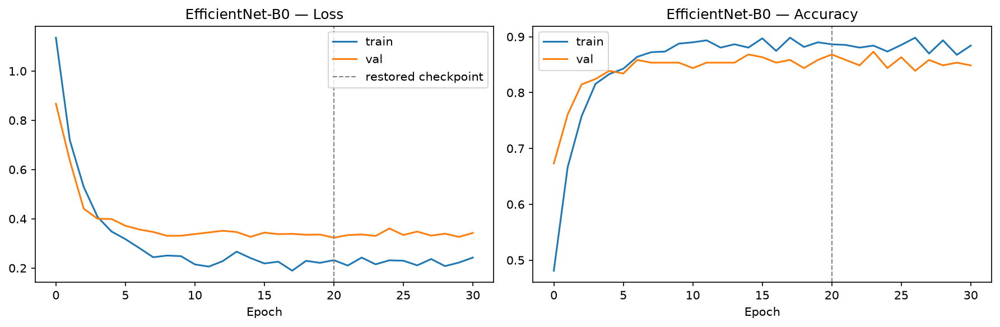

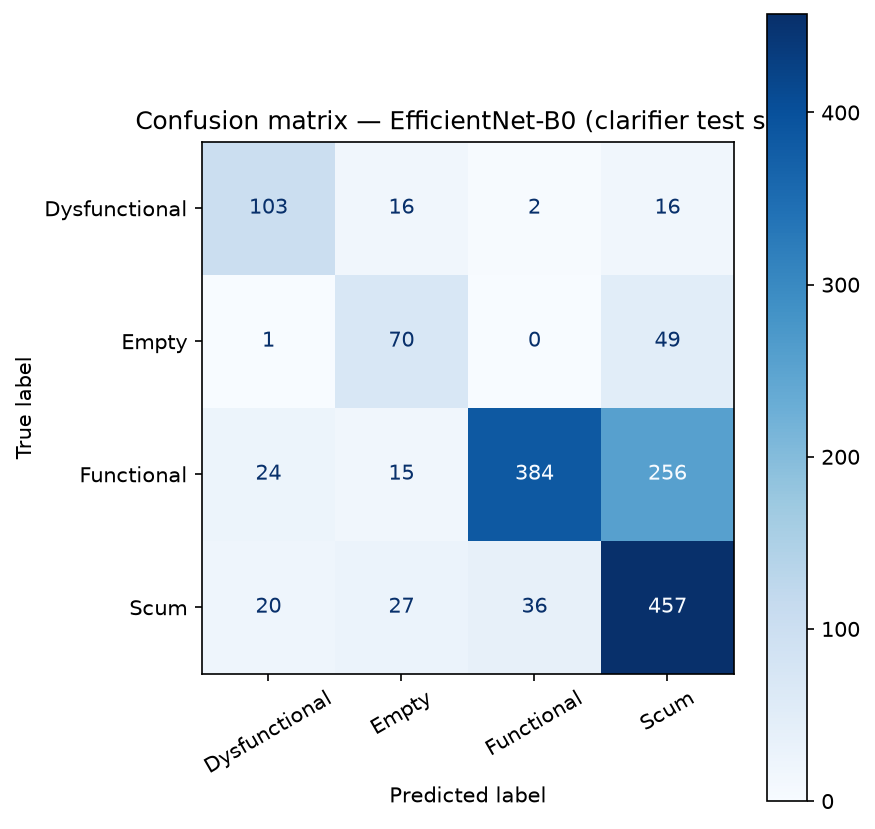

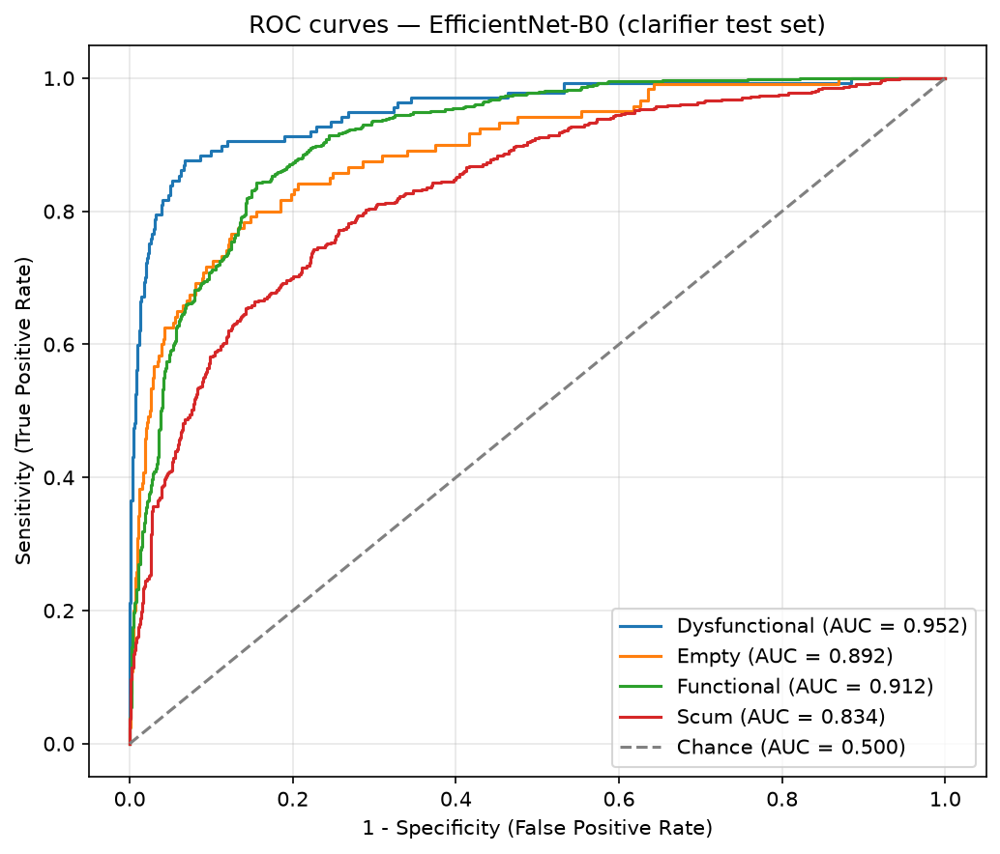

**ConvNeXt-Tiny** - test accuracy 0.699, mean AUC 0.932

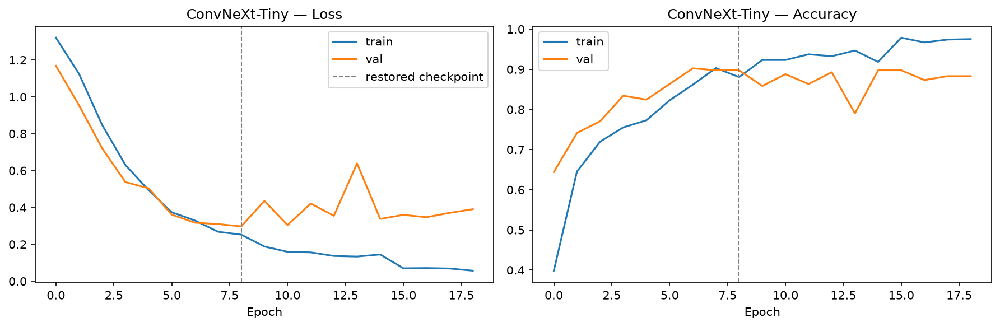

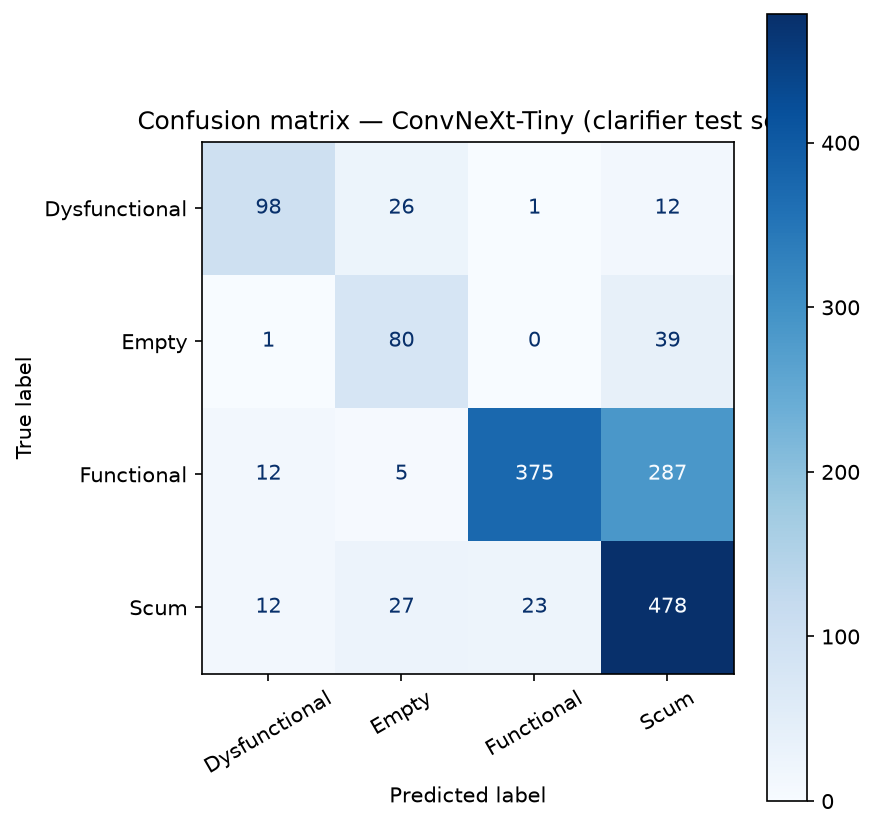

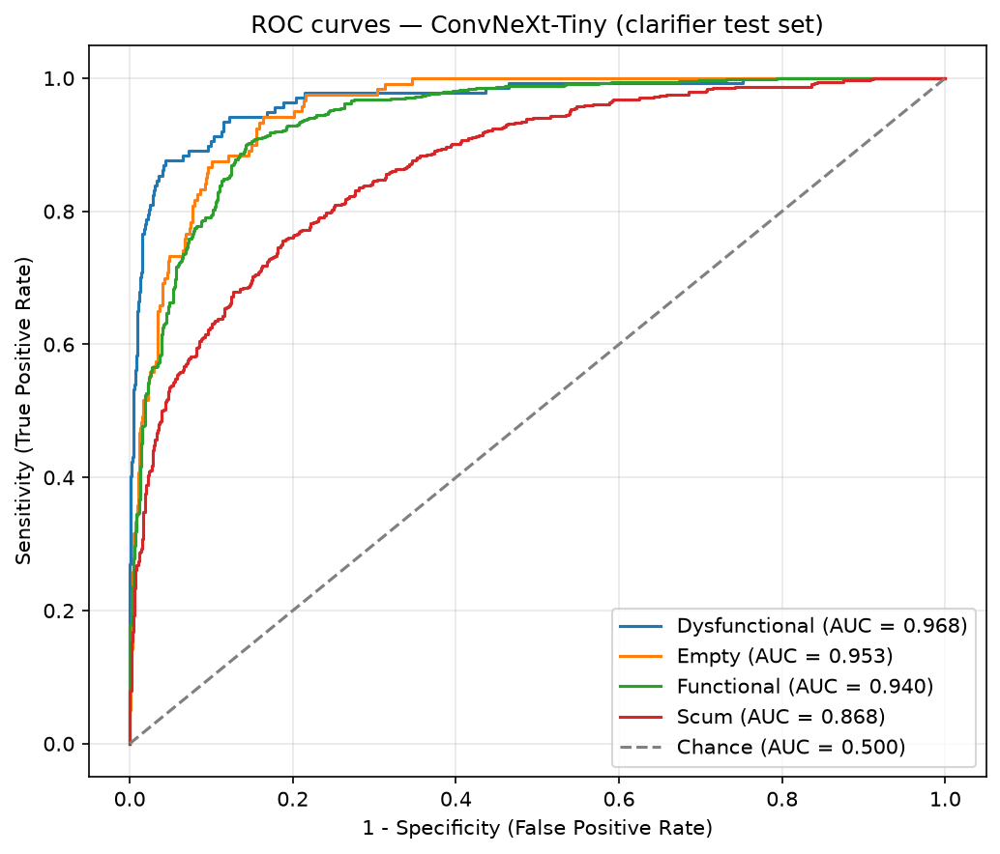

**AlexNet** - test accuracy 0.523, mean AUC 0.835

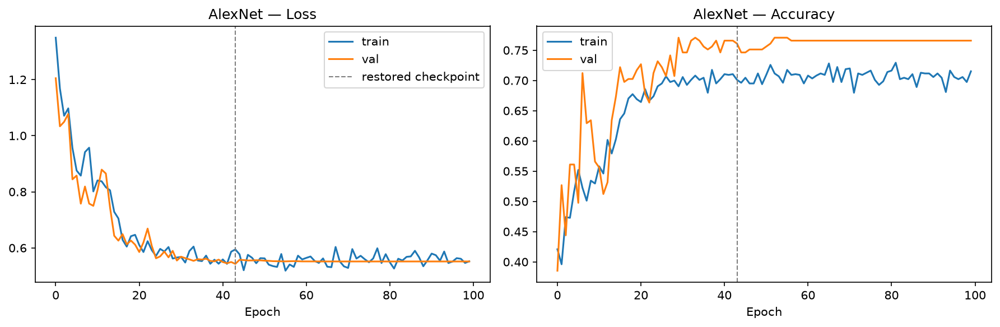

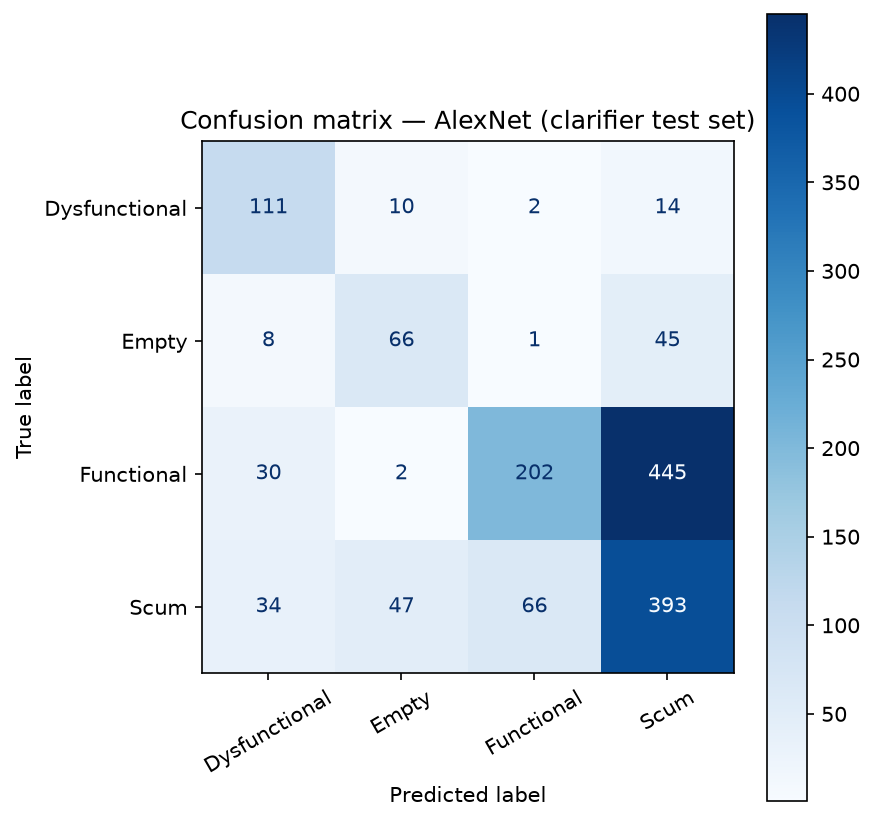

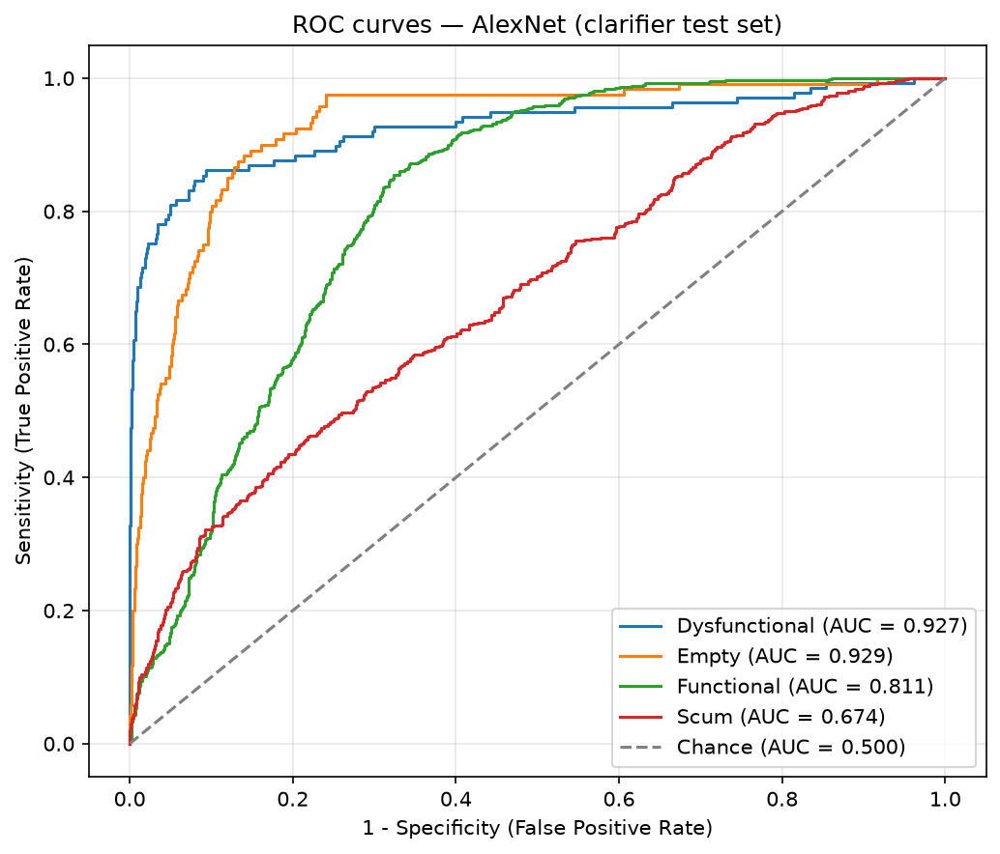

#### Waterval (held out)

**ResNet-18** - test accuracy 0.824, mean AUC 0.938

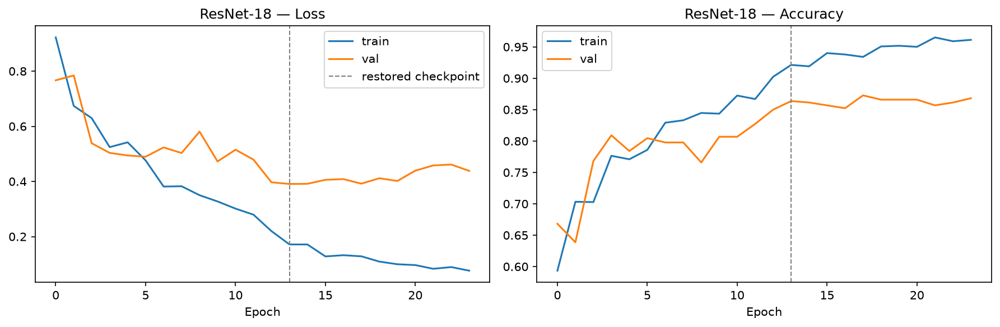

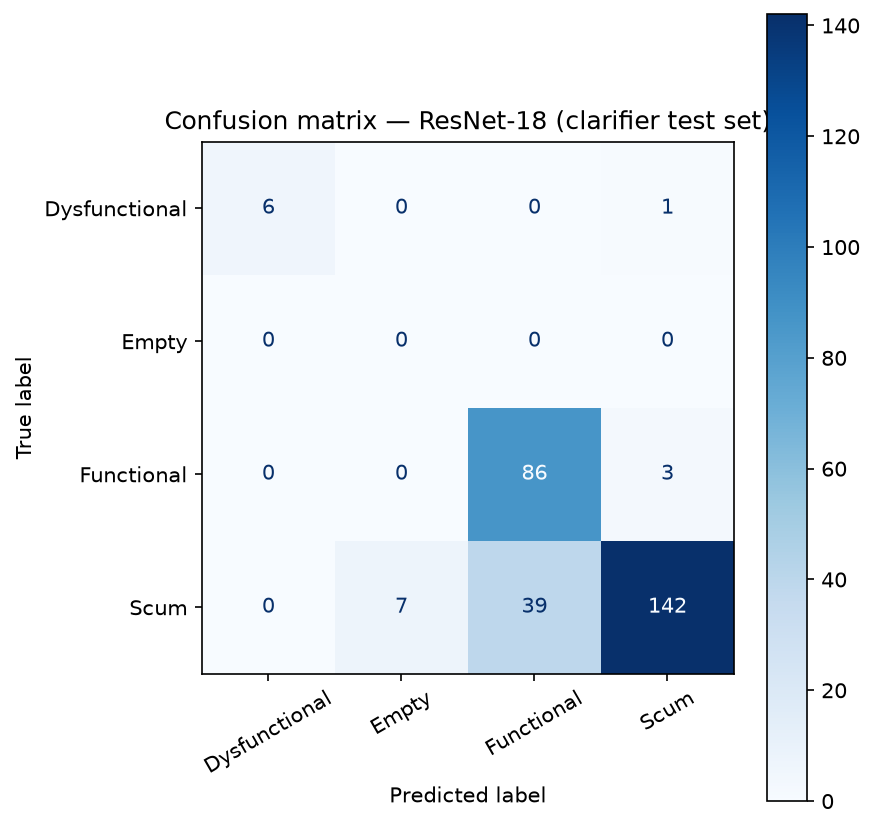

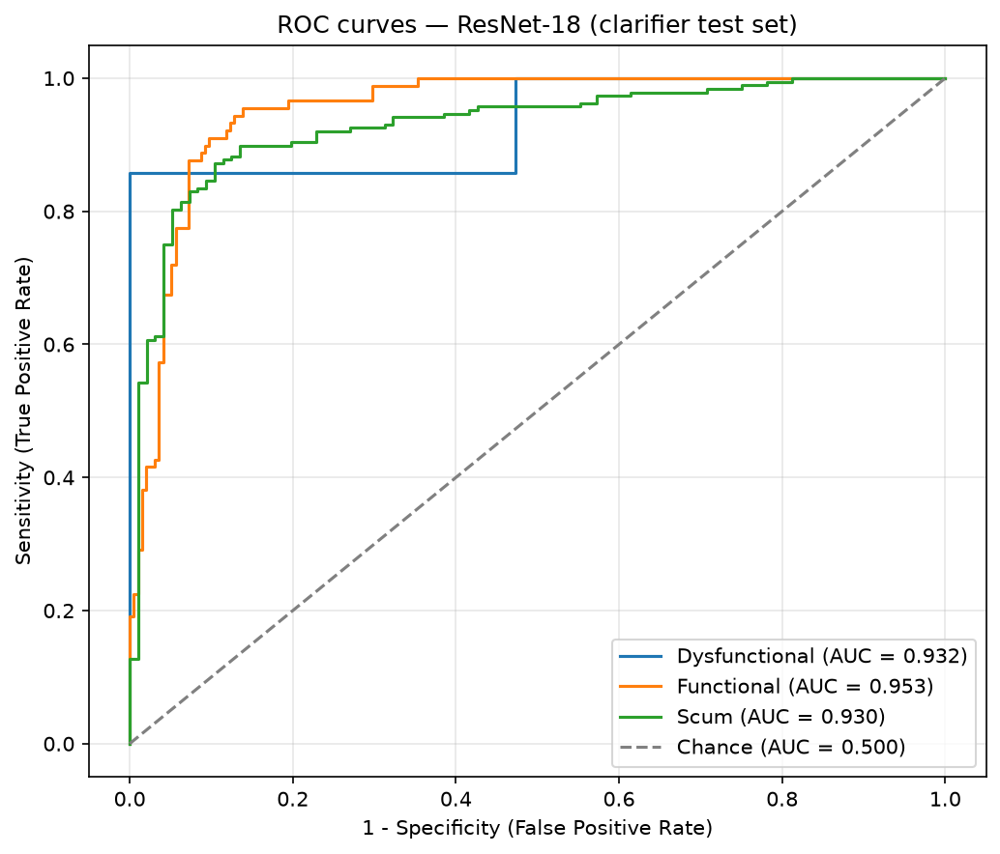

**ResNet-50** - test accuracy 0.870, mean AUC 0.945

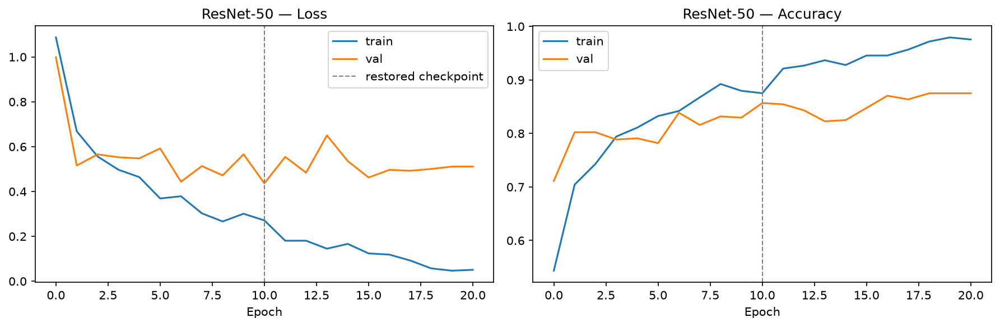

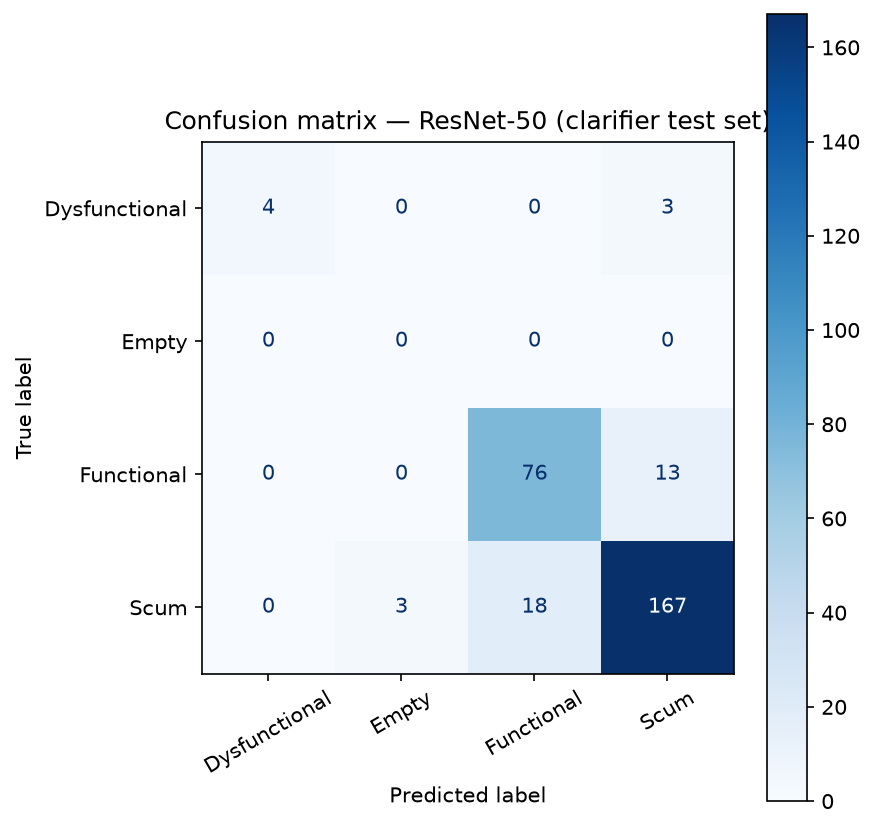

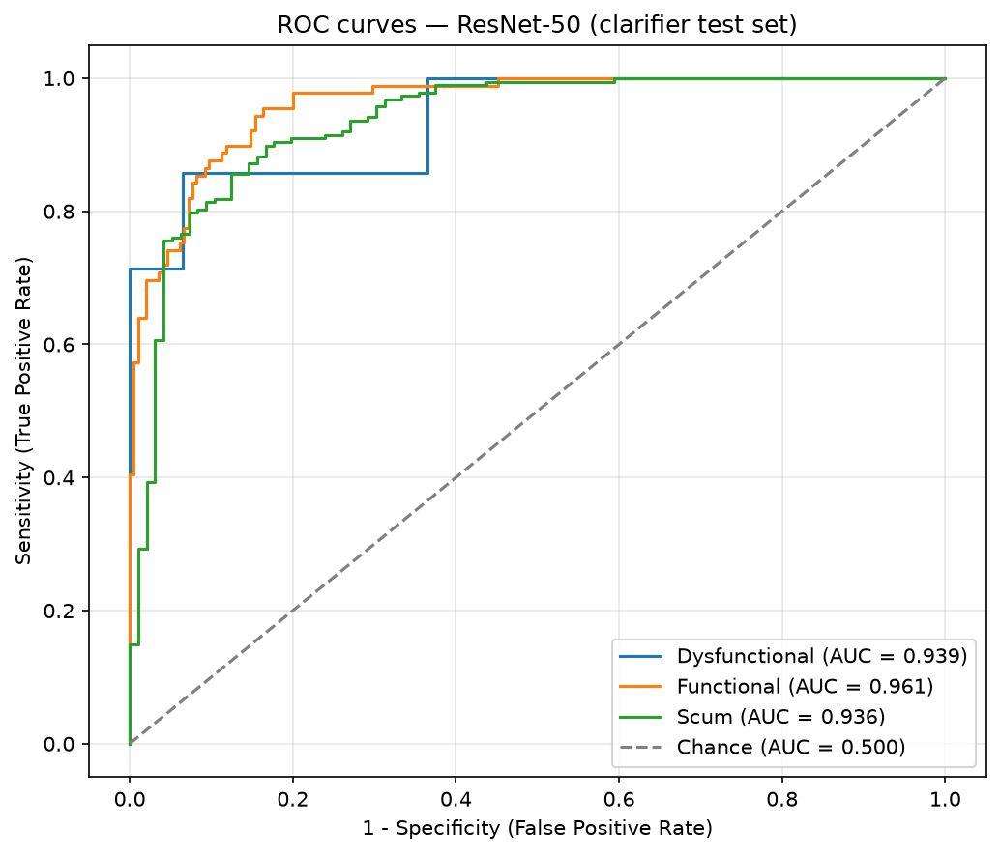

**DenseNet-121** - test accuracy 0.898, mean AUC 0.970

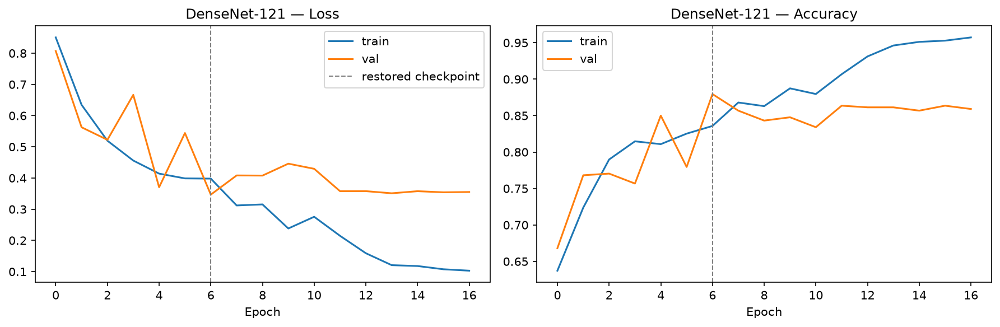

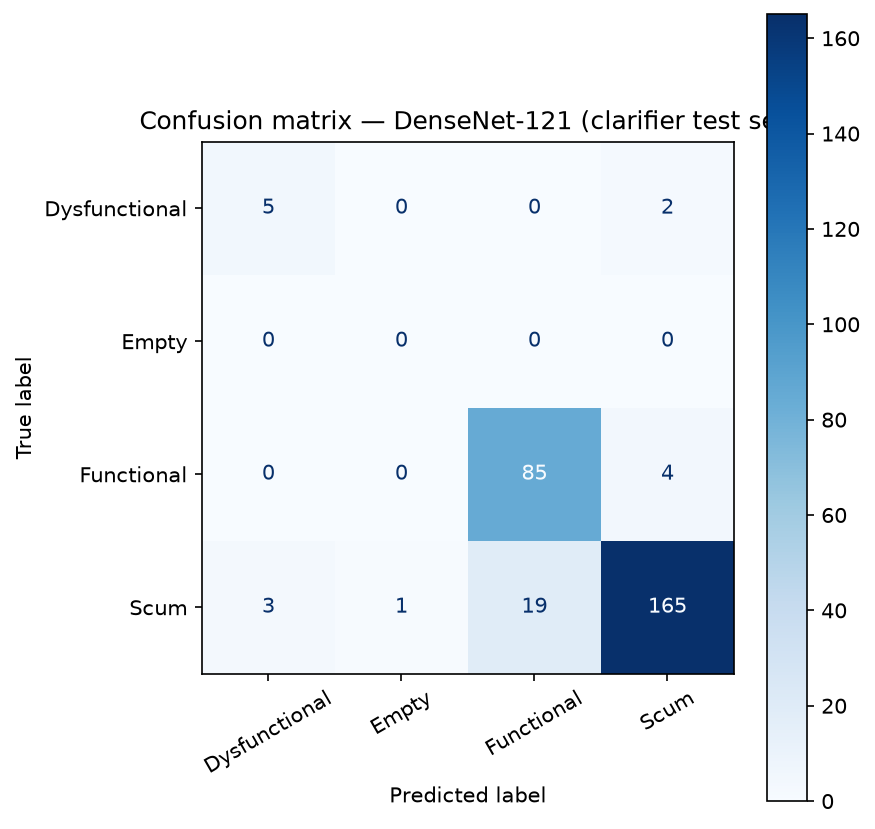

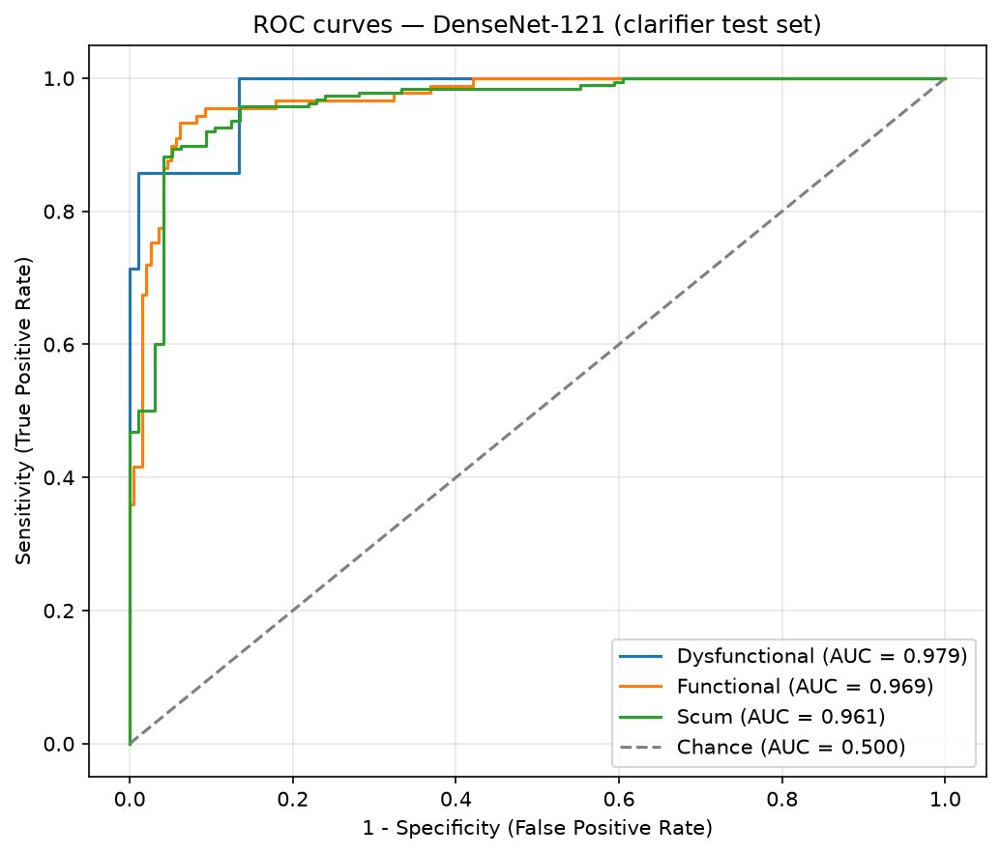

**InceptionNet v3** - test accuracy 0.884, mean AUC 0.969

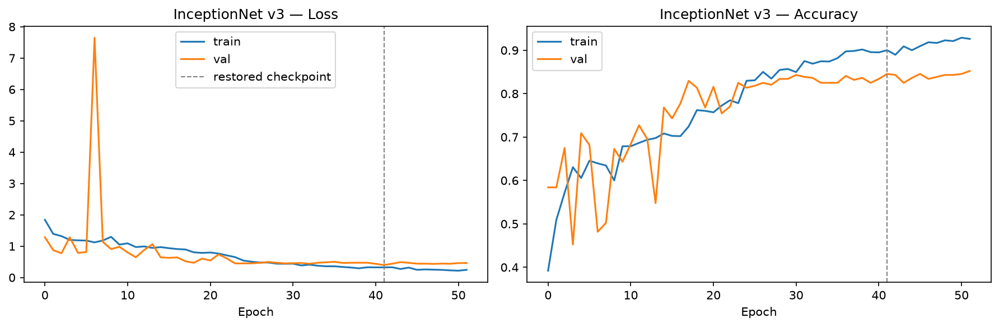

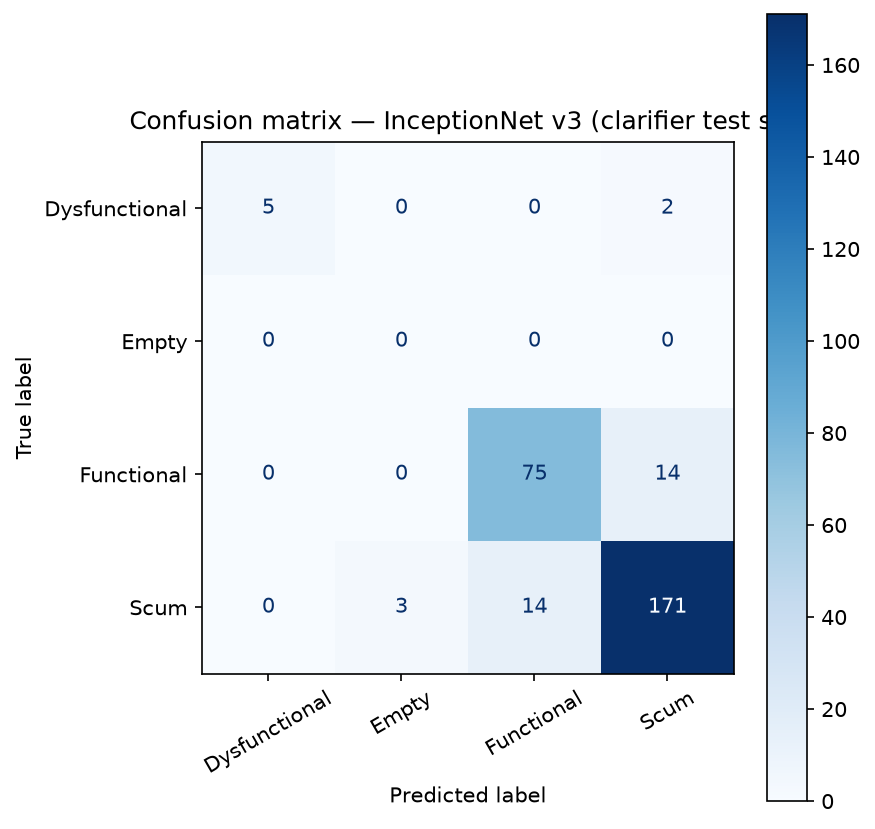

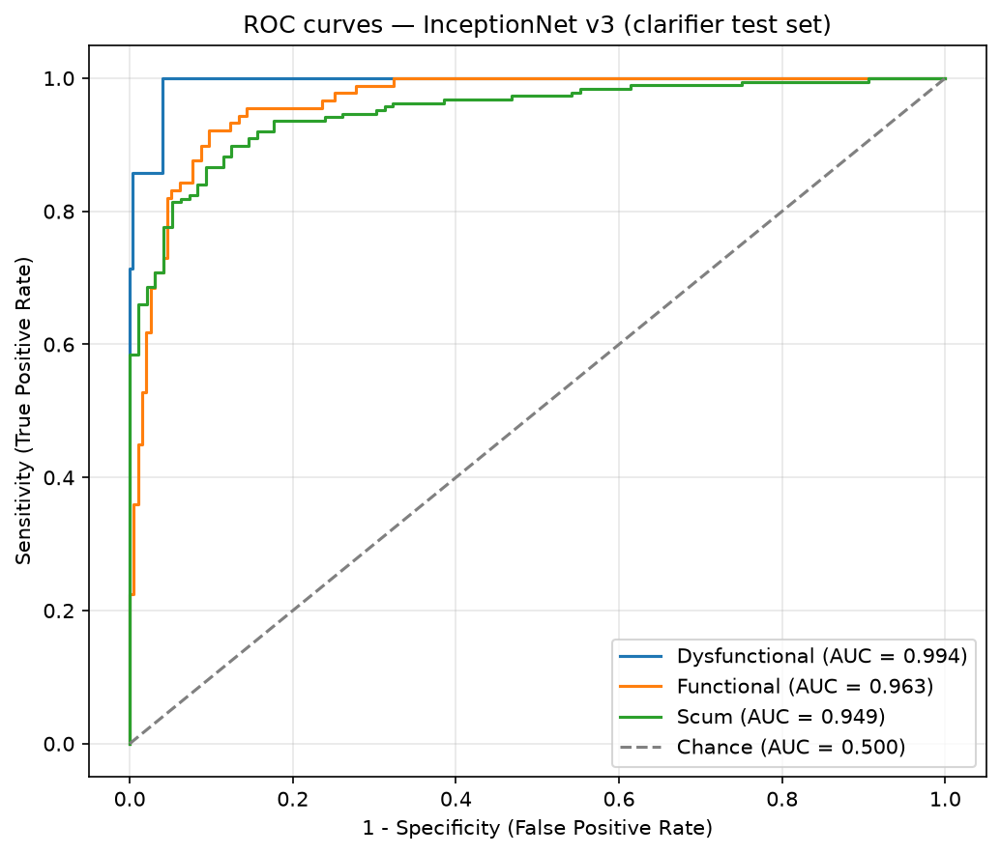

**EfficientNet-B0** - test accuracy 0.898, mean AUC 0.978

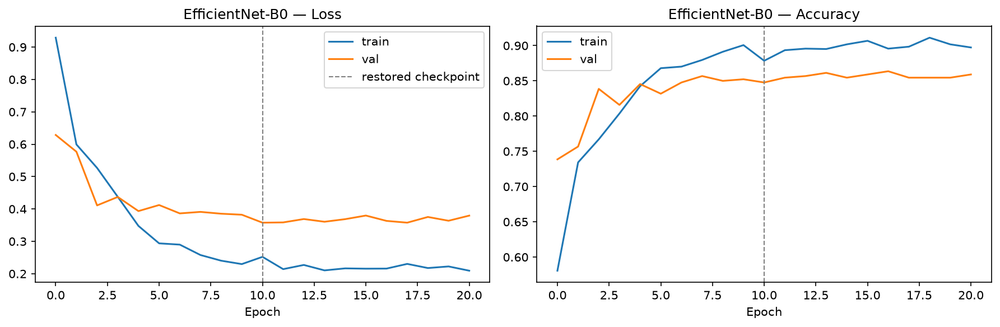

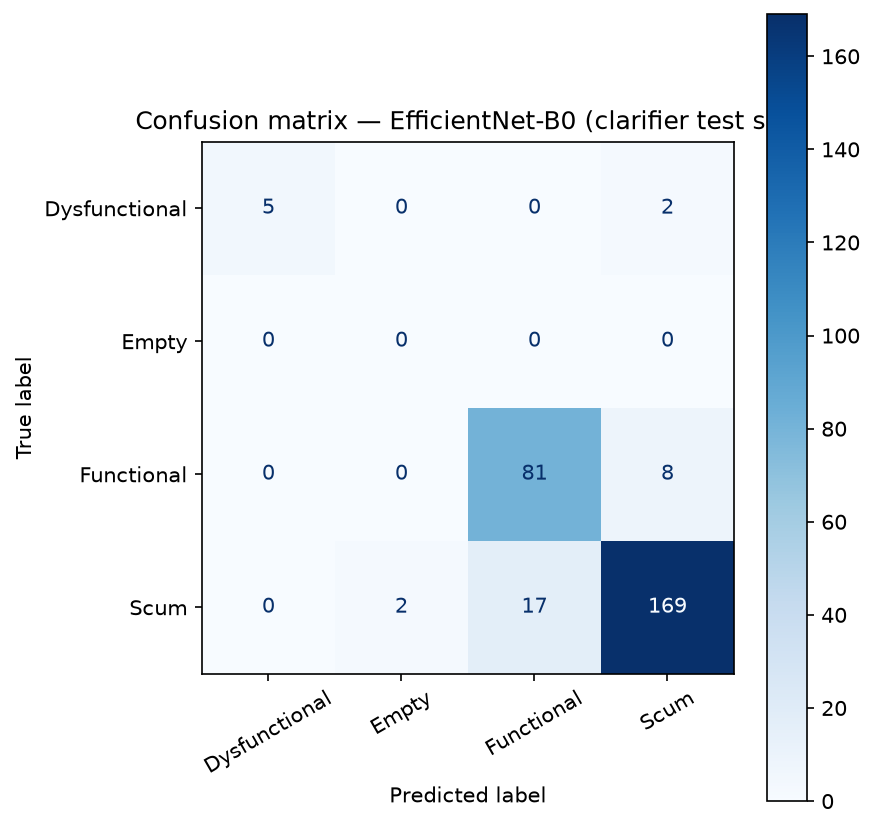

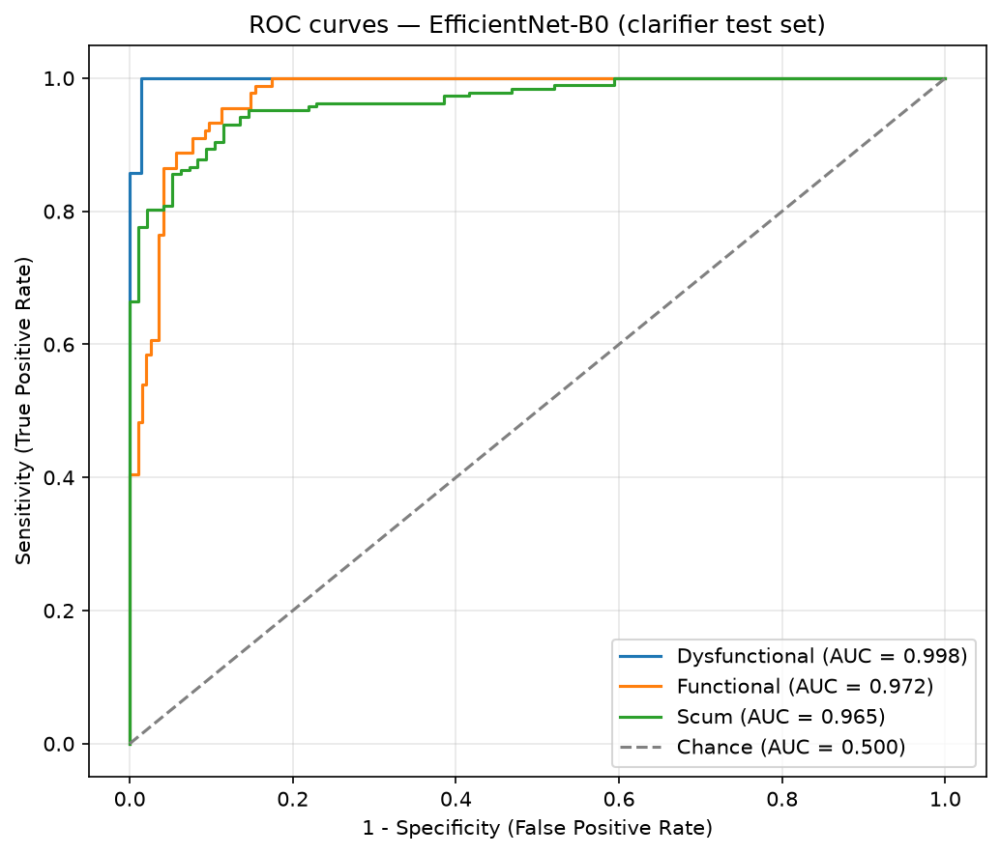

**ConvNeXt-Tiny** - test accuracy 0.877, mean AUC 0.973

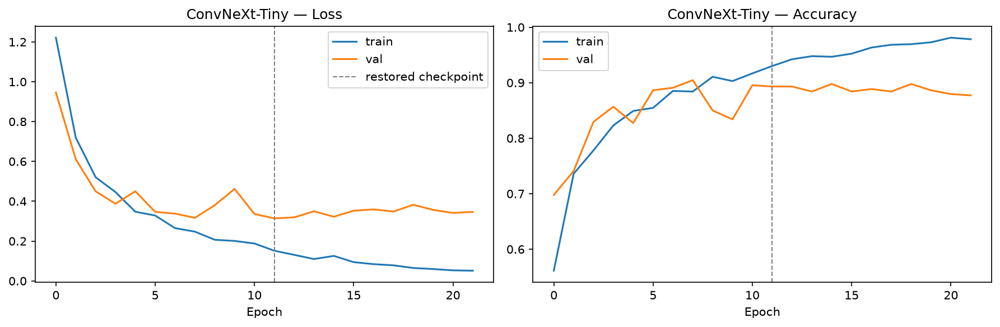

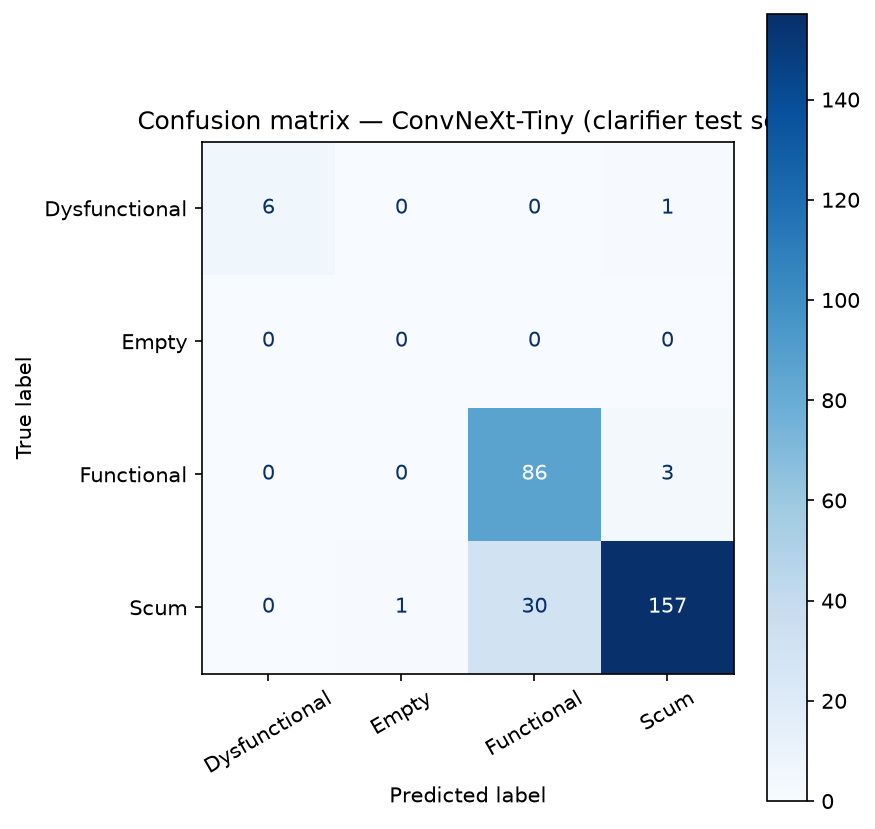

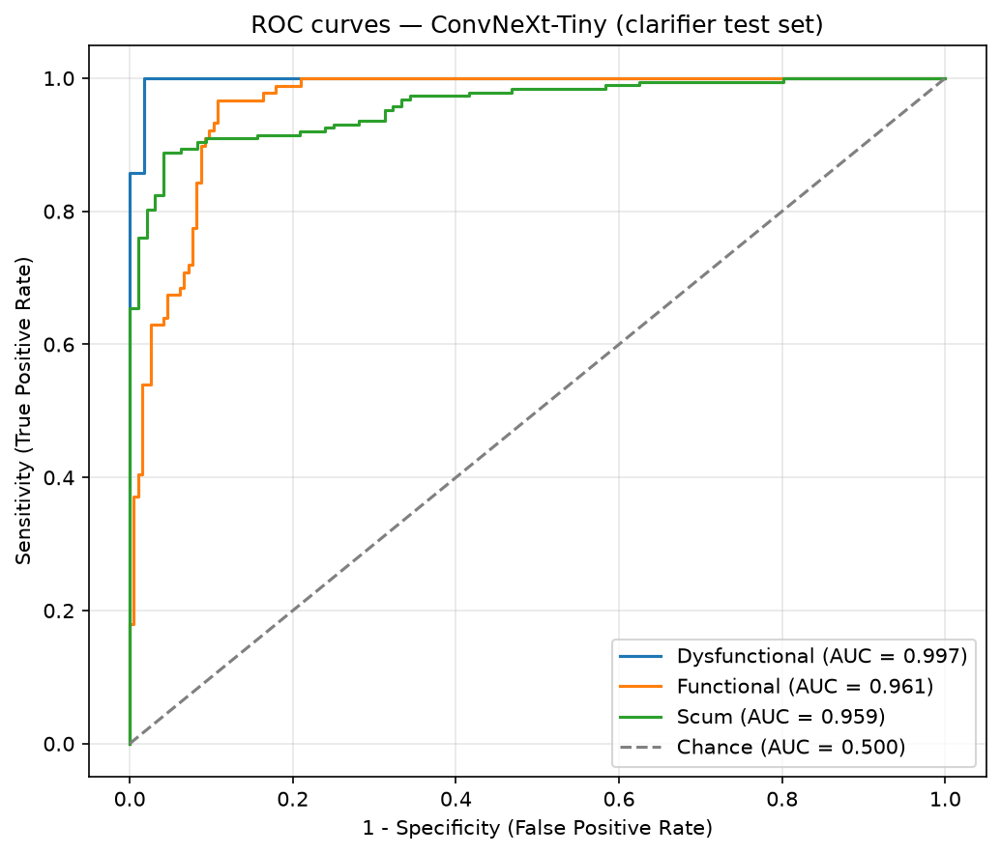

**AlexNet** - test accuracy 0.754, mean AUC 0.819

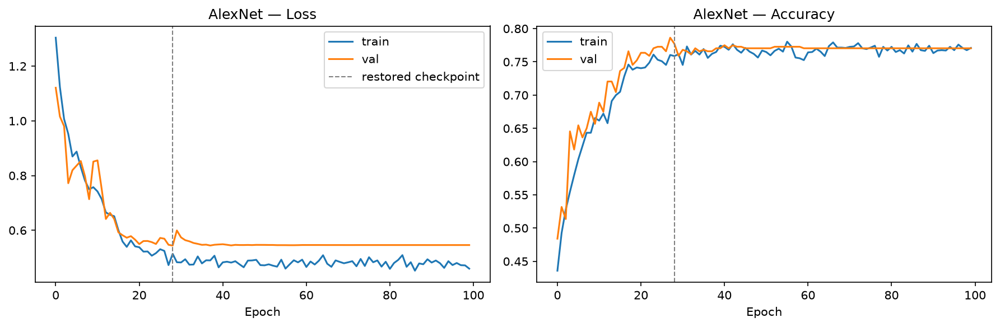

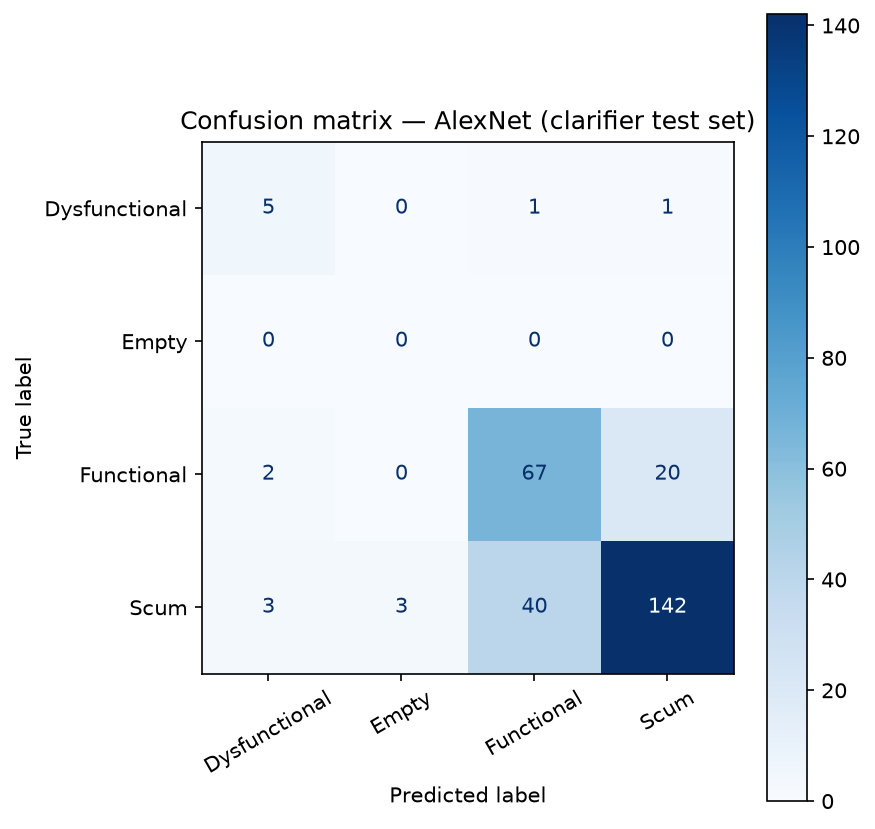

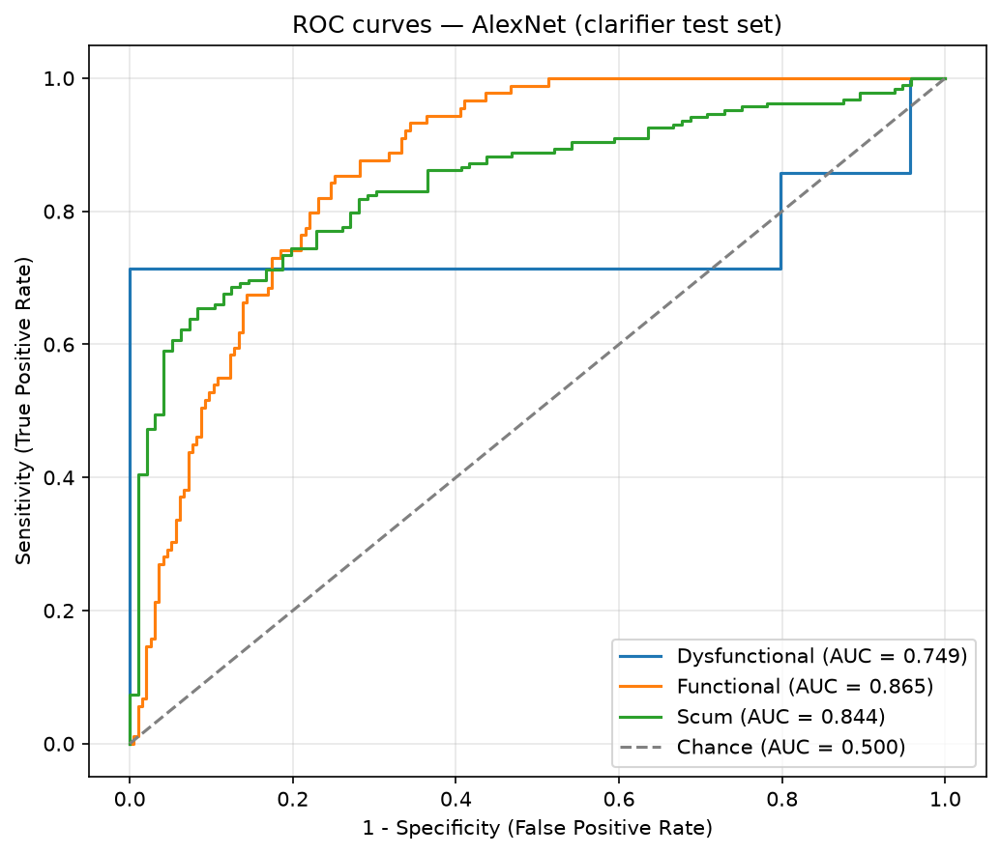

#### Fisantekraal (held out)

**ResNet-18** - test accuracy 0.746, mean AUC 0.907

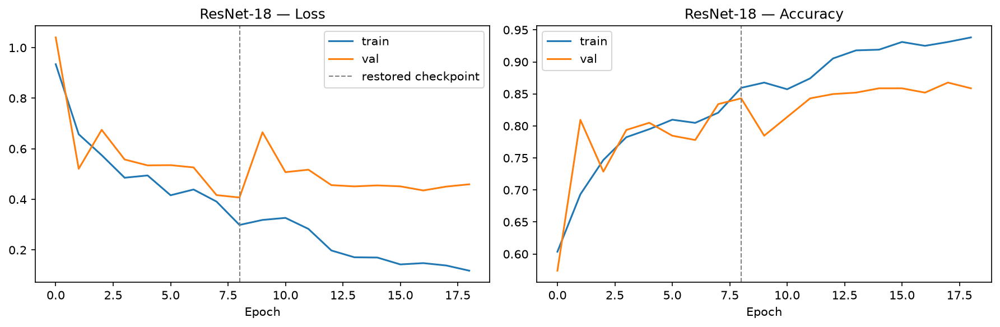

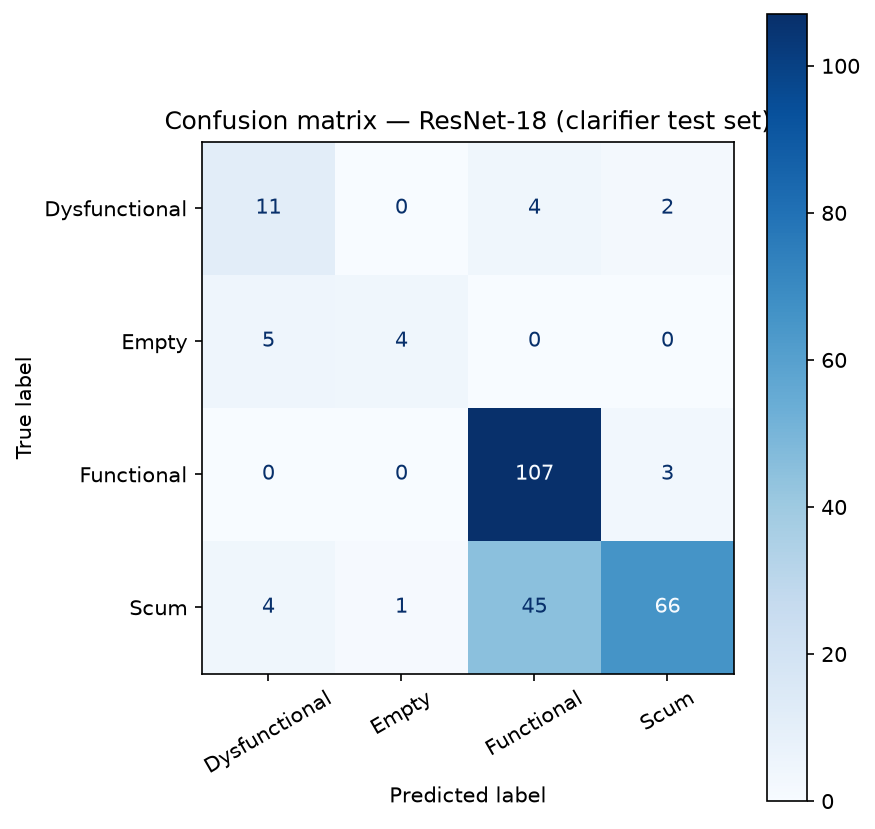

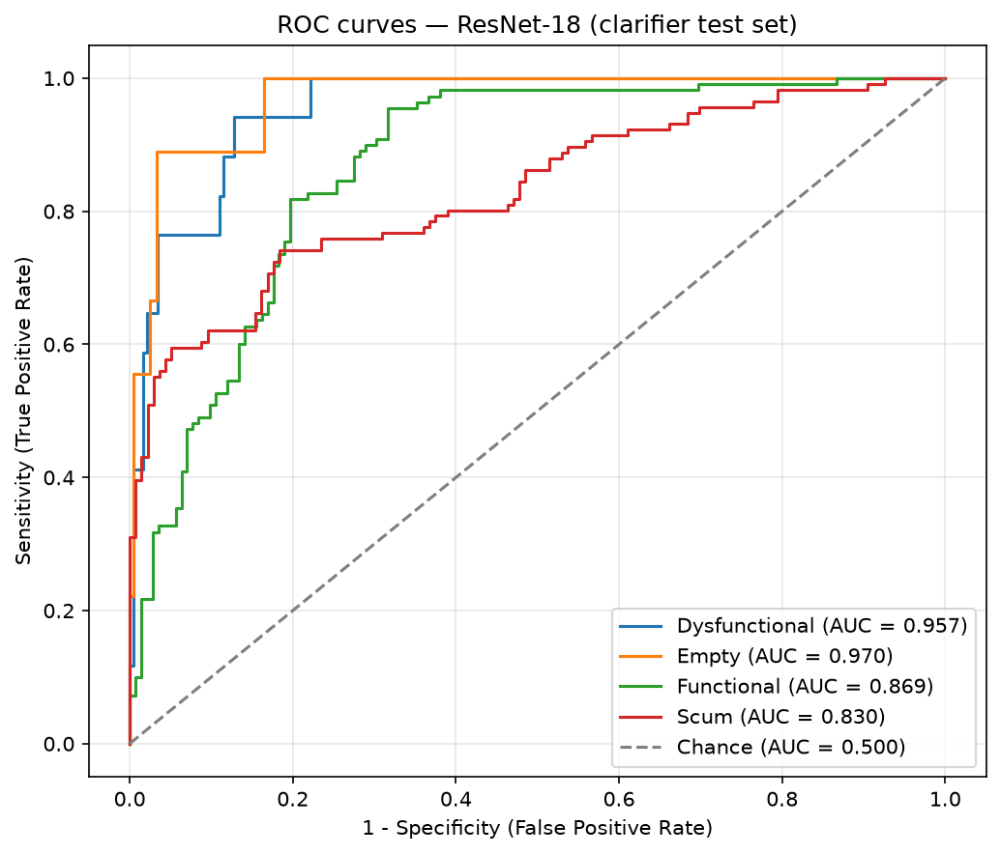

**ResNet-50** - test accuracy 0.758, mean AUC 0.892

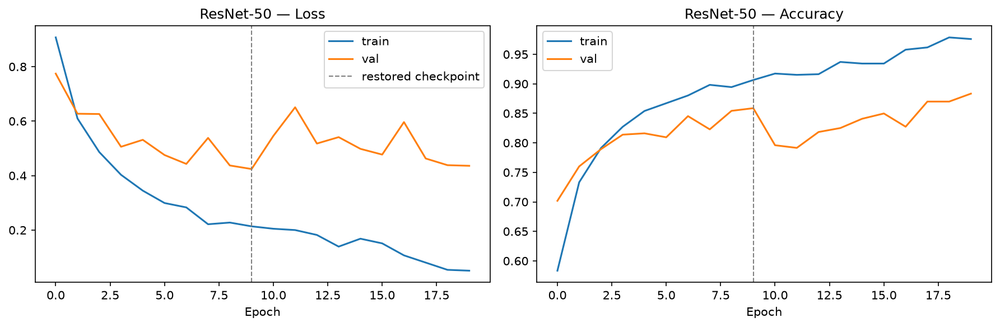

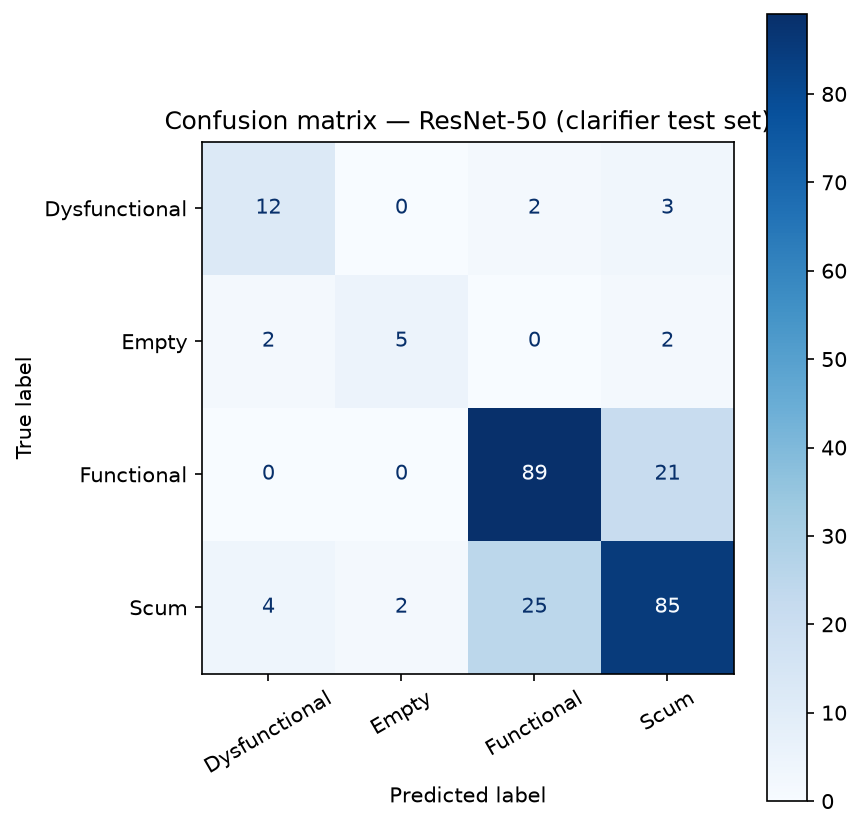

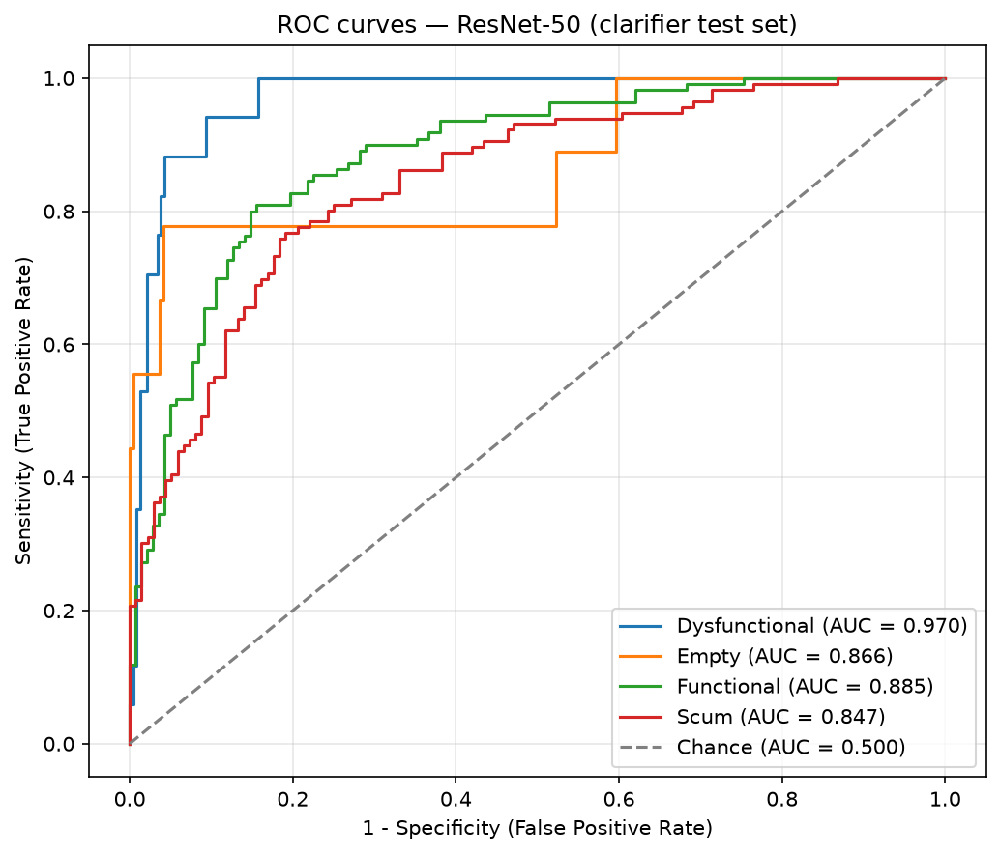

**DenseNet-121** - test accuracy 0.794, mean AUC 0.946

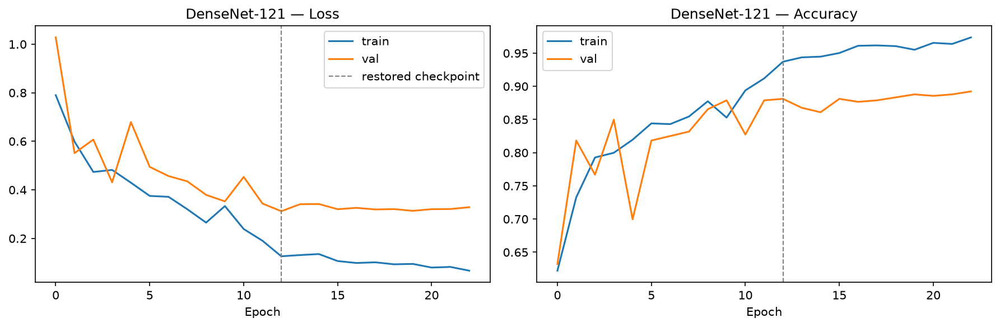

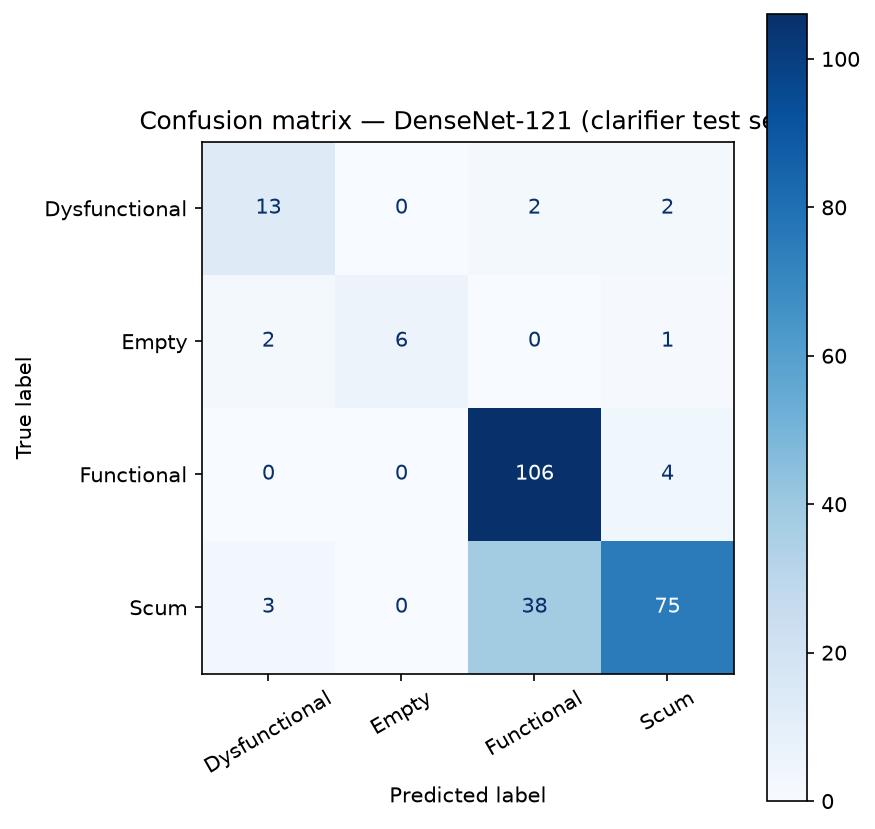

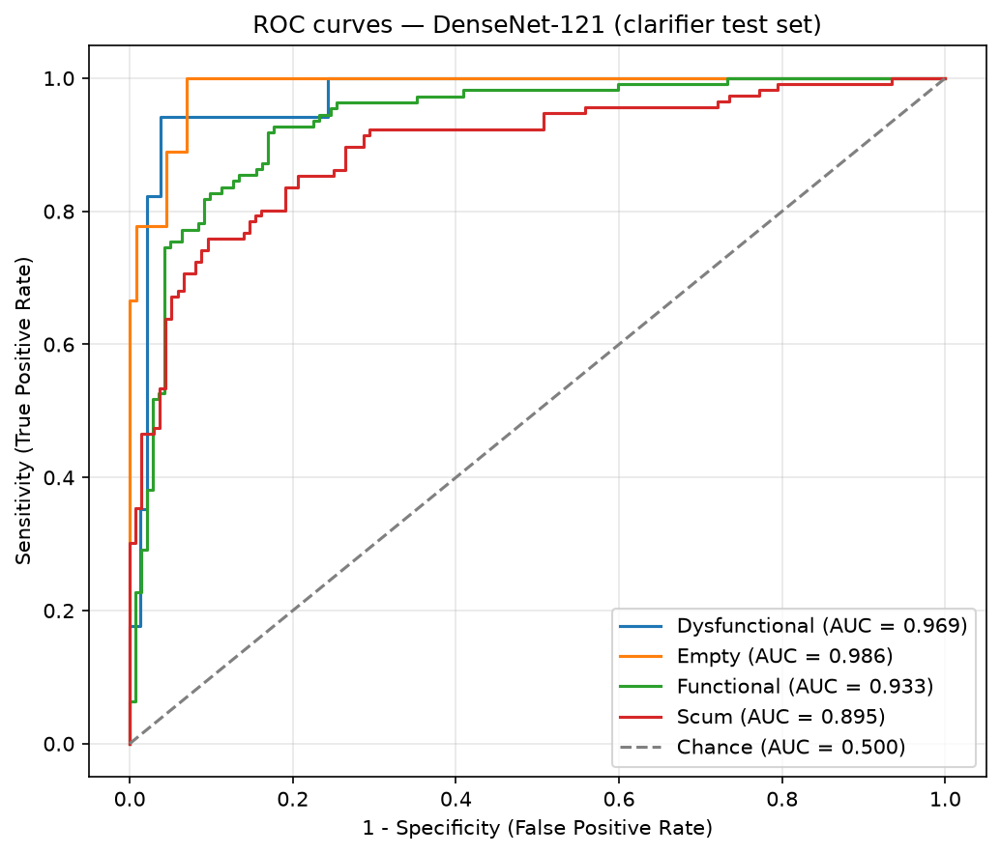

**InceptionNet v3** - test accuracy 0.750, mean AUC 0.930

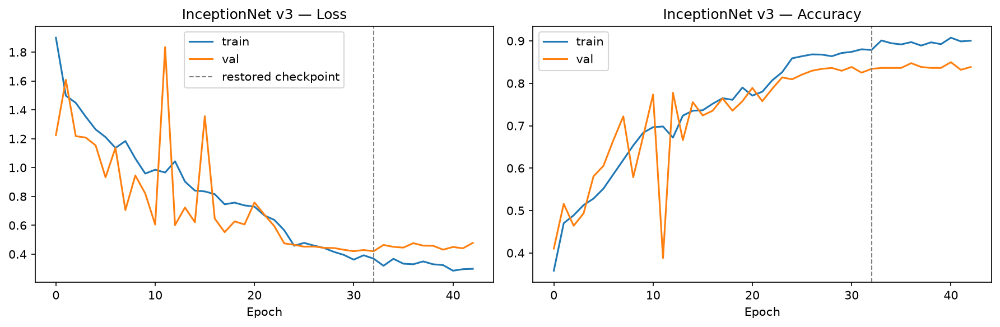

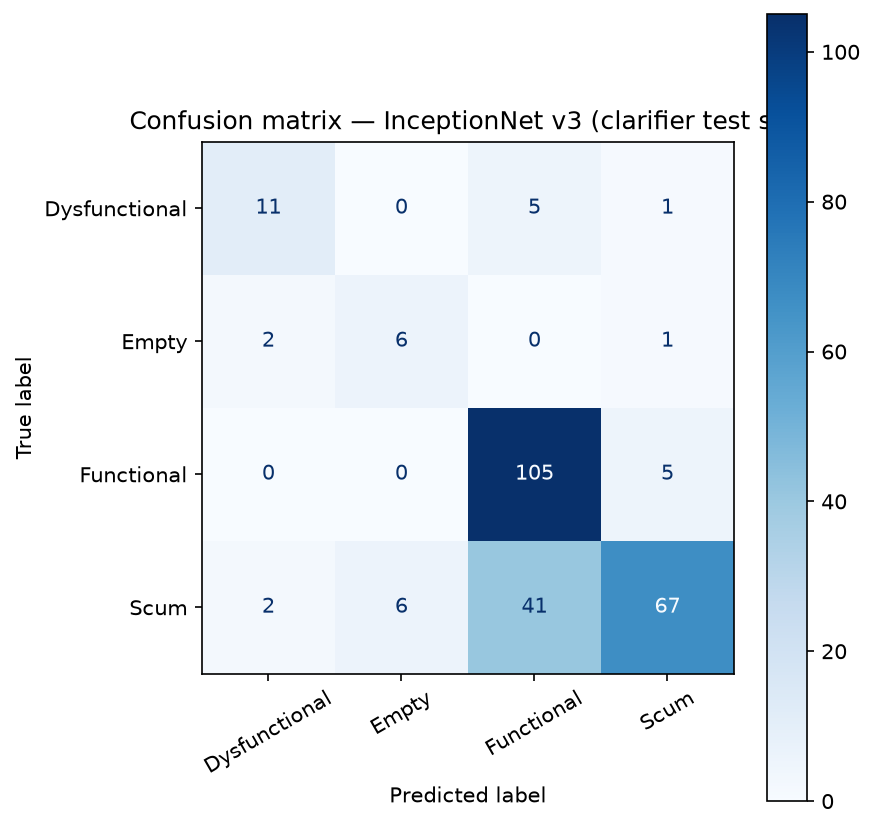

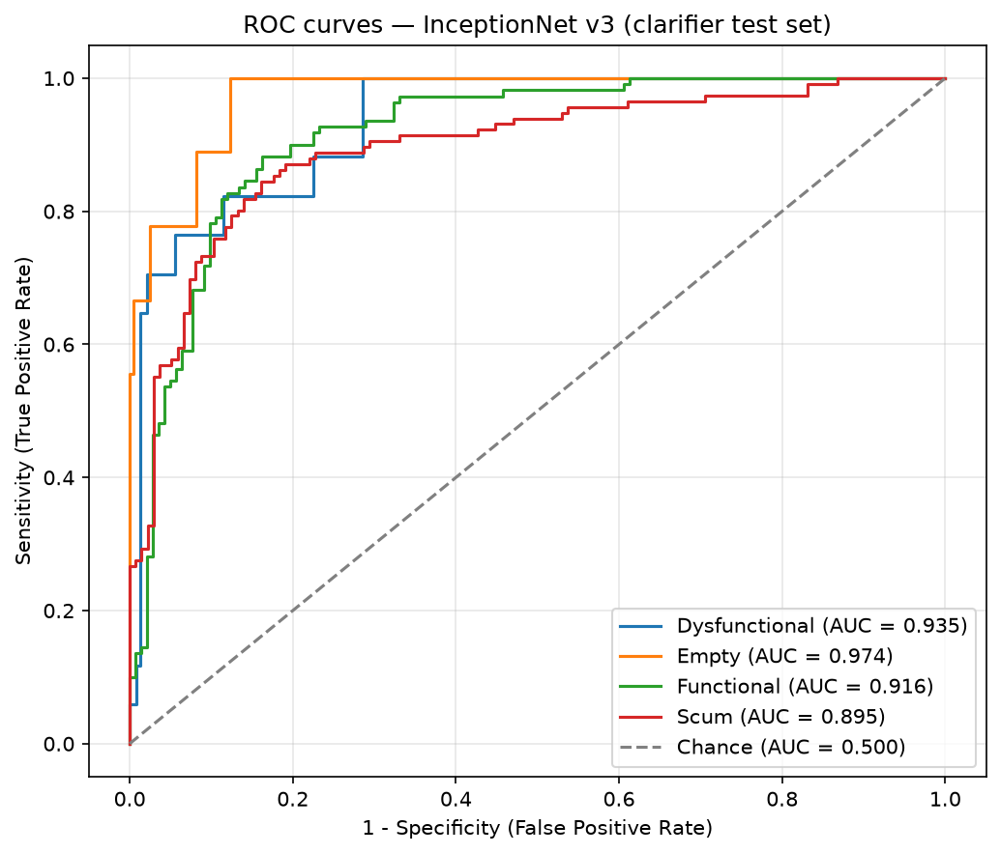

**EfficientNet-B0** - test accuracy 0.746, mean AUC 0.926

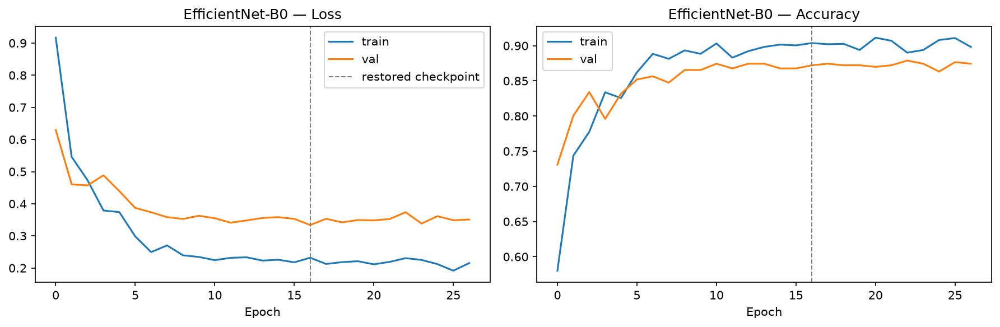

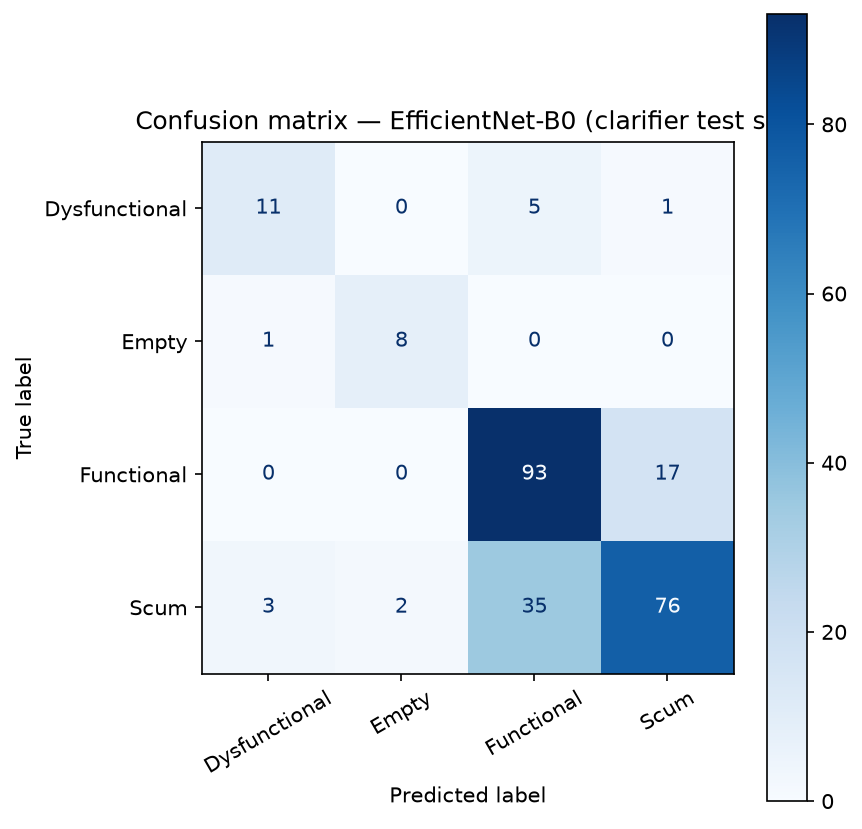

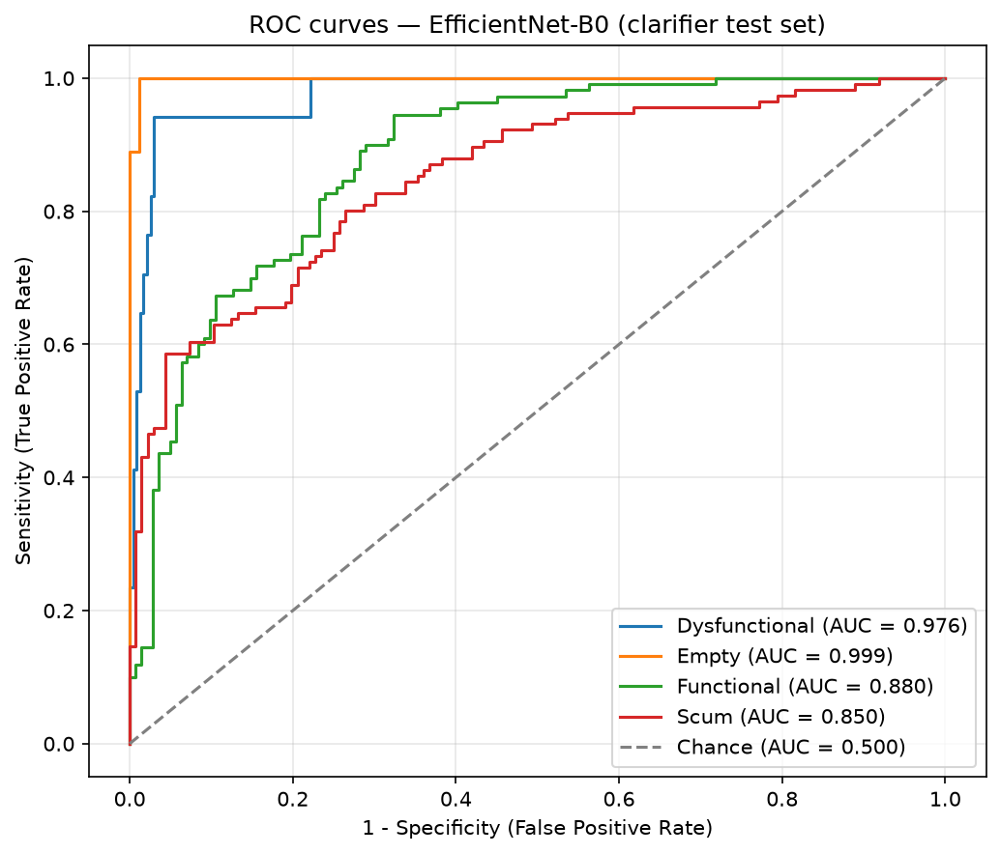

**ConvNeXt-Tiny** - test accuracy 0.798, mean AUC 0.941

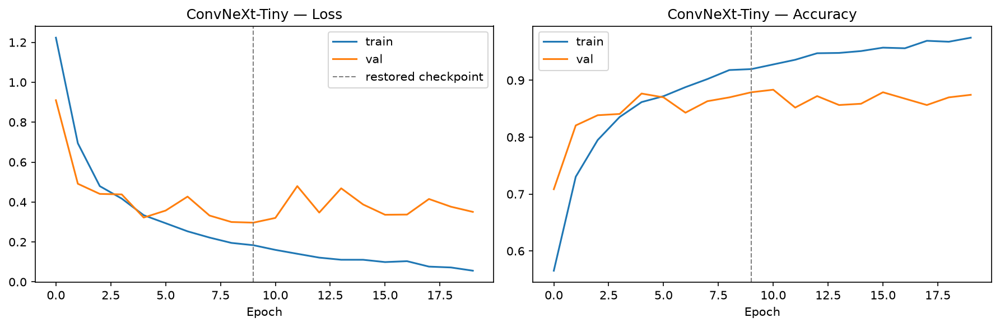

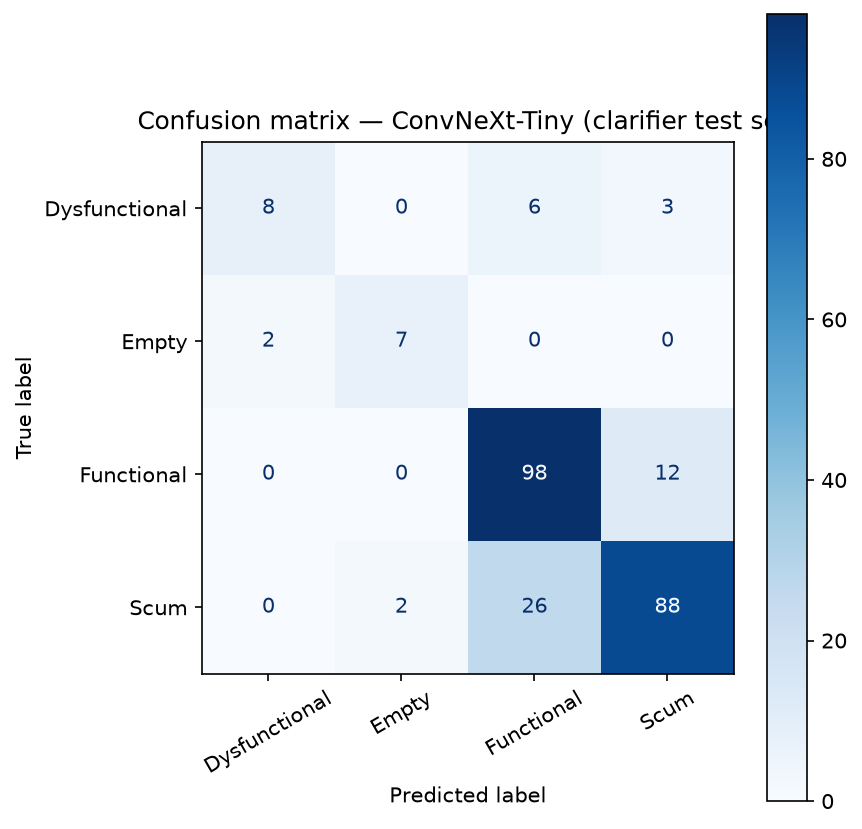

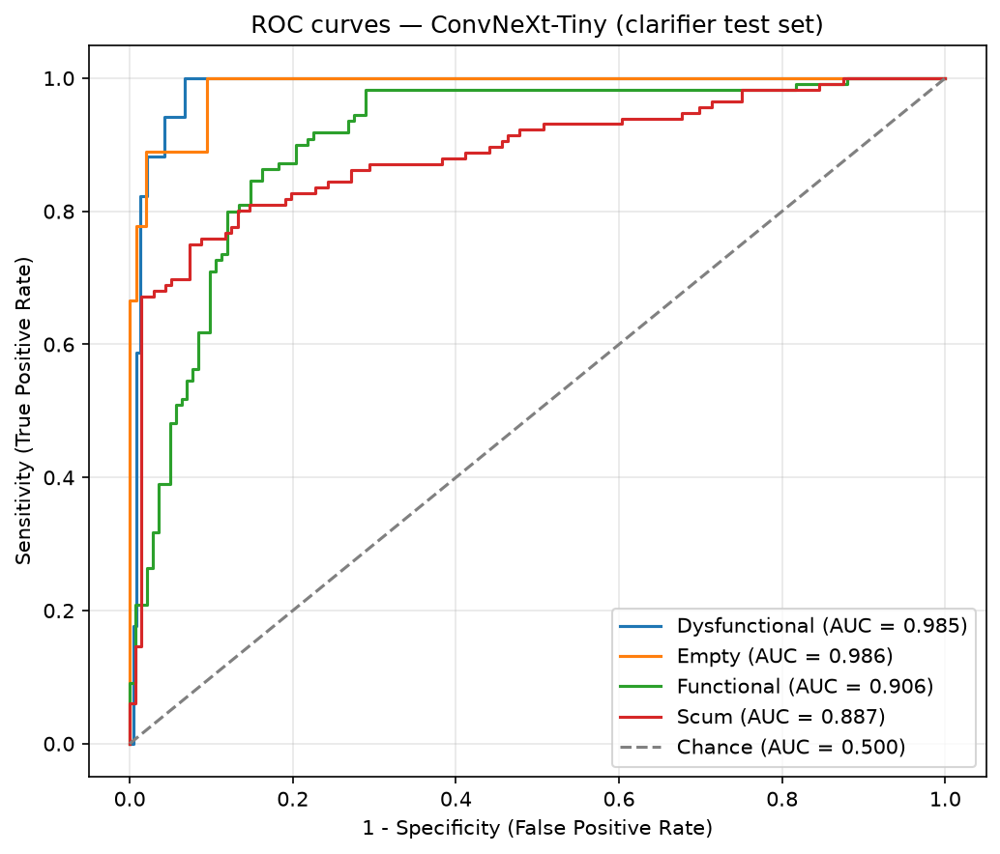

**AlexNet** - test accuracy 0.651, mean AUC 0.857

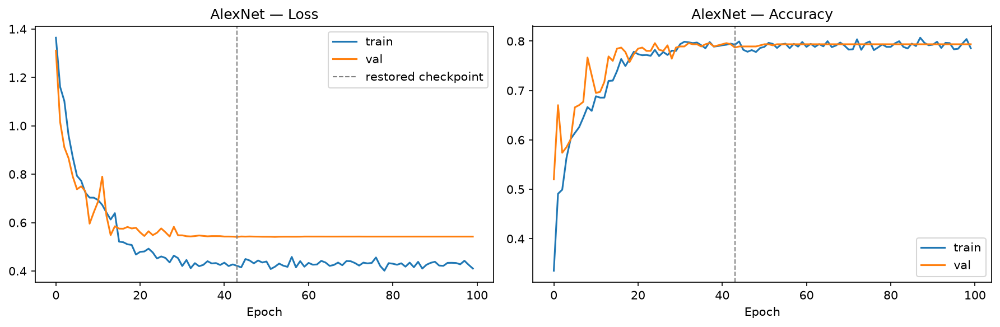

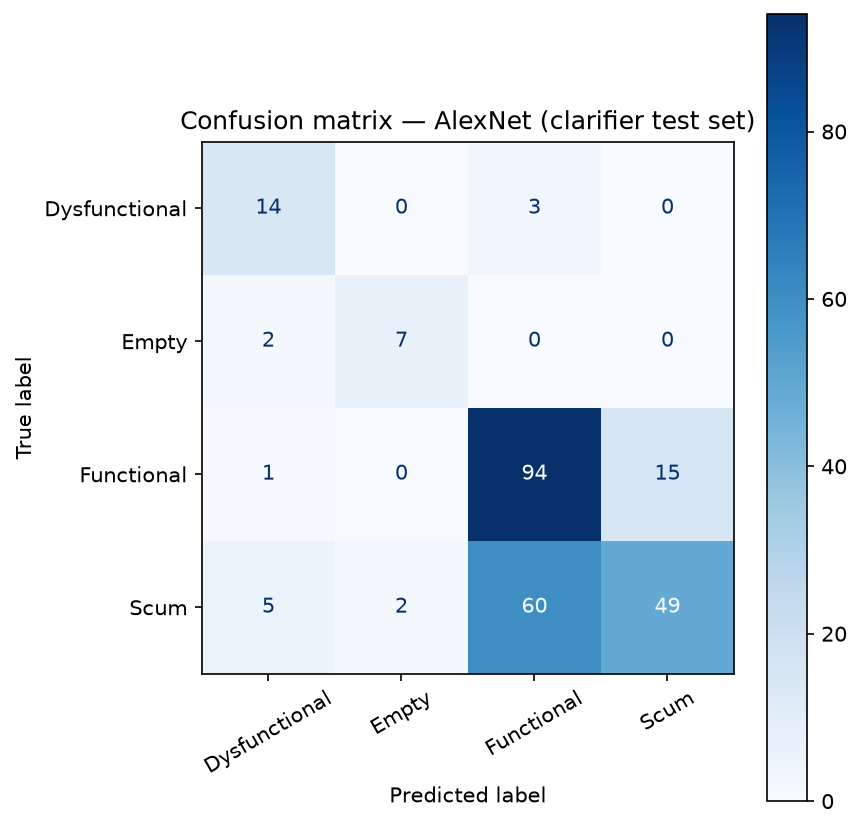

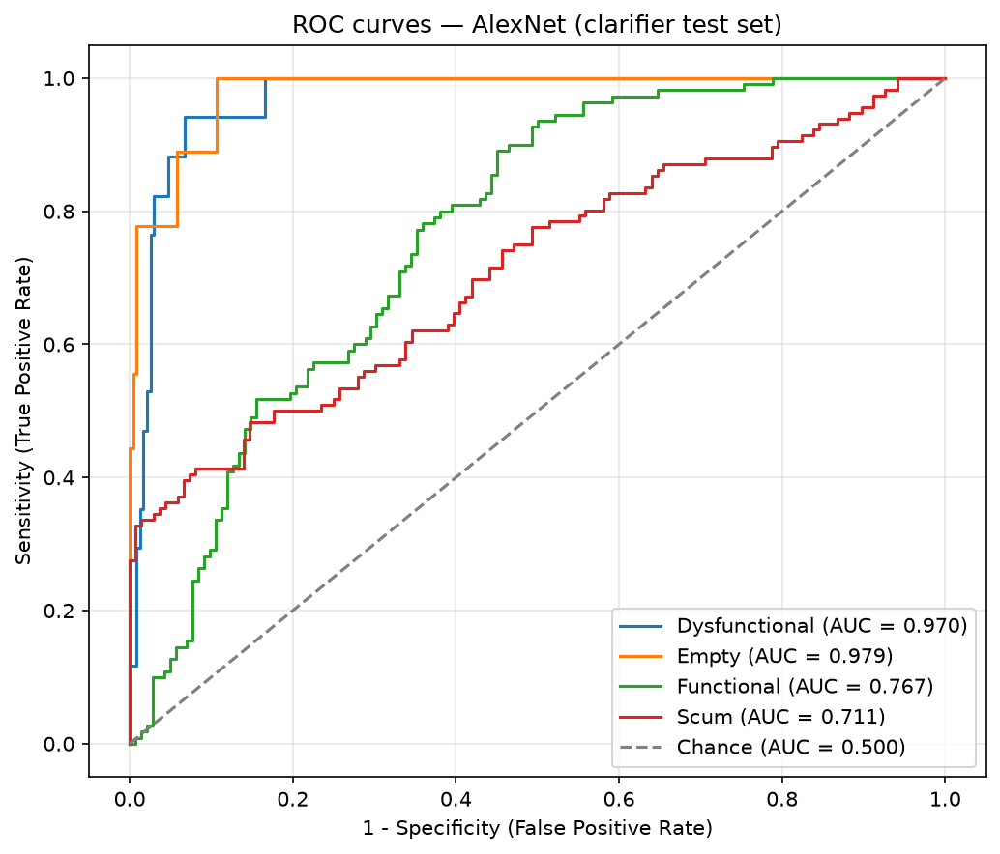

#### NoordelikeWerke (held out)

**ResNet-18** - test accuracy 0.840, mean AUC 0.895

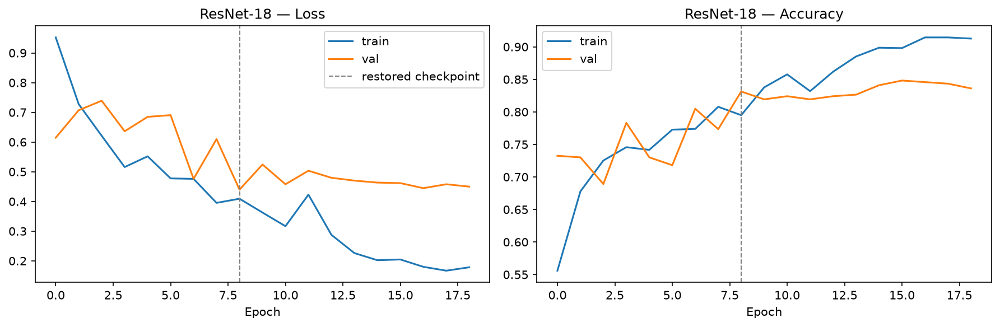

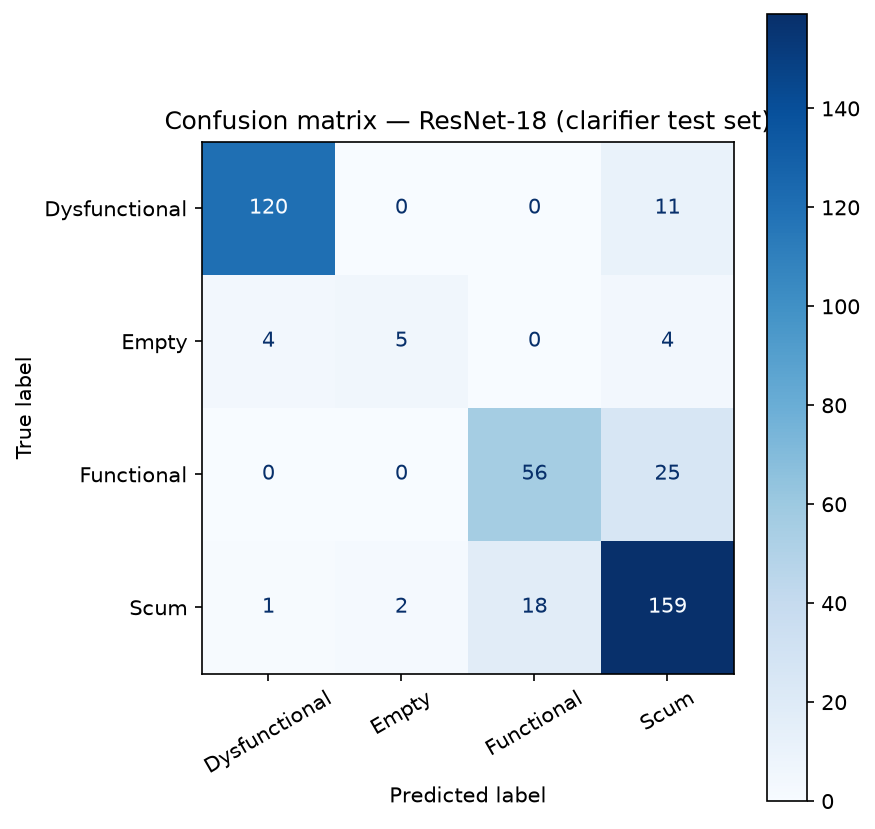

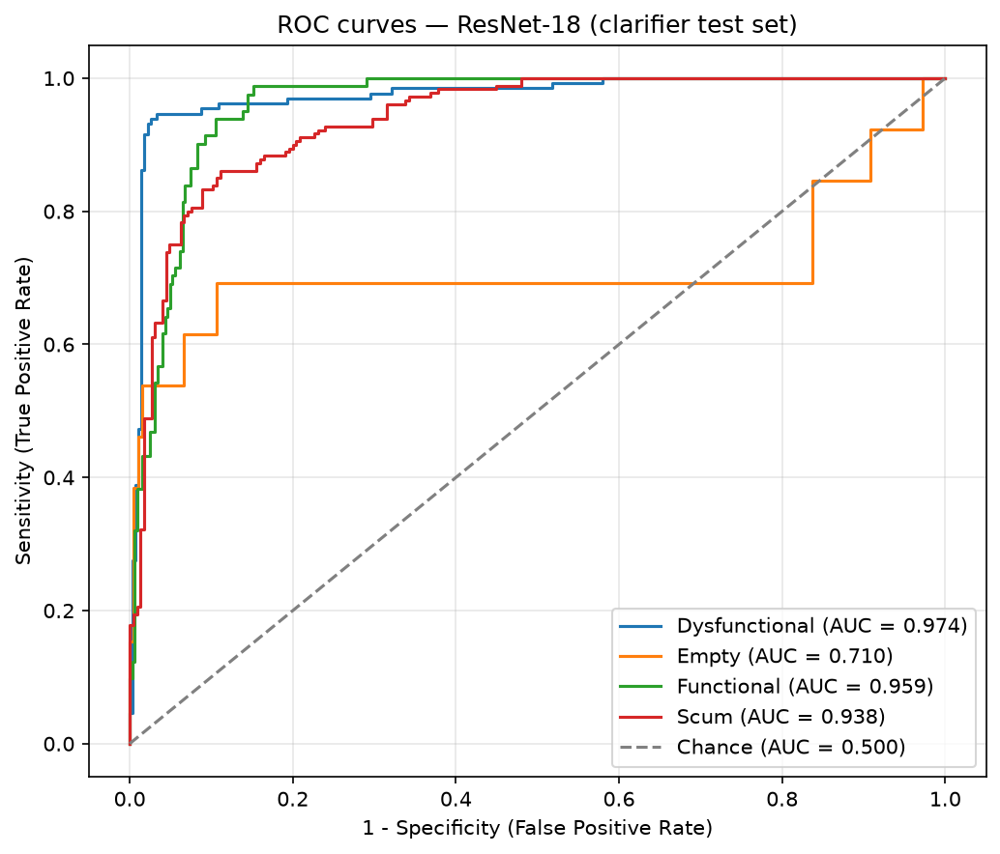

**ResNet-50** - test accuracy 0.874, mean AUC 0.940

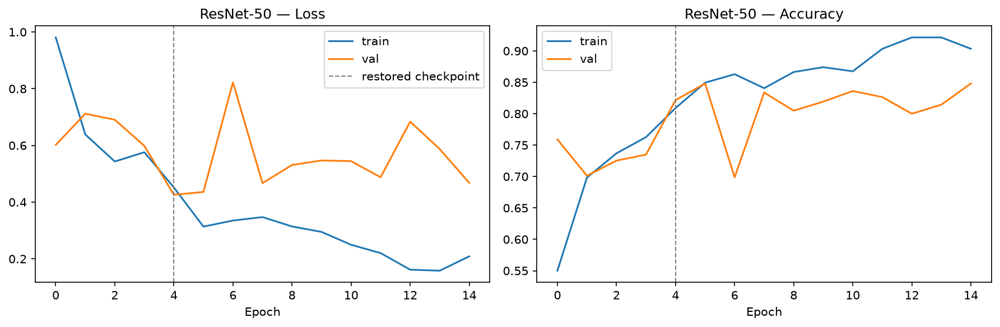

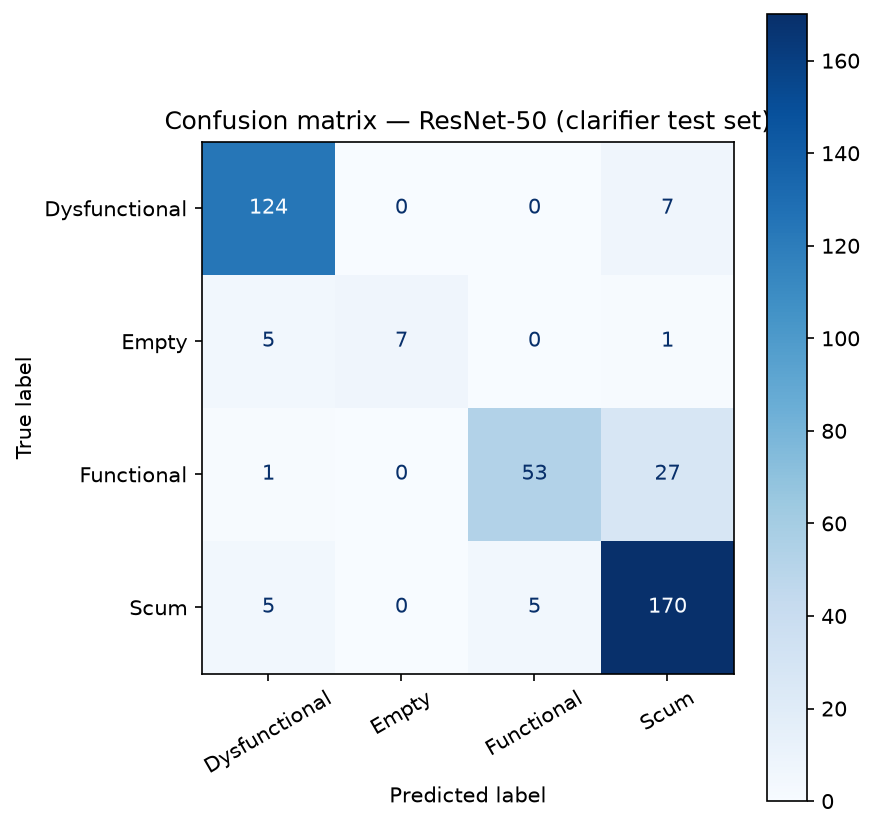

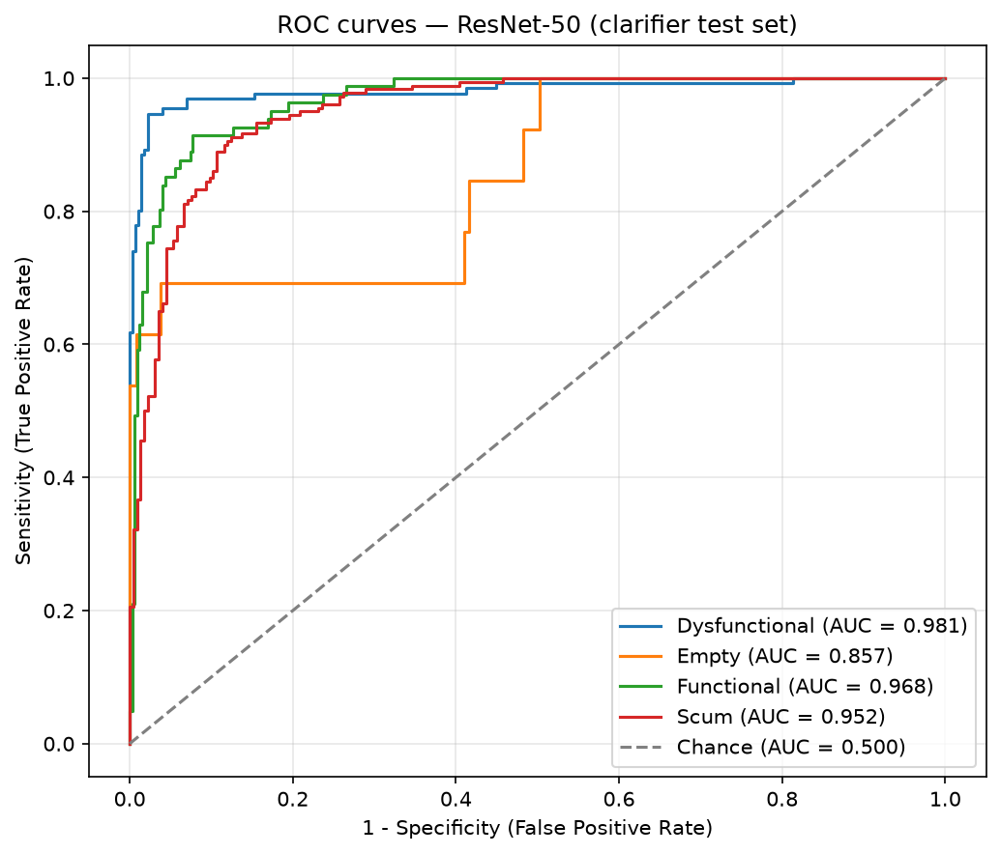

**DenseNet-121** - test accuracy 0.847, mean AUC 0.970

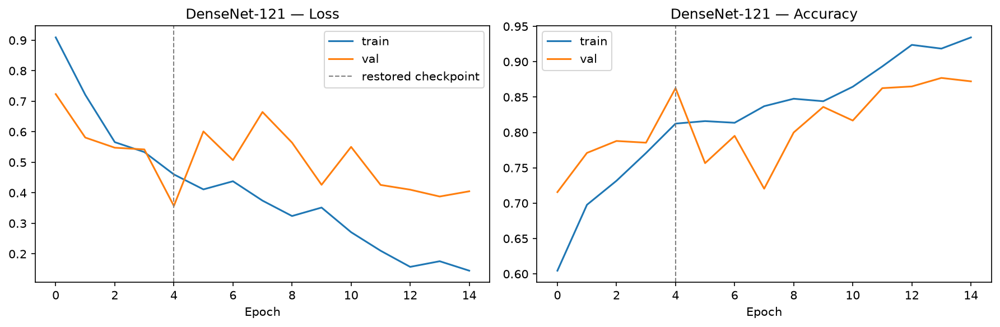

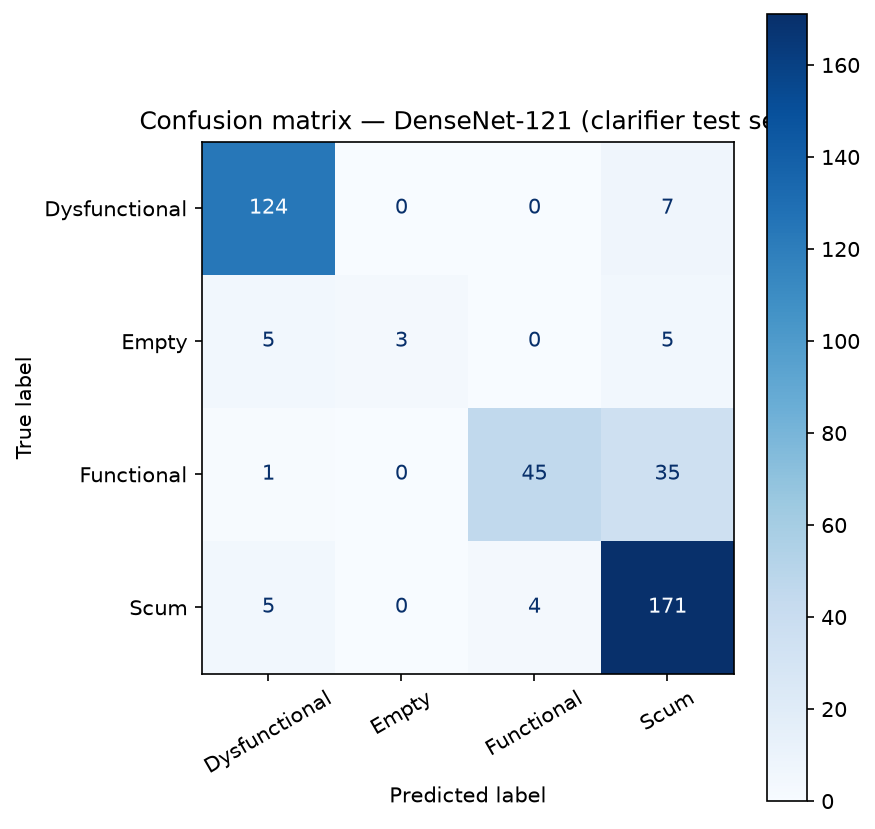

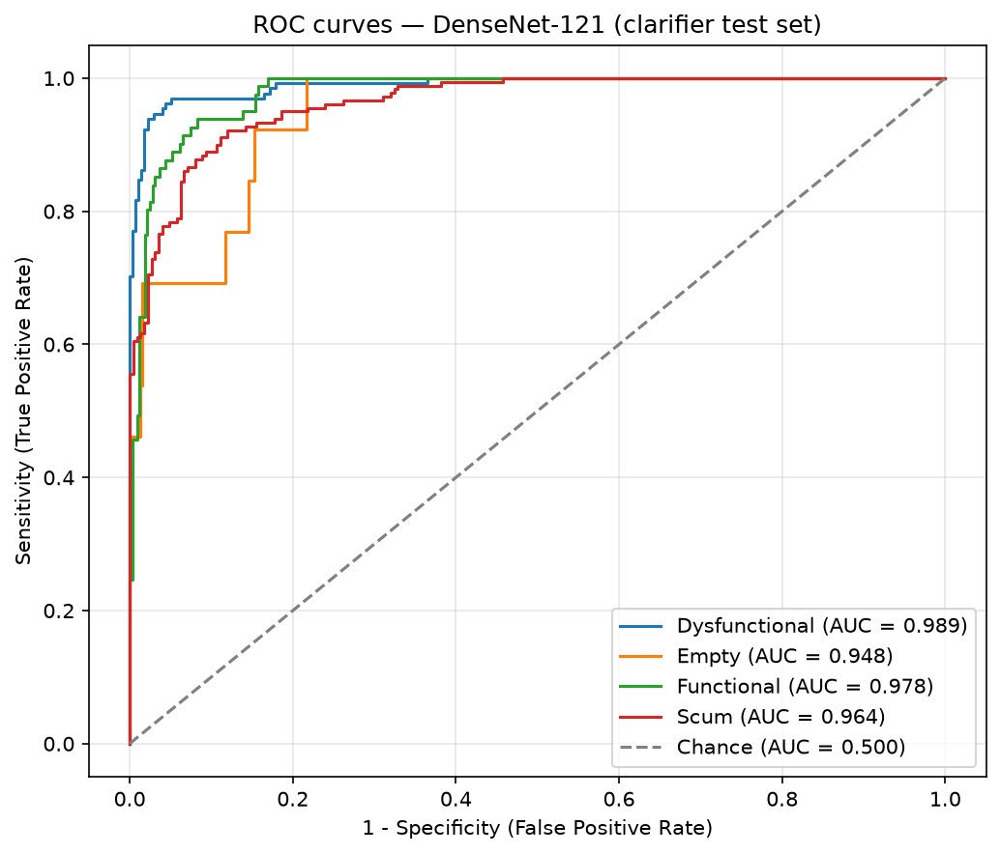

**InceptionNet v3** - test accuracy 0.854, mean AUC 0.884

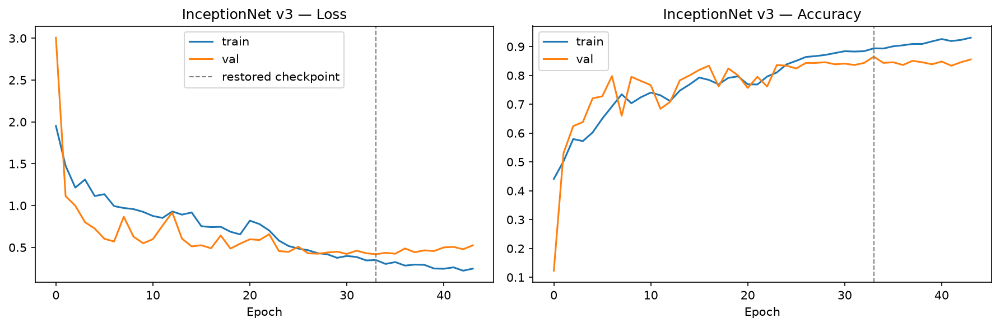

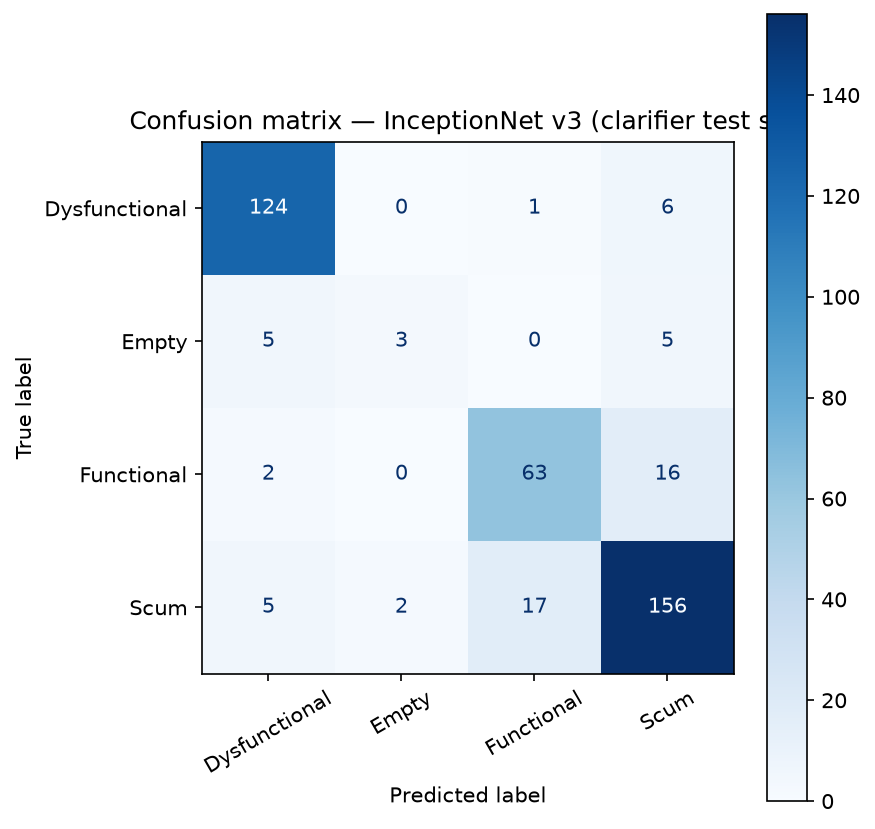

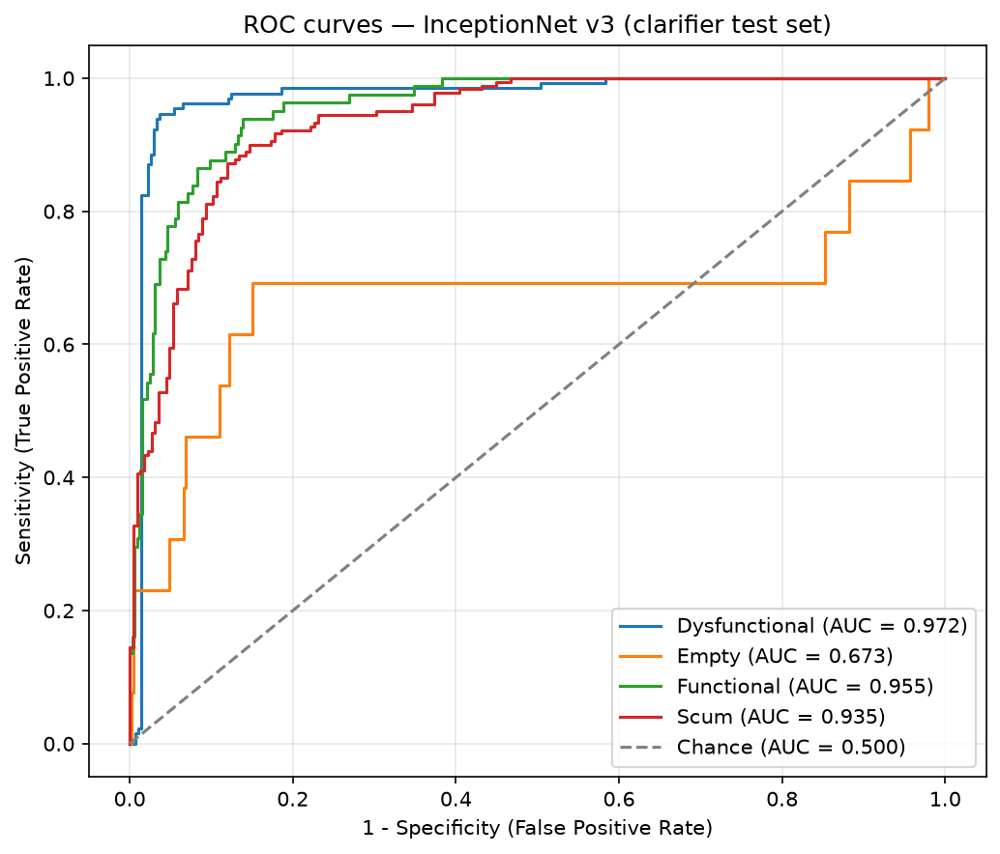

**EfficientNet-B0** - test accuracy 0.864, mean AUC 0.946

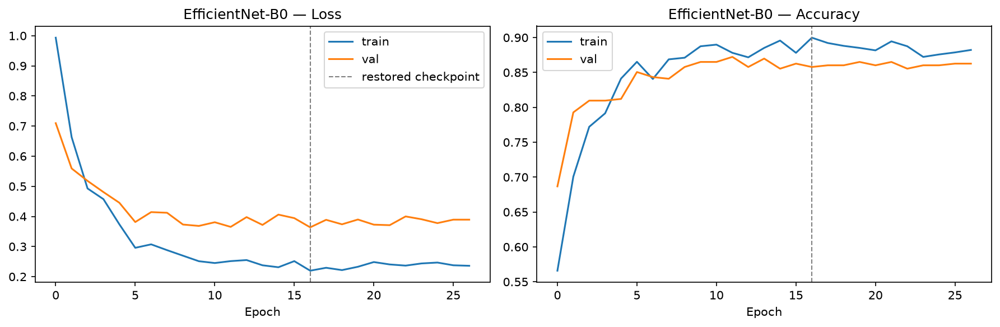

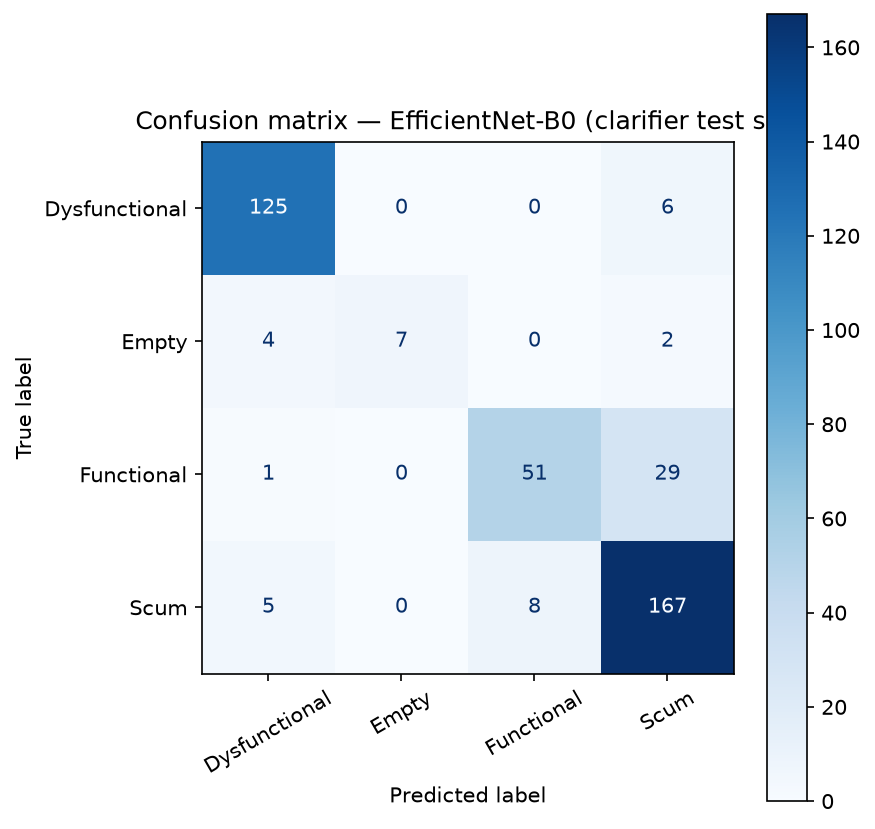

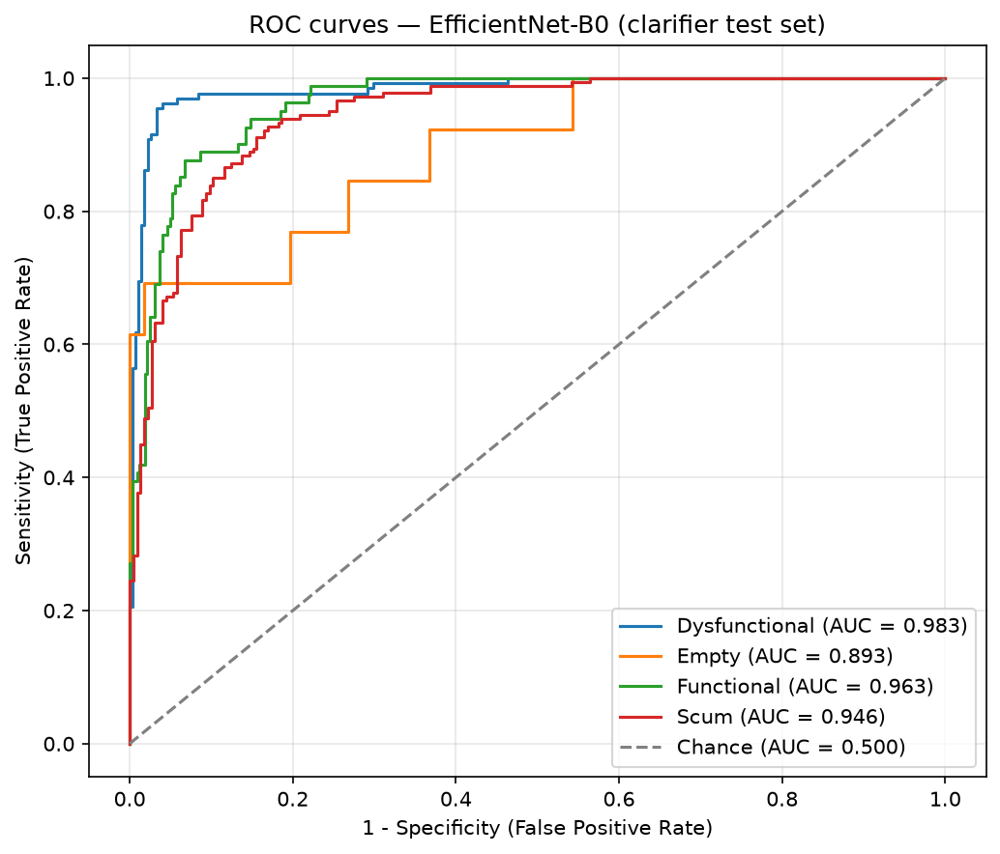

**ConvNeXt-Tiny** - test accuracy 0.901, mean AUC 0.971

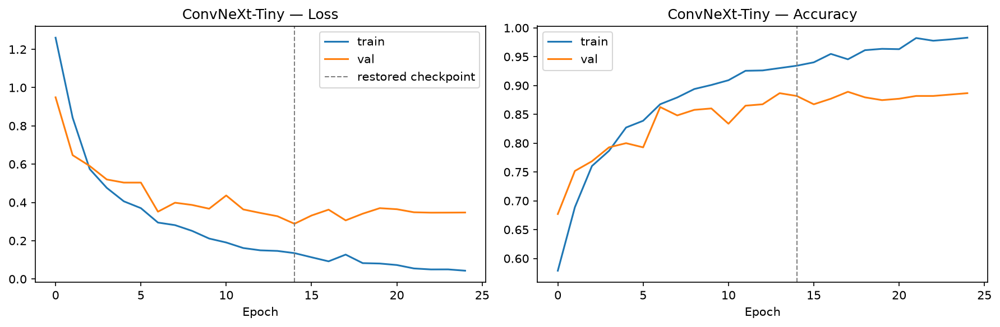

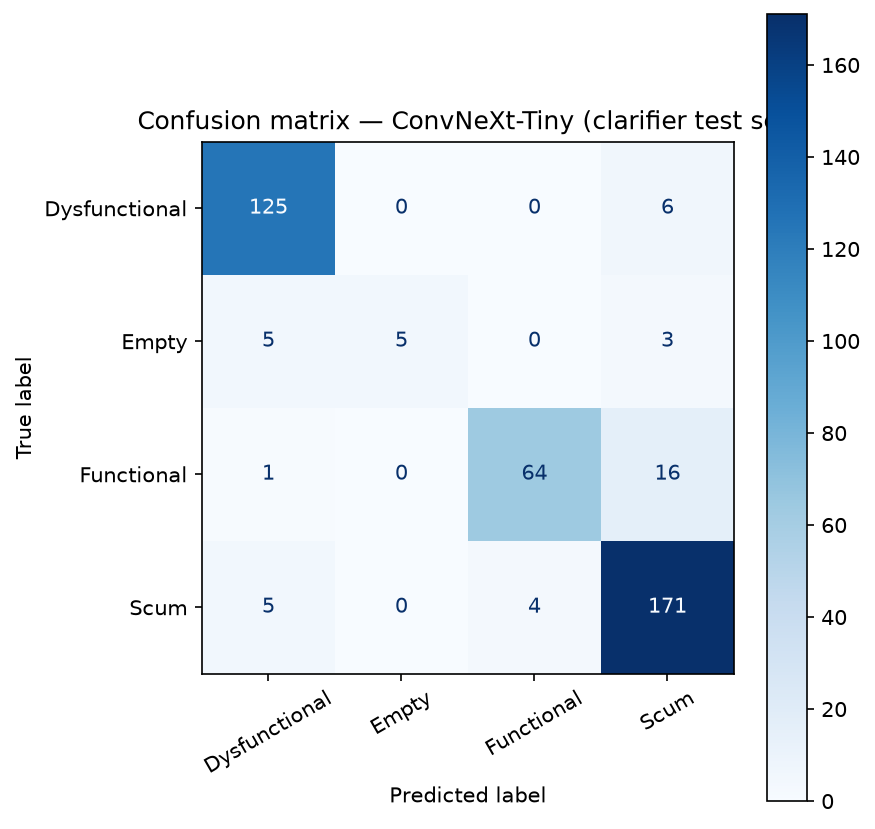

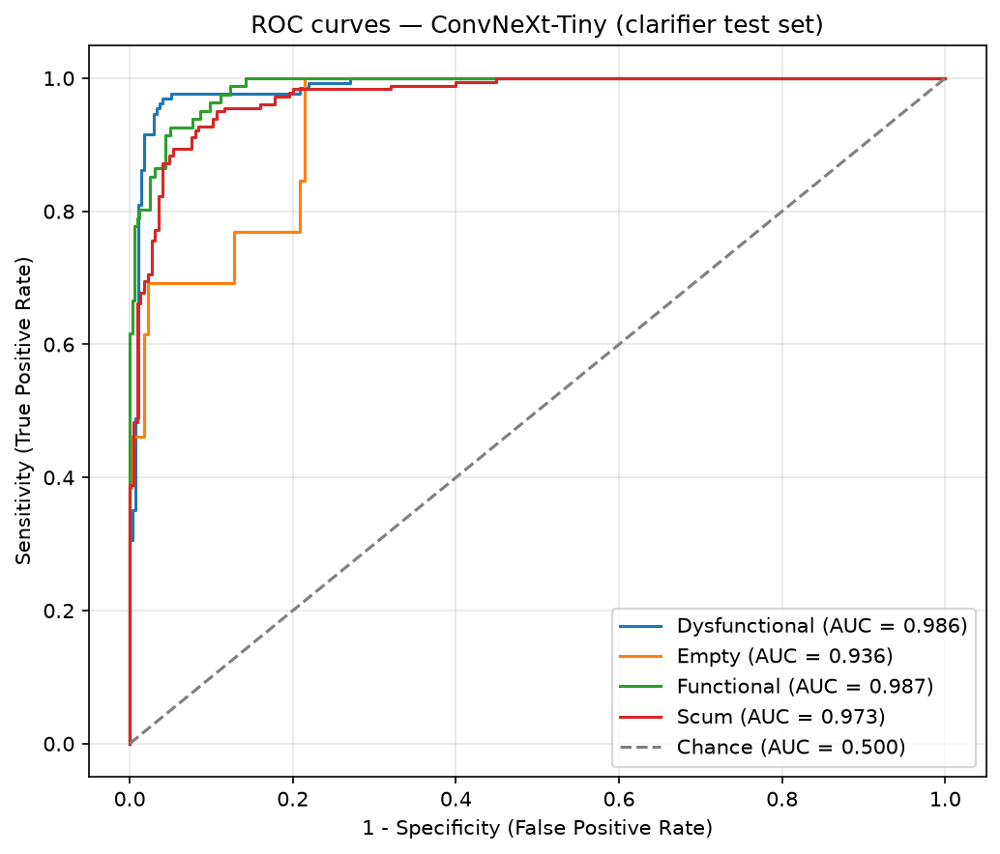

**AlexNet** - test accuracy 0.780, mean AUC 0.923

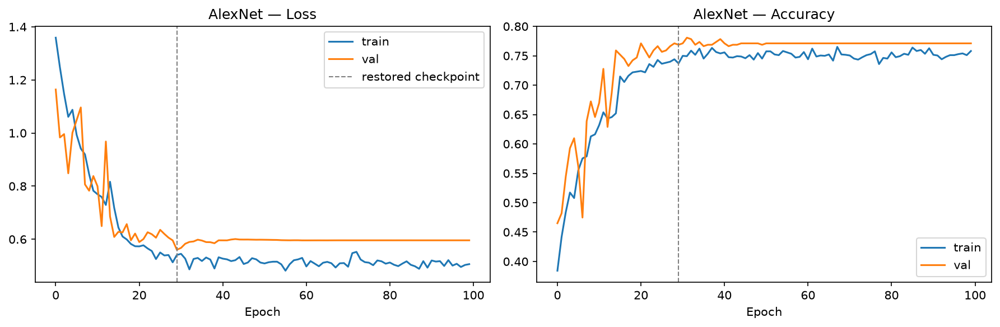

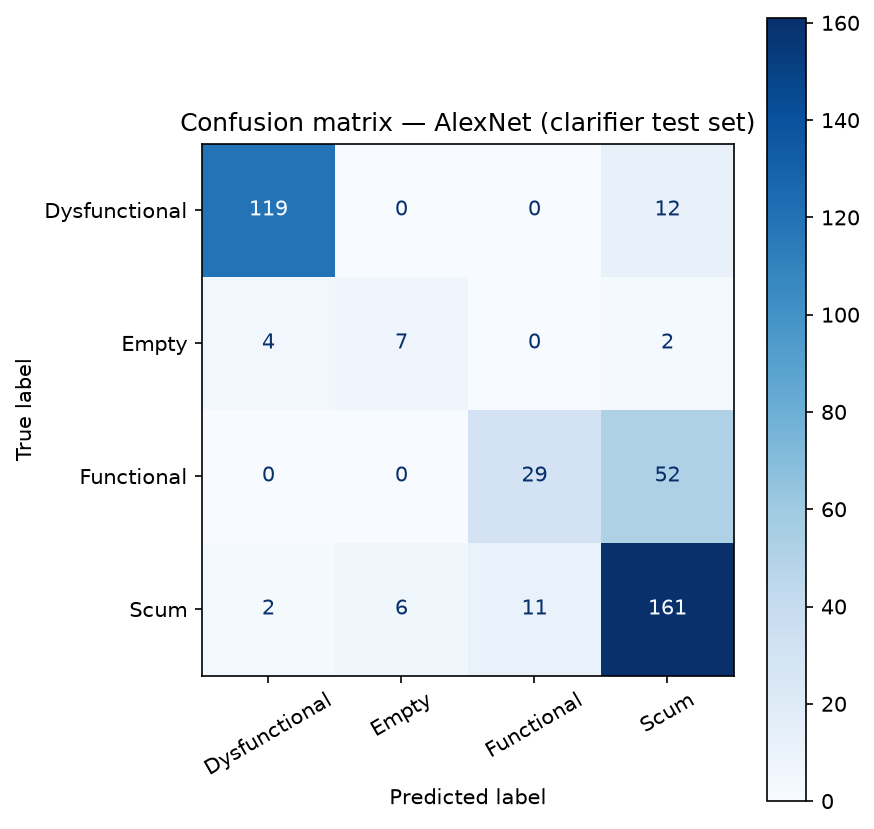

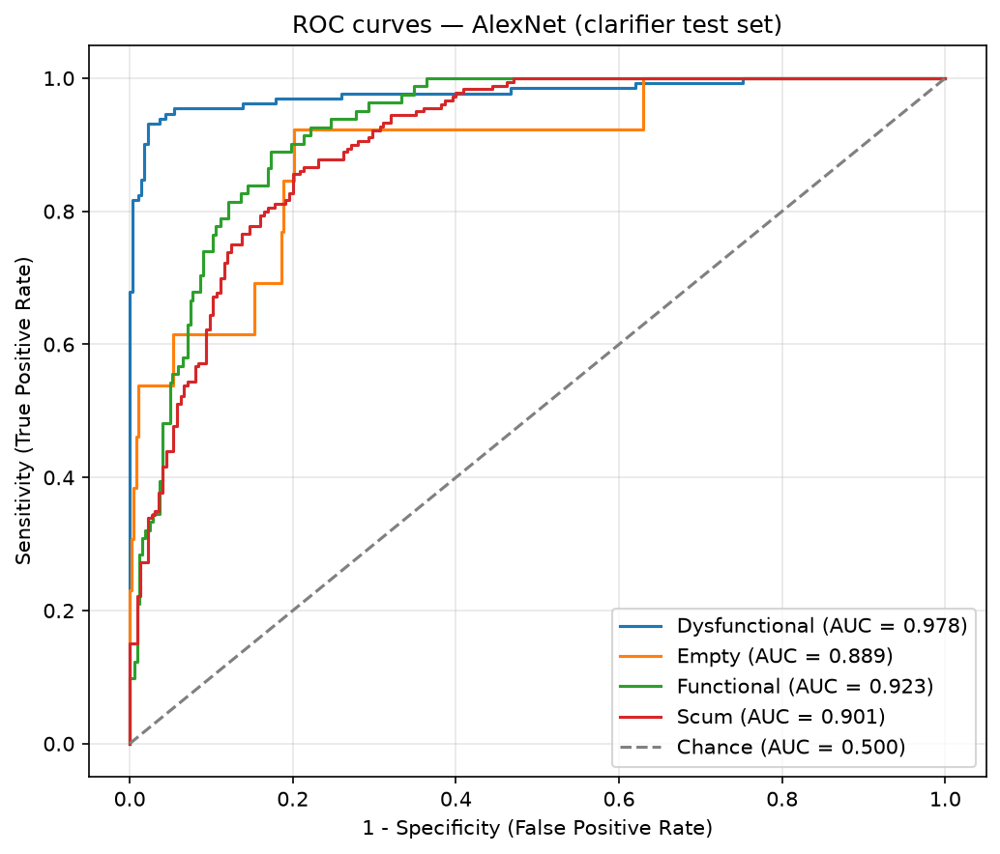

In [13]:
show_figures("aug", "lofo")

## Summary - Augmented training

One row per architecture: stratified results, LOFO mean across held-out facilities, and the OK/not-OK operating point.

In [14]:
SUMMARY_AUG = summary_table("aug")

,stratified accuracy,stratified mean AUC,stratified macro F1,LOFO accuracy mean,LOFO accuracy std,LOFO mean AUC,LOFO macro F1,LOFO folds,stratified OK/not-OK AUC,stratified recall @thr,stratified specificity @thr,lofo OK/not-OK AUC,lofo recall @thr,lofo specificity @thr
ResNet-18,0.854,0.961,0.864,0.764,0.097,0.914,0.656,5.0,0.960,0.954,0.783,0.921,0.951,0.441
ResNet-50,0.836,0.968,0.821,0.800,0.086,0.914,0.677,5.0,0.962,0.954,0.755,0.927,0.953,0.524
DenseNet-121,0.882,0.975,0.880,0.802,0.105,0.940,0.669,5.0,0.977,0.954,0.868,0.941,0.950,0.432
InceptionNet v3,0.868,0.968,0.864,0.787,0.106,0.920,0.639,5.0,0.968,0.954,0.877,0.934,0.952,0.511
EfficientNet-B0,0.864,0.970,0.867,0.804,0.087,0.941,0.686,5.0,0.961,0.954,0.821,0.935,0.951,0.480
ConvNeXt-Tiny,0.889,0.975,0.895,0.822,0.080,0.956,0.694,5.0,0.975,0.954,0.877,0.953,0.950,0.528
AlexNet,0.761,0.924,0.790,0.687,0.104,0.863,0.595,5.0,0.910,0.954,0.509,0.844,0.953,0.190


Saved to ../results/clarifier_aug/summary_clarifier_aug.csv


# No augmentation

## Stratified 70/20/10 - No augmentation

### Comparison table

Macro-averaged precision/recall/F1 (every class counts equally).

In [15]:
show_comparison("noaug", "stratified")

test_accuracy  mean_auc  macro_precision  \
test set   model                                                       
stratified ResNet-18                0.850     0.955            0.910   
           ResNet-50                0.786     0.944            0.790   
           DenseNet-121             0.843     0.958            0.811   
           InceptionNet v3          0.825     0.952            0.850   
           EfficientNet-B0          0.843     0.962            0.863   
           ConvNeXt-Tiny            0.886     0.975            0.877   
           AlexNet                  0.750     0.916            0.761   

                            macro_recall  macro_f1  n_test_images  
test set   model                                                   
stratified ResNet-18               0.850     0.875            280  
           ResNet-50               0.807     0.790            280  
           DenseNet-121            0.830     0.818            280  
           InceptionNet v3         0.816     0.828            280  
           EfficientNet-B0         0.850     0.856            280  
           ConvNeXt-Tiny           0.883     0.875            280  
           AlexNet                 0.769     0.761            280

### Accuracy and AUC

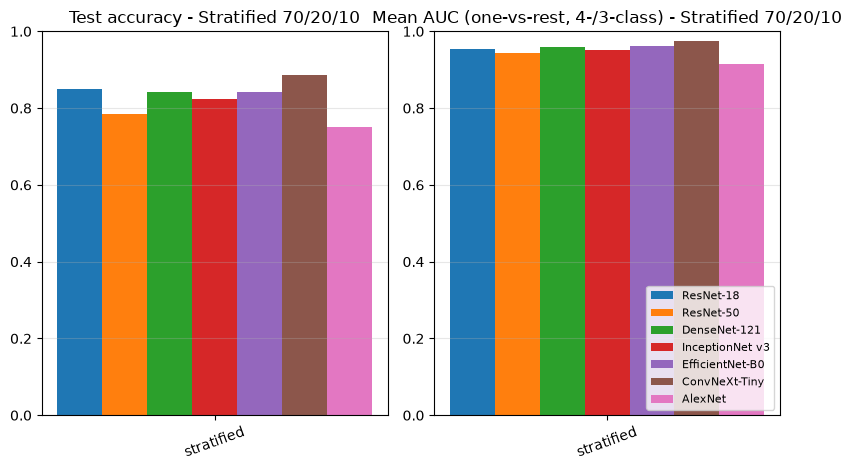

In [16]:
plot_bars("noaug", "stratified")

### Per-class precision / recall / F1

In [17]:
show_per_class("noaug", "stratified")

**stratified - ResNet-18**

,precision,recall,f1-score,support
Dysfunctional,1.000,0.892,0.943,37.0
Empty,1.000,0.810,0.895,21.0
Functional,0.784,0.925,0.848,106.0
Scum,0.857,0.776,0.814,116.0


**stratified - ResNet-50**

,precision,recall,f1-score,support
Dysfunctional,0.909,0.811,0.857,37.0
Empty,0.667,0.857,0.750,21.0
Functional,0.736,0.896,0.809,106.0
Scum,0.846,0.664,0.744,116.0


**stratified - DenseNet-121**

...

,precision,recall,f1-score,support
Dysfunctional,0.941,0.865,0.901,37.0
Empty,0.857,0.857,0.857,21.0
Functional,0.826,0.849,0.837,106.0
Scum,0.828,0.828,0.828,116.0


**stratified - ConvNeXt-Tiny**

,precision,recall,f1-score,support
Dysfunctional,1.000,0.838,0.912,37.0
Empty,0.731,0.905,0.809,21.0
Functional,0.863,0.953,0.906,106.0
Scum,0.915,0.836,0.874,116.0


**stratified - AlexNet**

,precision,recall,f1-score,support
Dysfunctional,0.805,0.892,0.846,37.0
Empty,0.750,0.714,0.732,21.0
Functional,0.710,0.830,0.765,106.0
Scum,0.779,0.638,0.701,116.0


### OK vs not-OK: ROC and a recall-driven threshold

Collapses the problem to **OK** (`Functional`) vs **not OK** (all other classes), scored by
`P(not OK) = 1 - P(Functional)`. What matters operationally is catching a component that is
no longer working properly, even at the cost of some false alarms, so the operating point is
chosen for a target recall rather than the default argmax rule. One test set, so this is a single ROC and the threshold is the most permissive one that reaches the target recall on it.

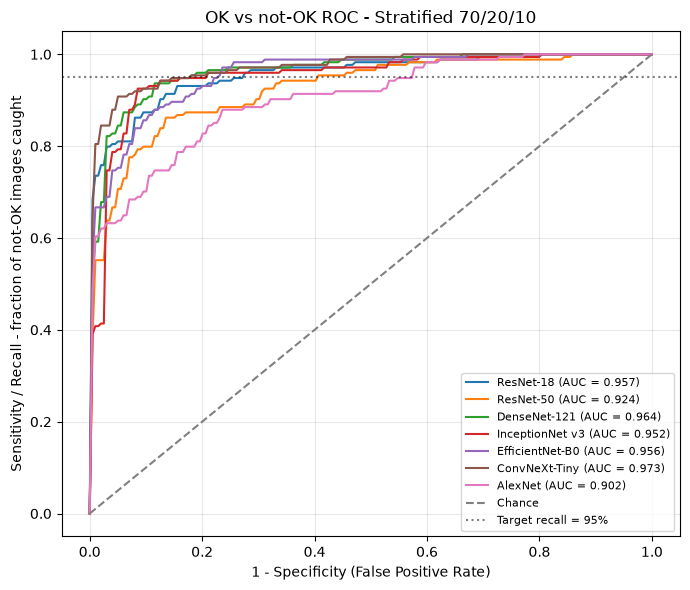

**Operating point per model** - most permissive threshold reaching 95% recall:

,OK/not-OK AUC,threshold on P(not OK),recall (sensitivity),specificity,precision,n_test_sets
model,,,,,,
ResNet-18,0.957,0.114,0.954,0.726,0.851,1
ResNet-50,0.924,0.096,0.954,0.594,0.794,1
DenseNet-121,0.964,0.549,0.954,0.821,0.897,1
InceptionNet v3,0.952,0.218,0.954,0.792,0.883,1
EfficientNet-B0,0.956,0.190,0.954,0.774,0.874,1
ConvNeXt-Tiny,0.973,0.246,0.954,0.821,0.897,1
AlexNet,0.902,0.230,0.960,0.425,0.732,1


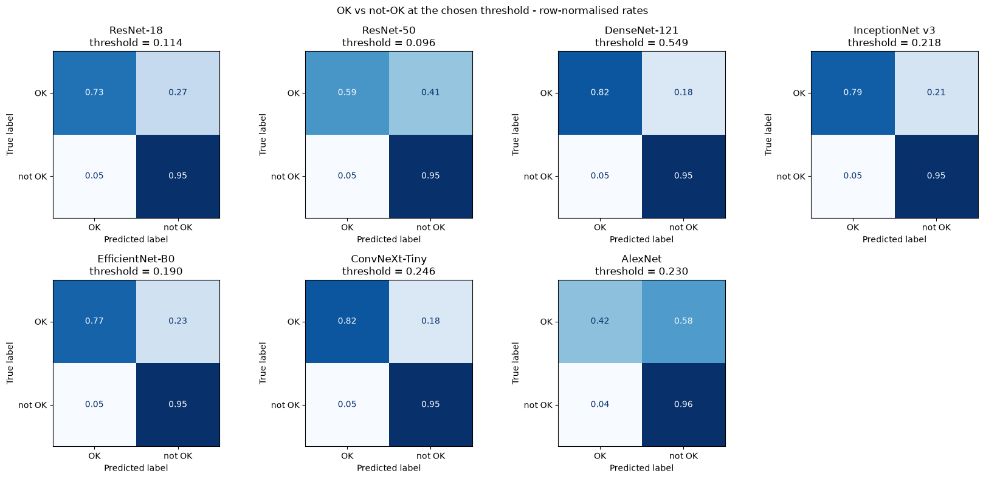

In [18]:
binary_analysis("noaug", "stratified")

### Training curves, confusion matrices and ROC curves per run

#### Stratified test set

**ResNet-18** - test accuracy 0.850, mean AUC 0.955

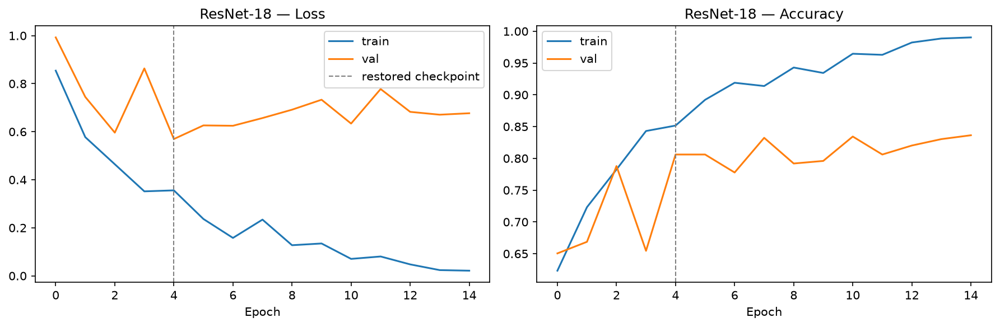

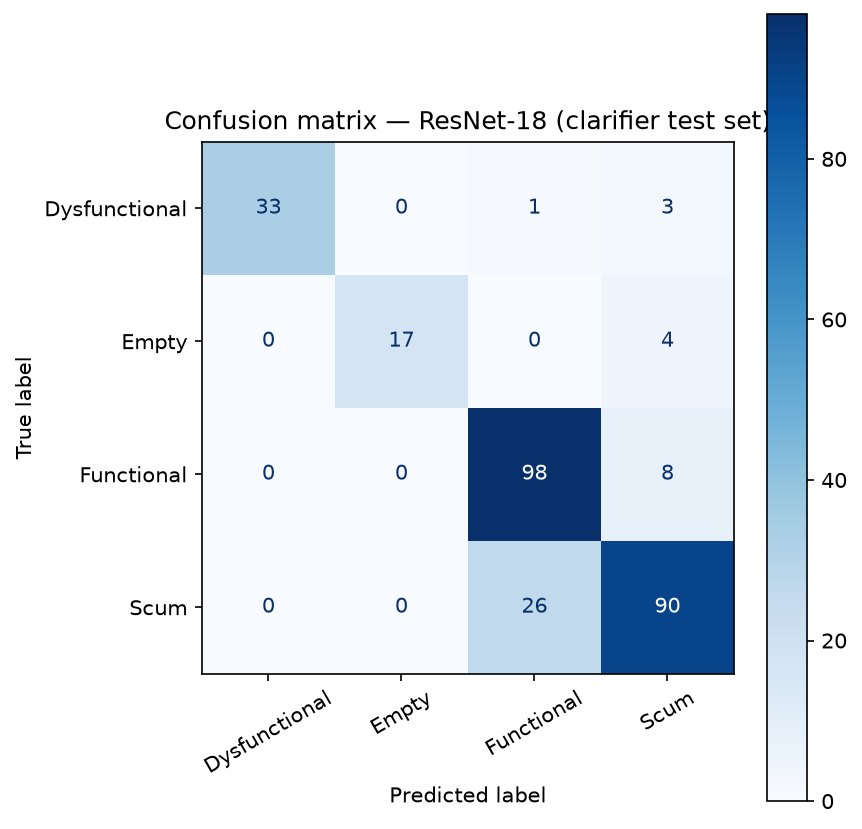

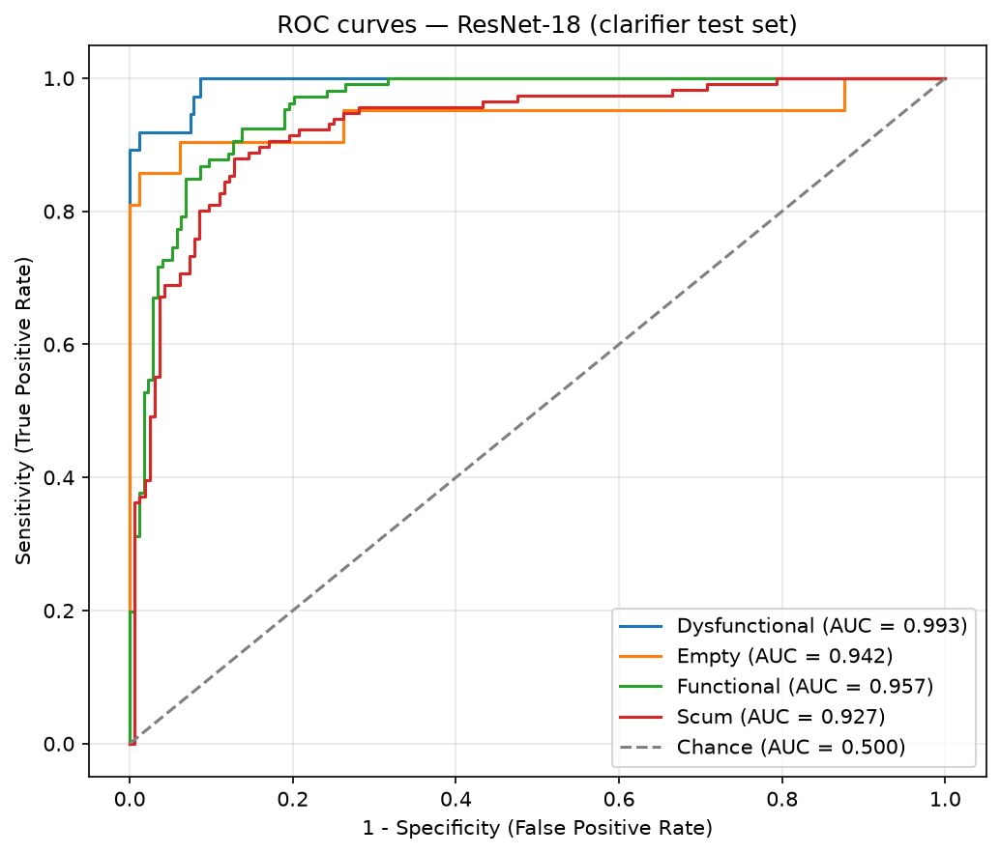

**ResNet-50** - test accuracy 0.786, mean AUC 0.944

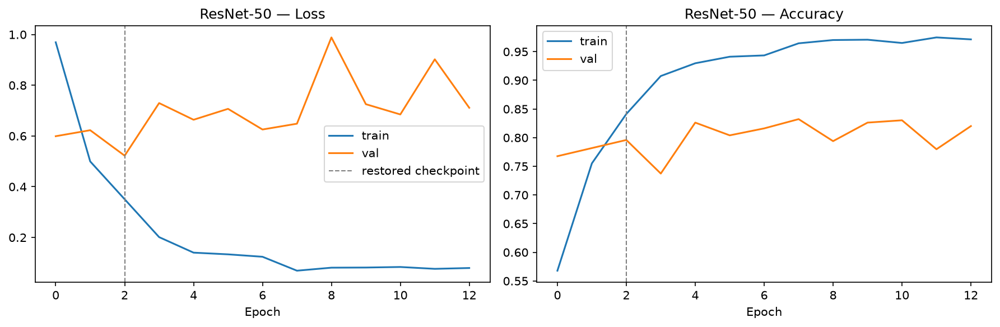

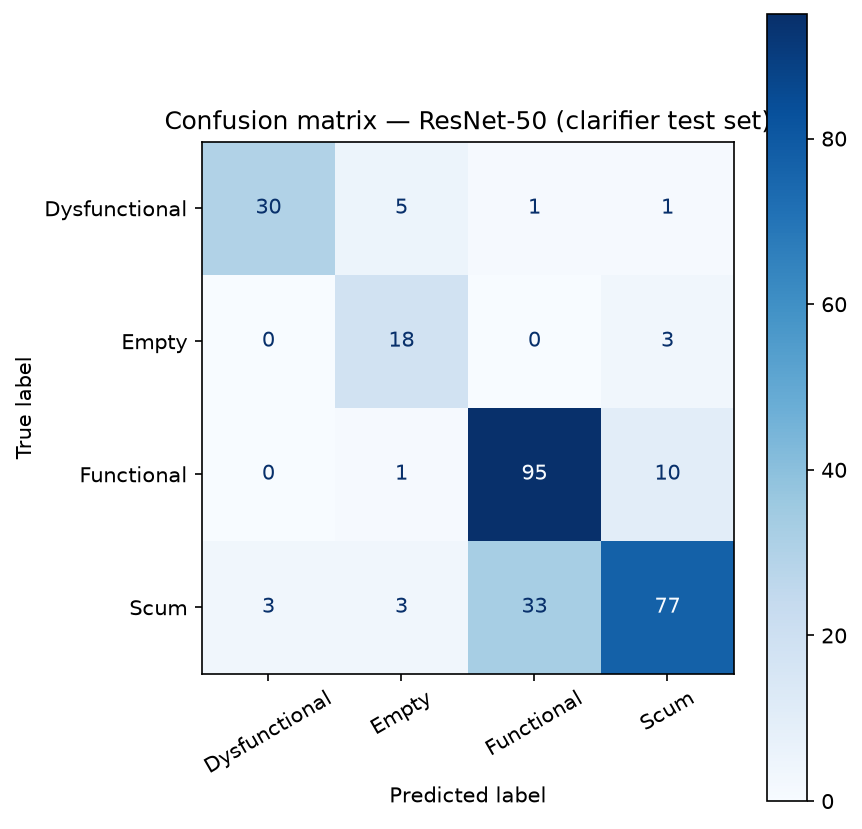

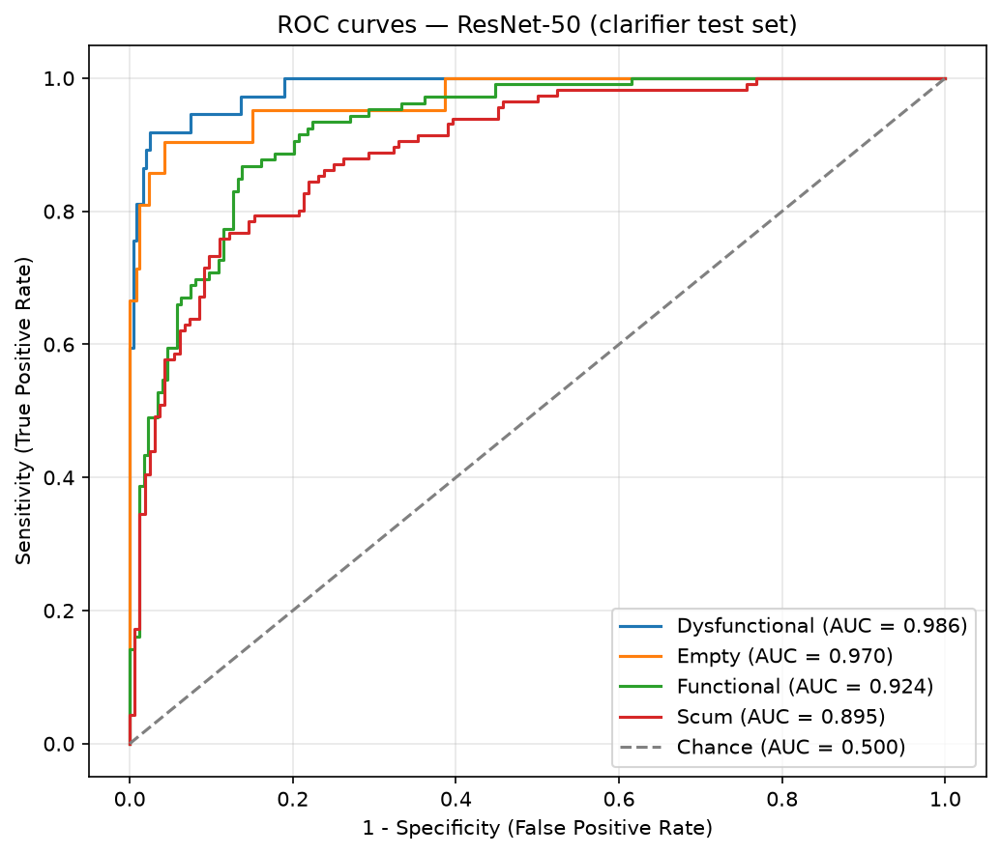

**DenseNet-121** - test accuracy 0.843, mean AUC 0.958

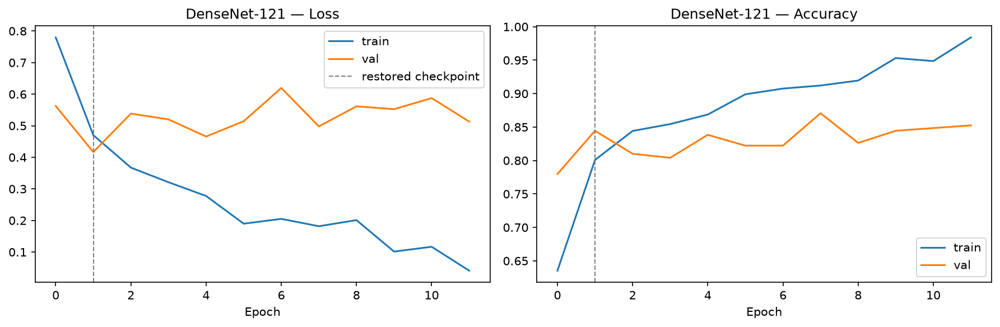

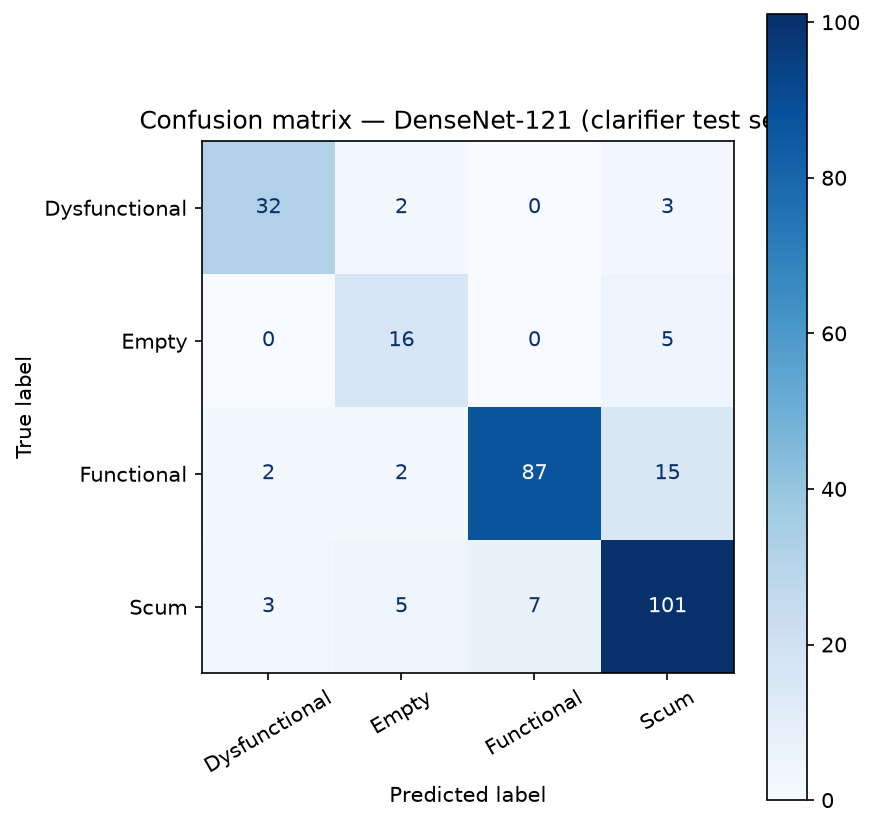

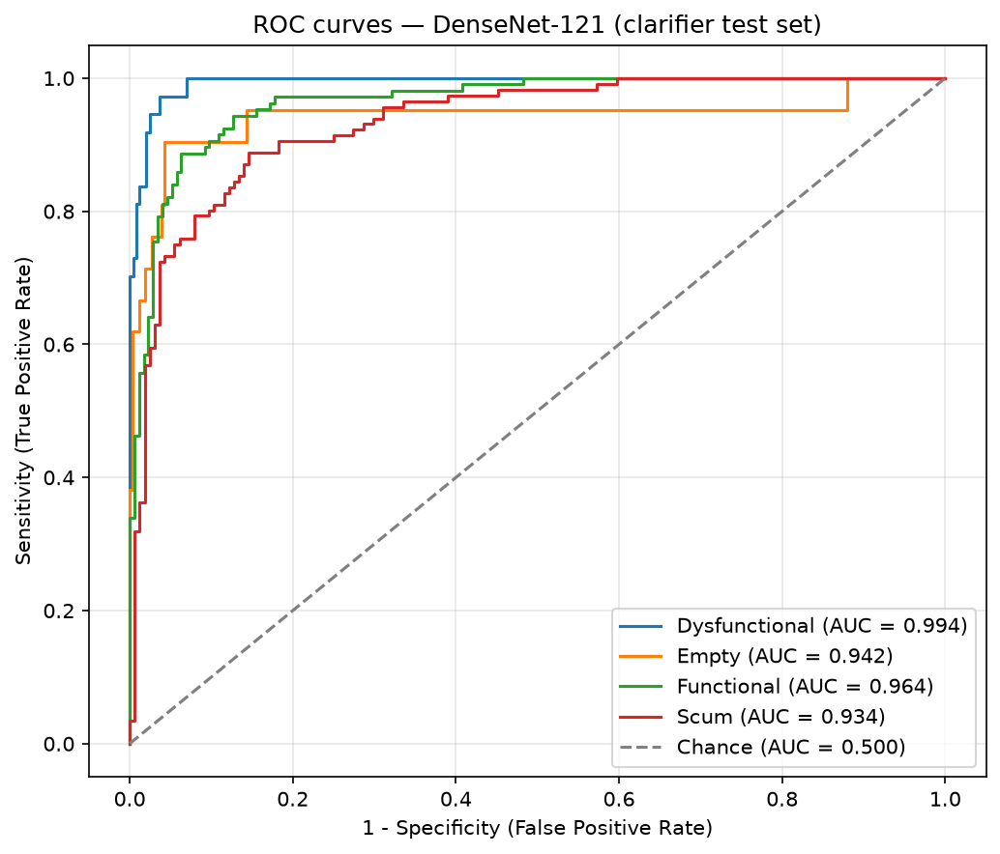

**InceptionNet v3** - test accuracy 0.825, mean AUC 0.952

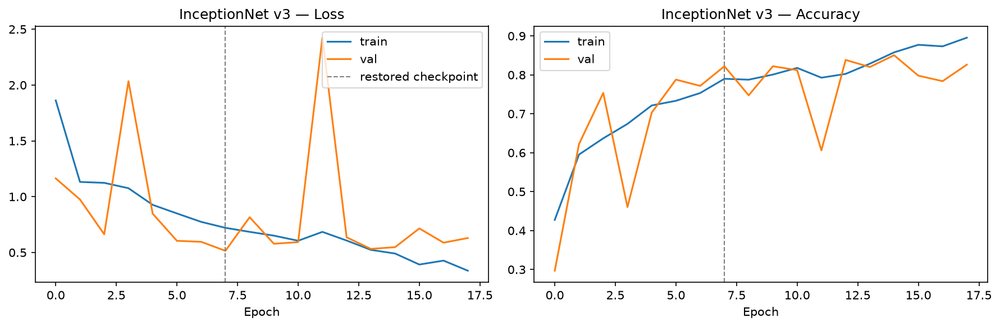

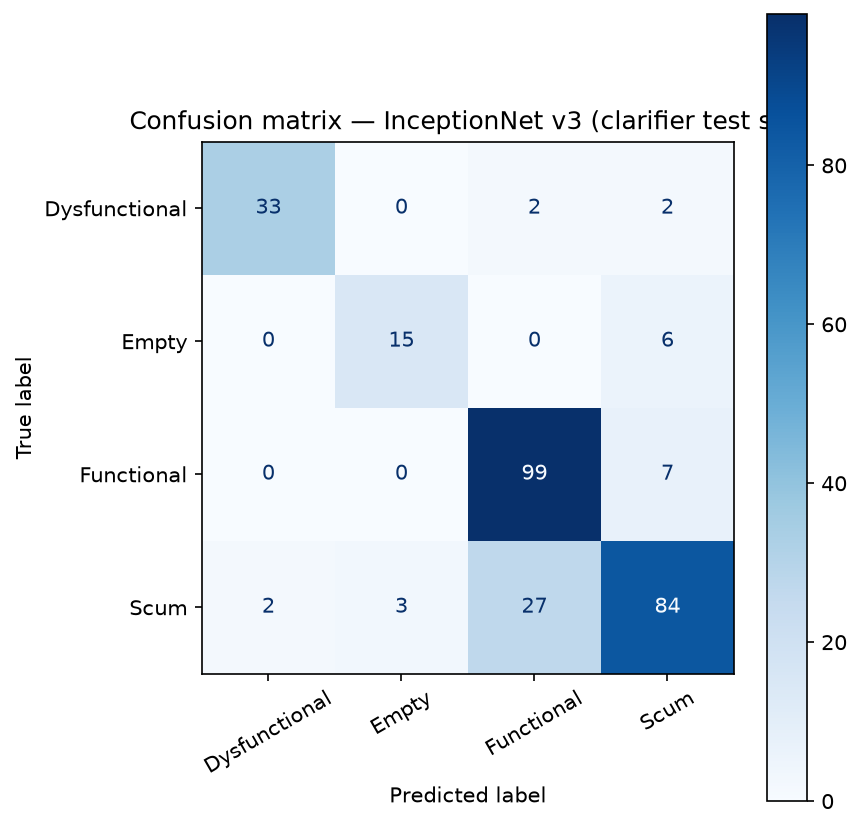

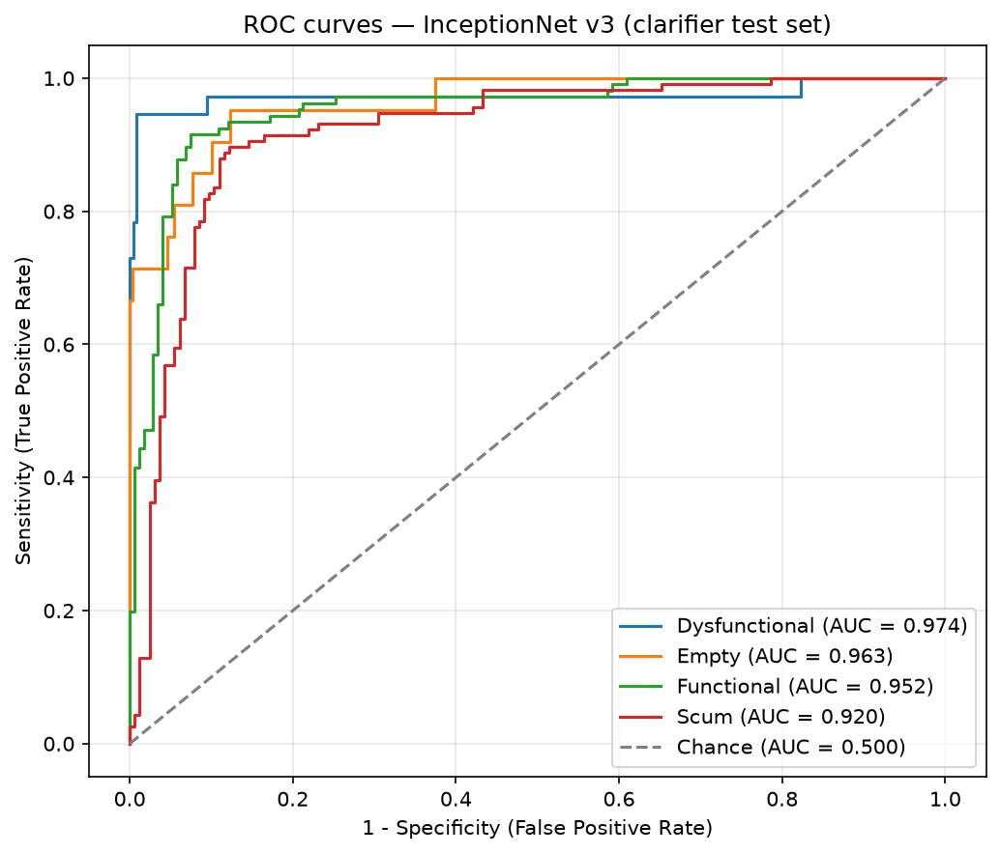

**EfficientNet-B0** - test accuracy 0.843, mean AUC 0.962

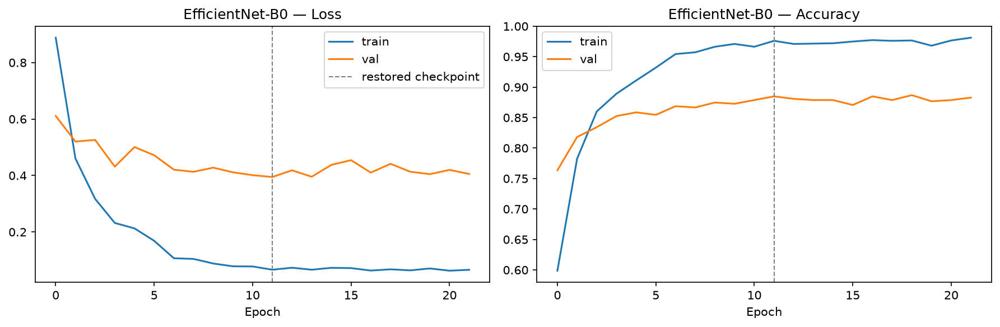

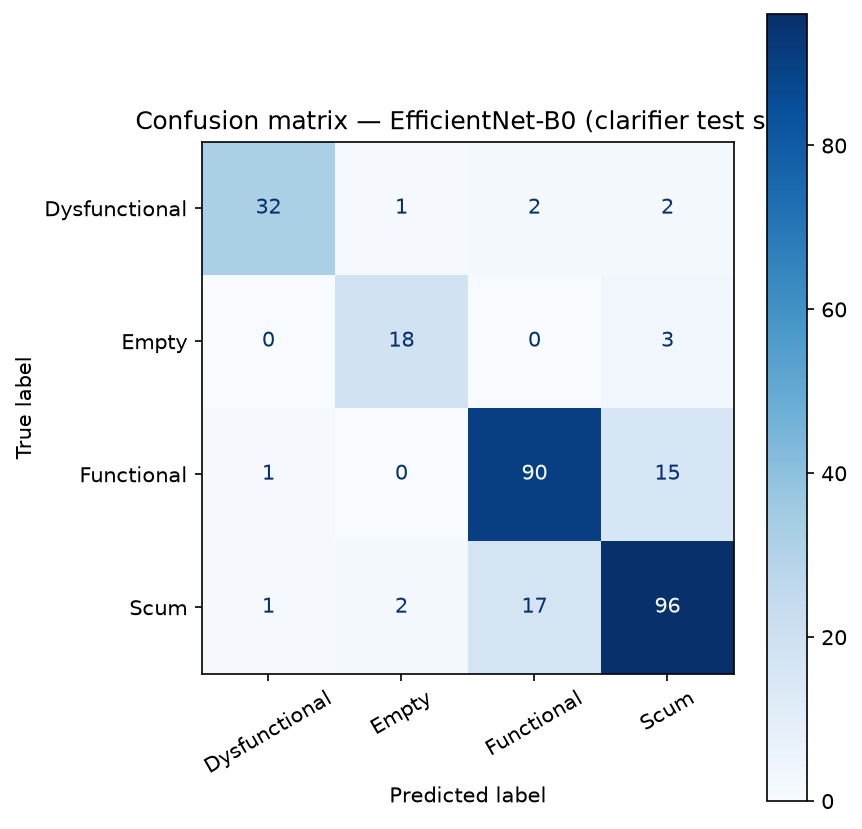

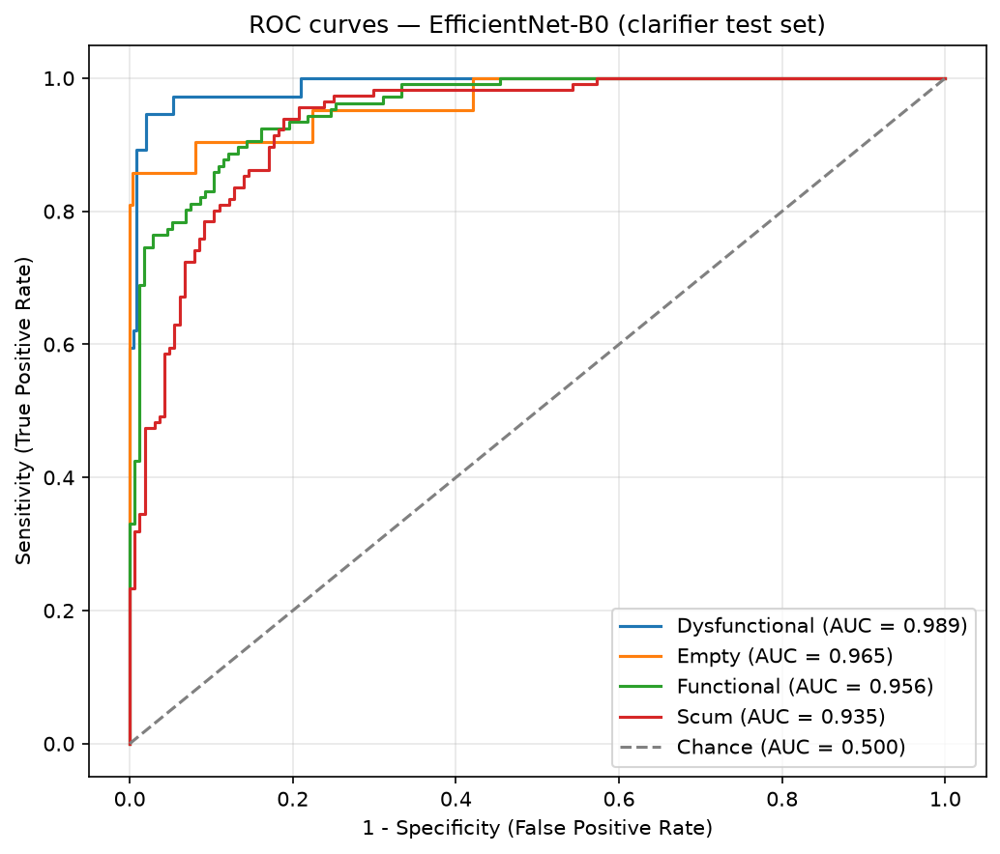

**ConvNeXt-Tiny** - test accuracy 0.886, mean AUC 0.975

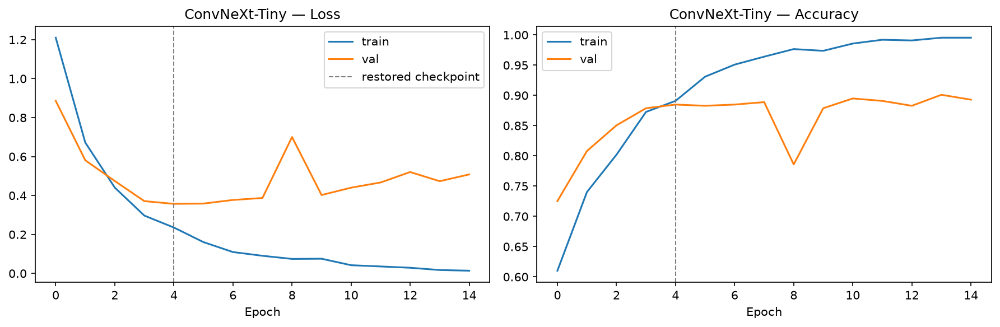

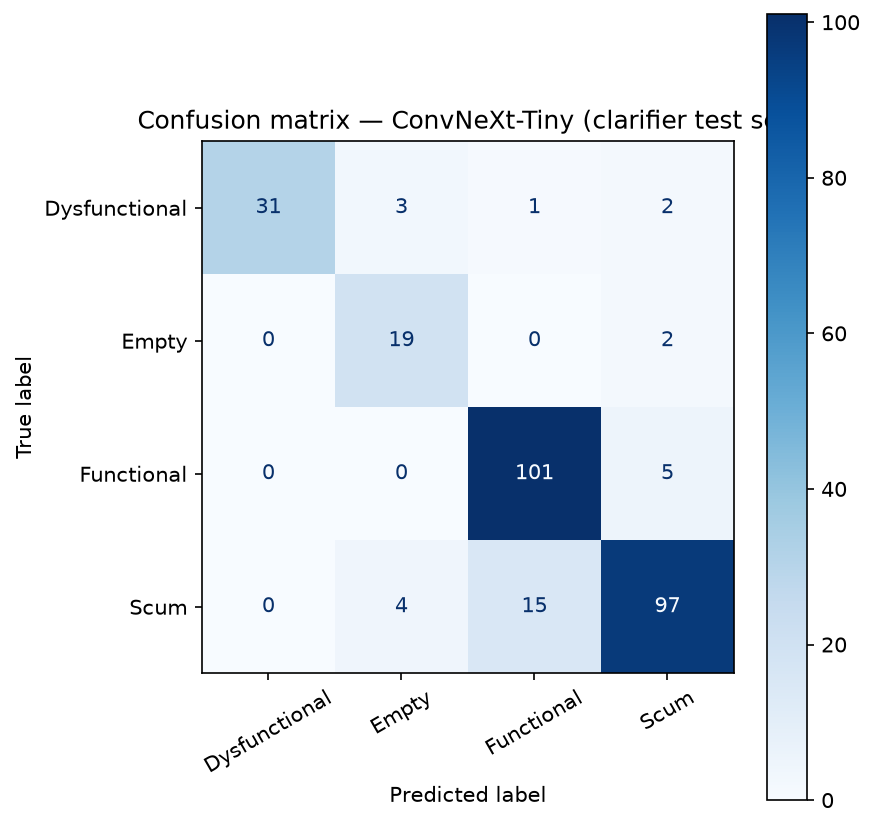

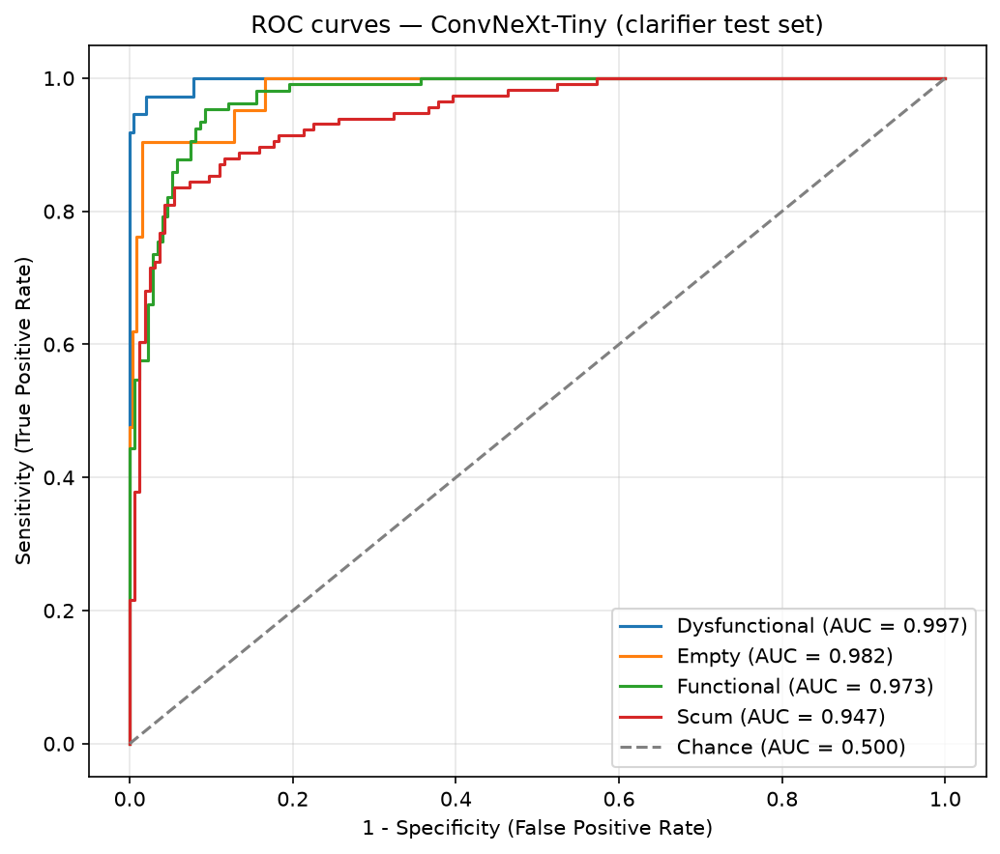

**AlexNet** - test accuracy 0.750, mean AUC 0.916

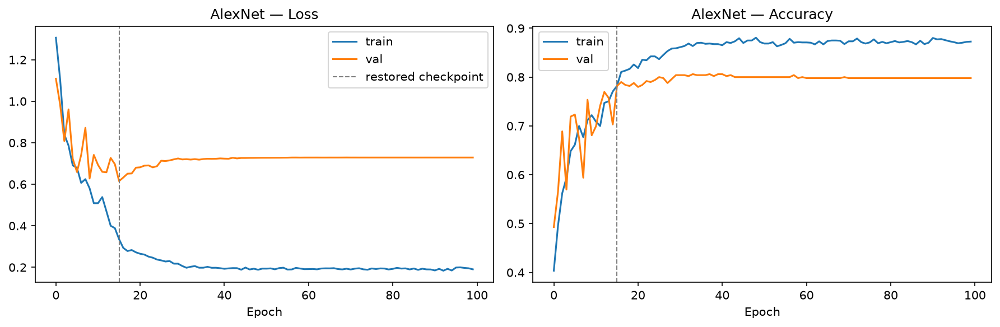

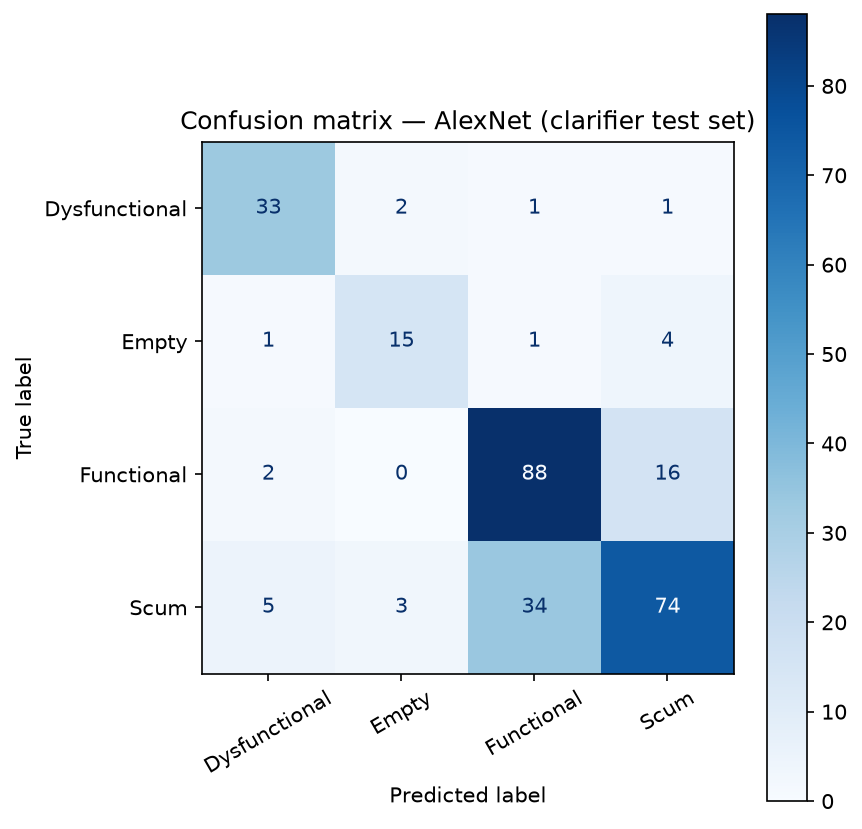

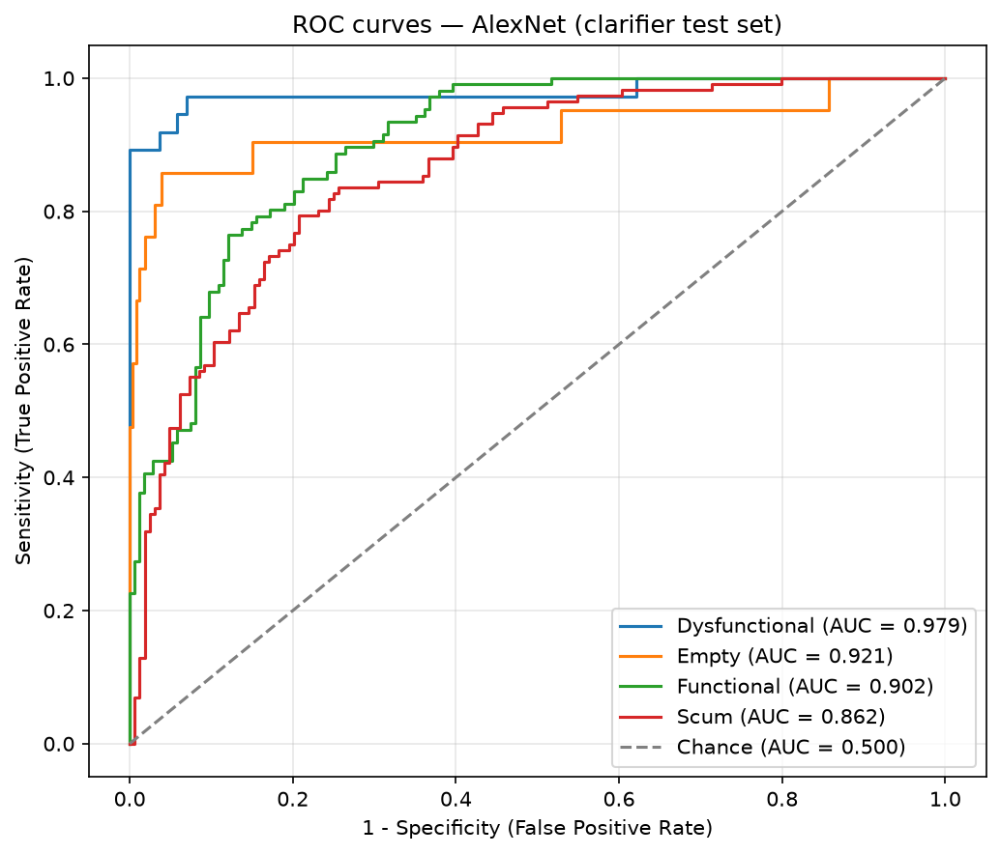

In [19]:
show_figures("noaug", "stratified")

## Summary - No augmentation

One row per architecture: stratified results and the OK/not-OK operating point.

In [20]:
SUMMARY_NOAUG = summary_table("noaug")

,stratified accuracy,stratified mean AUC,stratified macro F1,stratified OK/not-OK AUC,stratified recall @thr,stratified specificity @thr
ResNet-18,0.850,0.955,0.875,0.957,0.954,0.726
ResNet-50,0.786,0.944,0.790,0.924,0.954,0.594
DenseNet-121,0.843,0.958,0.818,0.964,0.954,0.821
InceptionNet v3,0.825,0.952,0.828,0.952,0.954,0.792
EfficientNet-B0,0.843,0.962,0.856,0.956,0.954,0.774
ConvNeXt-Tiny,0.886,0.975,0.875,0.973,0.954,0.821
AlexNet,0.750,0.916,0.761,0.902,0.960,0.425


Saved to ../results/clarifier_noaug/summary_clarifier_noaug.csv


# With vs without augmentation

Stratified 70/20/10 results side by side (same tuned hyperparameters and split; only the train-time augmentation differs).

In [21]:
_parts = {EXPERIMENTS[k][0]: t for k, t in [("aug", SUMMARY_AUG), ("noaug", SUMMARY_NOAUG)] if t is not None}
if _parts:
    _cols = ["stratified accuracy", "stratified mean AUC", "stratified macro F1",
             "stratified OK/not-OK AUC", "stratified recall @thr", "stratified specificity @thr"]
    display(pd.concat({k: v.reindex(columns=_cols) for k, v in _parts.items()}, axis=1))

Augmented training                                          \
                stratified accuracy stratified mean AUC stratified macro F1   
ResNet-18                     0.854               0.961               0.864   
ResNet-50                     0.836               0.968               0.821   
DenseNet-121                  0.882               0.975               0.880   
InceptionNet v3               0.868               0.968               0.864   
EfficientNet-B0               0.864               0.970               0.867   
ConvNeXt-Tiny                 0.889               0.975               0.895   
AlexNet                       0.761               0.924               0.790   

                                                                 \
                stratified OK/not-OK AUC stratified recall @thr   
ResNet-18                          0.960                  0.954   
ResNet-50                          0.962                  0.954   
DenseNet-121                       0.977                  0.954   
InceptionNet v3                    0.968                  0.954   
EfficientNet-B0                    0.961                  0.954   
ConvNeXt-Tiny                      0.975                  0.954   
AlexNet                            0.910                  0.954   

                                                No augmentation  \
                stratified specificity @thr stratified accuracy   
ResNet-18                             0.783               0.850   
ResNet-50                             0.755               0.786   
DenseNet-121                          0.868               0.843   
InceptionNet v3                       0.877               0.825   
EfficientNet-B0                       0.821               0.843   
ConvNeXt-Tiny                         0.877               0.886   
AlexNet                               0.509               0.750   

                                                         \
                stratified mean AUC stratified macro F1   
ResNet-18                     0.955               0.875   
ResNet-50                     0.944               0.790   
DenseNet-121                  0.958               0.818   
InceptionNet v3               0.952               0.828   
EfficientNet-B0               0.962               0.856   
ConvNeXt-Tiny                 0.975               0.875   
AlexNet                       0.916               0.761   

                                                                 \
                stratified OK/not-OK AUC stratified recall @thr   
ResNet-18                          0.957                  0.954   
ResNet-50                          0.924                  0.954   
DenseNet-121                       0.964                  0.954   
InceptionNet v3                    0.952                  0.954   
EfficientNet-B0                    0.956                  0.954   
ConvNeXt-Tiny                      0.973                  0.954   
AlexNet                            0.902                  0.960   

                                             
                stratified specificity @thr  
ResNet-18                             0.726  
ResNet-50                             0.594  
DenseNet-121                          0.821  
InceptionNet v3                       0.792  
EfficientNet-B0                       0.774  
ConvNeXt-Tiny                         0.821  
AlexNet                               0.425